# Text ML Pipeline — Mental Health Classification

## Overview
This notebook implements a **production-grade, fully dynamic ML pipeline** that takes a raw CSV of NLP-extracted text features and trains the best classification model to predict mental health condition categories.

**Data:** `data/text_parameters_for_ml.csv` — 15,000 samples, 52 features, 5 classes
**Classes:** `ANXIETY`, `BIPOLAR`, `DEPRESSION`, `PHOBIA`, `SUICIDAL_TENDENCY`
**Task:** Multi-class Classification

## Pipeline Flow
```
Step 0  → Import Libraries & Hardware Detection
Step 1  → Configuration (FILE_PATH, TASK_TYPE, RANDOM_SEED)
Step 2  → Data Loading
Step 3  → Column Overview & Optional Column Deletion
Step 4  → Target Column Selection
Step 5  → Data Profiling & Quality Audit
Step 6  → Auto-Clean (drop bad columns, impute nulls)
Step 7  → Target Analysis & Class Balance + Train/Test Split
Step 8  → Outlier Handling (smoothing only, train-fit)
Step 9  → Feature Type Handling (encoding, train-fit)
Step 10 → Exploratory Data Analysis & Visualization
Step 11 → Feature Selection (multi-method consensus)
Step 12 → Feature Scaling (train-fit, apply to both)
Step 13 → Model Shortlisting
Step 14 → Model Training & Cross-Validation Ranking
Step 15 → Top-K Model Selection
Step 16 → Hyperparameter Tuning (Optuna)
Step 17 → Final Evaluation on Test Set
Step 18 → Save All Artifacts
Step 19 → Model Explainability (SHAP)
```

## Key Design Principles
- **No data leakage** — all transformers (scalers, encoders, outlier handlers) are fit on training data only, then applied to test
- **Fully dynamic** — add more features to the CSV and re-run; the pipeline adapts automatically with no code changes
- **Production-ready** — every fitted object is saved for inference on new data

## Step 0 — Import Libraries & Hardware Detection

**What:** Imports all required Python libraries and detects available hardware (CPU cores, GPU).

**Why:** Centralising imports at the top ensures the notebook fails fast if a library is missing rather than mid-run. Hardware detection allows the pipeline to automatically switch XGBoost and LightGBM to GPU mode when a CUDA-capable GPU is available.

**Output:** All libraries loaded into the kernel. Variables `CPU_COUNT`, `GPU_AVAILABLE`, `GPU_NAME` set for use in later steps.

**Note:** If a library is missing, install it via `pip install <library>` and re-run this cell only.

In [1]:
# ============================================================
# STEP 0: IMPORT ALL REQUIRED LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import time
import copy
import warnings
from collections import Counter, OrderedDict
from datetime import datetime

from scipy import stats
from scipy.stats import skew, kurtosis

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     KFold, cross_val_score)
from sklearn.preprocessing import (LabelEncoder, StandardScaler, RobustScaler,
                                   MinMaxScaler, PowerTransformer, OrdinalEncoder)
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              ExtraTreesClassifier, RandomForestRegressor,
                              GradientBoostingRegressor, ExtraTreesRegressor,
                              HistGradientBoostingClassifier,
                              HistGradientBoostingRegressor)
from sklearn.linear_model import (LogisticRegression, Ridge, Lasso,
                                  LinearRegression)
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, precision_score,
                             recall_score, mean_squared_error,
                             mean_absolute_error, r2_score)
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.impute import SimpleImputer

import xgboost as xgb
import lightgbm as lgb
import optuna
import joblib
from joblib import Parallel, delayed

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# ─── Hardware Detection ─────────────────────────────────────────────
import multiprocessing
CPU_COUNT = multiprocessing.cpu_count()

GPU_AVAILABLE = False
GPU_NAME = 'None'
GPU_VRAM_MB = 0

# Check CUDA GPU via torch (most reliable)
try:
    import torch
    if torch.cuda.is_available():
        GPU_AVAILABLE = True
        GPU_NAME = torch.cuda.get_device_name(0)
        GPU_VRAM_MB = torch.cuda.get_device_properties(0).total_memory // (1024 * 1024)
except ImportError:
    pass

# Fallback: check if XGBoost was built with CUDA support
if not GPU_AVAILABLE:
    try:
        _test_xgb = xgb.XGBClassifier(device='cuda', n_estimators=1)
        _test_xgb.fit(np.array([[1,2],[3,4]]), np.array([0,1]))
        GPU_AVAILABLE = True
        GPU_NAME = 'CUDA device (detected via XGBoost)'
    except Exception:
        pass

print('=' * 70)
print('STEP 0: LIBRARY IMPORT & HARDWARE DETECTION')
print('=' * 70)
print('All libraries loaded successfully.')
print(f'  pandas     : {pd.__version__}')
print(f'  numpy      : {np.__version__}')
print(f'  sklearn    : {__import__("sklearn").__version__}')
print(f'  xgboost    : {xgb.__version__}')
print(f'  lightgbm   : {lgb.__version__}')
print(f'  optuna     : {optuna.__version__}')

print(f'\n--- Hardware ---')
print(f'  CPU cores  : {CPU_COUNT}')
if GPU_AVAILABLE:
    print(f'  GPU        : {GPU_NAME}')
    if GPU_VRAM_MB:
        print(f'  VRAM       : {GPU_VRAM_MB:,} MB')
    print(f'  XGBoost    : will use device="cuda"')
    print(f'  LightGBM   : will use device="gpu"')
else:
    print(f'  GPU        : Not available — using CPU only')
    print(f'  (Install PyTorch with CUDA or a CUDA toolkit to enable GPU acceleration)')

c:\Users\vicky\OneDrive\Desktop\SCS-projects\Mindspace-voice-agent\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


STEP 0: LIBRARY IMPORT & HARDWARE DETECTION
All libraries loaded successfully.
  pandas     : 2.3.3
  numpy      : 2.4.2
  sklearn    : 1.8.0
  xgboost    : 3.2.0
  lightgbm   : 4.6.0
  optuna     : 4.7.0

--- Hardware ---
  CPU cores  : 8
  GPU        : NVIDIA GeForce GTX 1650 Ti
  VRAM       : 4,095 MB
  XGBoost    : will use device="cuda"
  LightGBM   : will use device="gpu"


## Step 1 — Configuration

**What:** Sets the three core pipeline parameters: file path, task type, and random seed.

**Why:** Having all user-editable settings in one place means you never need to search through the notebook to change the data source or output folder. Every other cell reads from these variables.

**Output:** `FILE_PATH`, `TASK_TYPE`, `RANDOM_SEED`, `OUTPUT_DIR`, `PIPELINE_STATE` (empty dict to collect stage artifacts).

**Rules:**
- `TASK_TYPE` is locked to `'classification'` — this pipeline is built for mental health class prediction only
- `RANDOM_SEED = 42` ensures reproducible train/test splits, model training, and Optuna tuning across runs
- Only edit `FILE_PATH` if you rename or move the CSV

In [2]:
# ============================================================
# STEP 1: CONFIGURATION
# ============================================================
# Edit FILE_PATH to point to your CSV.
# TASK_TYPE is locked to classification for this pipeline.
# ============================================================

FILE_PATH   = 'data/text_parameters_for_ml.csv'
TASK_TYPE   = 'classification'   # locked
RANDOM_SEED = 42
OUTPUT_DIR  = 'text_ml_pipeline_output'

os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(RANDOM_SEED)

PIPELINE_STATE = {}

print('=' * 70)
print('STEP 1: CONFIGURATION')
print('=' * 70)
print(f'  File path  : {FILE_PATH}')
print(f'  Task type  : {TASK_TYPE}')
print(f'  Random seed: {RANDOM_SEED}')
print(f'  Output dir : {OUTPUT_DIR}/')
print('  Configuration set successfully!')

STEP 1: CONFIGURATION
  File path  : data/text_parameters_for_ml.csv
  Task type  : classification
  Random seed: 42
  Output dir : text_ml_pipeline_output/
  Configuration set successfully!


## Step 2 — Data Loading

**What:** Loads the CSV from `FILE_PATH` into a pandas DataFrame and prints a basic shape and memory summary.

**Why:** Validating the load immediately catches file-not-found errors, encoding issues, or empty files before any processing begins. Printing shape and dtypes gives a quick sanity check.

**Output:** `df` — the working DataFrame. `df_raw` — an untouched copy kept for reference.

**Rules:** Do not modify `df_raw` at any point. If you need to inspect the original data later, always read from `df_raw`.

In [3]:
print('=' * 70)
print('STEP 2: DATA LOADING')
print('=' * 70)

if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f'File not found: {FILE_PATH}')

df_raw = pd.read_csv(FILE_PATH)
df = df_raw.copy()

print(f'\nData loaded successfully from: {FILE_PATH}')
print(f'  Rows   : {df.shape[0]:,}')
print(f'  Columns: {df.shape[1]}')
print(f'  Memory : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

print(f'\nData Types Summary:')
for dtype, count in df.dtypes.value_counts().items():
    print(f'  {dtype}: {count} columns')

print(f'\nFirst 5 rows:')
display(df.head())

PIPELINE_STATE['data_loading'] = {
    'rows': int(df.shape[0]),
    'cols': int(df.shape[1]),
    'dtypes': {str(k): int(v) for k, v in df.dtypes.value_counts().items()},
    'file': FILE_PATH
}
print(f'\nStep 2 complete.')

STEP 2: DATA LOADING

Data loaded successfully from: data/text_parameters_for_ml.csv
  Rows   : 15,000
  Columns: 53
  Memory : 6.79 MB

Data Types Summary:
  float64: 47 columns
  int64: 5 columns
  object: 1 columns

First 5 rows:


,total_word_count,unique_word_count,type_token_ratio_ttr,moving_average_ttr,hapax_legoman_ratio,sentence_count,average_sentence_length,repetition_rate,noun_ratio,verb_ratio,...,uncertainty_word_frequency,avoidance_language_frequency,threat_anticipation_language,self_reference_density,past_focused_word_ratio,present_focused_word_ratio,future_focused_word_ratio,filler_word_frequency,cognitive_load_score,target
0,377,311,0.824934,0.720136,0.201117,49,7.370073,0.546737,0.128727,0.152127,...,0.273381,0.542512,0.629013,0.029636,0.000000,0.555869,0.212057,0.078399,23.338741,PHOBIA
1,310,286,0.922581,0.578923,0.323040,42,12.923888,0.312745,0.117617,0.156802,...,0.111119,0.131904,0.097011,0.028489,0.210124,0.316100,0.180203,0.054665,36.426626,BIPOLAR
2,582,549,0.943299,0.700024,0.365100,29,15.608528,0.591515,0.160486,0.162740,...,0.474294,0.293659,0.440751,0.055709,0.534384,0.393667,0.000000,0.032898,38.977652,SUICIDAL_TENDENCY
3,375,333,0.888000,0.683312,0.326751,41,9.262139,0.578309,0.145360,0.157737,...,0.032734,0.238296,0.190520,0.021341,0.243584,0.632547,0.104265,0.054718,23.901680,DEPRESSION
4,694,277,0.399135,0.759459,0.251083,22,11.857692,0.825306,0.164086,0.127091,...,0.775292,0.451025,0.738536,0.042859,0.183146,0.576552,0.174285,0.034451,27.903761,ANXIETY



Step 2 complete.


## Step 3 — Column Overview & Optional Column Deletion

**What:** Prints a table of all columns with their data type, null count, unique value count, and a sample value. Optionally drops columns listed in `COLUMNS_TO_DROP`.

**Why:** Before any processing, you need to see what columns exist and identify any that should not enter the pipeline (e.g. ID columns, metadata, columns added by mistake). The drop list is empty by default and only used when explicitly needed.

**Output:** Updated `df` with unwanted columns removed (if any listed). Column summary table printed for review.

**Rules:**
- `COLUMNS_TO_DROP = []` by default — pipeline uses all columns
- Add column names to the list only when you have a specific reason to exclude them
- Never add the target column to `COLUMNS_TO_DROP`

In [4]:
print('=' * 70)
print('STEP 3: COLUMN OVERVIEW')
print('=' * 70)

col_info = []
for i, col in enumerate(df.columns):
    dtype = str(df[col].dtype)
    nulls = int(df[col].isnull().sum())
    null_pct = round(nulls / len(df) * 100, 2)
    unique = int(df[col].nunique())
    sample = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    if isinstance(sample, str) and len(str(sample)) > 30:
        sample = str(sample)[:30] + '...'
    col_info.append({
        '#': i, 'Column': col, 'Type': dtype,
        'Nulls': nulls, 'Null%': null_pct,
        'Unique': unique, 'Sample': sample
    })

col_df = pd.DataFrame(col_info)
print(col_df.to_string(index=False))

print(f'\n>>> IMPORTANT: In the NEXT cell, set your TARGET column name.')
print(f'    Choose from the column names listed above.')

STEP 3: COLUMN OVERVIEW
 #                                  Column    Type  Nulls  Null%  Unique     Sample
 0                        total_word_count   int64      0    0.0     600        377
 1                       unique_word_count   int64      0    0.0     674        311
 2                    type_token_ratio_ttr float64      0    0.0   13237   0.824934
 3                      moving_average_ttr float64      0    0.0   14999   0.720136
 4                     hapax_legoman_ratio float64      0    0.0   14999   0.201117
 5                          sentence_count   int64      0    0.0      50         49
 6                 average_sentence_length float64      0    0.0   15000   7.370073
 7                         repetition_rate float64      0    0.0   14989   0.546737
 8                              noun_ratio float64      0    0.0   15000   0.128727
 9                              verb_ratio float64      0    0.0   15000   0.152127
10                         adjective_ratio float64  

In [5]:
# ============================================================
#     DELETE UNWANTED COLUMNS (Optional)
# ============================================================
# List column names to DROP before the pipeline runs.
# Default is empty [] — pipeline uses all columns.
# Example: COLUMNS_TO_DROP = ['col1', 'col2']

COLUMNS_TO_DROP = []   # <-- add column names here if needed

# ============================================================

if COLUMNS_TO_DROP:
    missing = [c for c in COLUMNS_TO_DROP if c not in df.columns]
    if missing:
        print(f"[WARNING] These columns were not found and will be skipped: {missing}")
    valid_drops = [c for c in COLUMNS_TO_DROP if c in df.columns]
    if valid_drops:
        df = df.drop(columns=valid_drops)
        print(f"[OK] Dropped columns: {valid_drops}")
        print(f"     Remaining columns ({len(df.columns)}): {list(df.columns)}")
else:
    print("[SKIP] No columns to drop. df is unchanged.")


[SKIP] No columns to drop. df is unchanged.


## Step 4 — Target Column Selection

**What:** Sets `TARGET_COLUMN` to the column the model will predict and validates it exists in the DataFrame.

**Why:** Explicitly naming the target column separates it from the feature set in all downstream steps. The validation raises an error immediately if the column name is wrong rather than producing silent incorrect results.

**Output:** `TARGET_COLUMN` string variable. `TASK_TYPE` confirmed as `'classification'`. `PIPELINE_STATE['target']` updated with column metadata.

**Rules:**
- Change `TARGET_COLUMN` here if your CSV uses a different column name for the label
- The pipeline will print all class names — verify they look correct before continuing

In [6]:
# ============================================================
#     SET YOUR TARGET COLUMN HERE
# ============================================================
TARGET_COLUMN = 'target'   # <-- change if your target column has a different name
# ============================================================

# --- Validation ---
if TARGET_COLUMN not in df.columns:
    raise ValueError(
        f"Column '{TARGET_COLUMN}' not found! "
        f"Available columns: {list(df.columns)}"
    )

print('=' * 70)
print('STEP 4: TARGET COLUMN SELECTION')
print('=' * 70)
print(f'  Target column : {TARGET_COLUMN}')
print(f'  Task type     : {TASK_TYPE}')
print(f'  Dtype         : {df[TARGET_COLUMN].dtype}')
print(f'  Unique classes: {df[TARGET_COLUMN].nunique()}')
print(f'  Class names   : {sorted(df[TARGET_COLUMN].unique().tolist())}')
print(f'  Null count    : {df[TARGET_COLUMN].isnull().sum()}')

PIPELINE_STATE['target'] = {
    'column': TARGET_COLUMN,
    'task_type': TASK_TYPE,
    'n_unique': int(df[TARGET_COLUMN].nunique()),
    'class_names': sorted(df[TARGET_COLUMN].unique().tolist())
}
print(f'Step 4 complete.')

STEP 4: TARGET COLUMN SELECTION
  Target column : target
  Task type     : classification
  Dtype         : object
  Unique classes: 5
  Class names   : ['ANXIETY', 'BIPOLAR', 'DEPRESSION', 'PHOBIA', 'SUICIDAL_TENDENCY']
  Null count    : 0
Step 4 complete.


## Step 5 — Data Profiling & Quality Audit

**What:** Automatically scans every column for six categories of data quality issues and flags problematic columns for removal.

**Checks performed:**
1. **Null values** — columns with >50% nulls flagged; lower percentages will be imputed in Step 6
2. **Duplicate rows** — detected and removed if >30% of rows are duplicates
3. **Constant columns** — columns with only one unique value have zero predictive power
4. **ID-like columns** — integer or string columns where every row is unique (likely row IDs, not features)
5. **High-cardinality categoricals** — categorical columns where >50% of values are unique (too many categories to encode meaningfully)
6. **Target leakage** — columns that map perfectly 1-to-1 with the target label (the model would cheat using these)

**Why:** Each of these issues will either crash the pipeline, produce misleading results, or cause the model to appear accurate during training but fail on new data. Catching them here, before any transformation, is the correct place.

**Output:** `columns_to_drop` list and `drop_reasons` dict. `PIPELINE_STATE['profiling']` updated.

**Rules:** Nothing is deleted here — only flagged. Actual deletion happens in Step 6.

In [7]:
print('=' * 70)
print('STEP 5: DATA PROFILING & QUALITY AUDIT')
print('=' * 70)

columns_to_drop = []
drop_reasons = {}

# ─── 5.1 Null Value Analysis ────────────────────────────────────────
print('\n--- 5.1 Null Value Analysis ---')
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_cols = null_counts[null_counts > 0]

if len(null_cols) == 0:
    print('  No null values found in any column.')
else:
    print(f'  Found {len(null_cols)} columns with null values:')
    for col in null_cols.index:
        pct = null_pct[col]
        cnt = null_counts[col]
        print(f'    {col}: {cnt:,} nulls ({pct}%)')
        if pct > 50:
            columns_to_drop.append(col)
            drop_reasons[col] = f'Over {pct}% null values'
            print(f'      FLAGGED FOR REMOVAL (>50% null)')
        elif pct > 0:
            print(f'      Will be imputed in the cleaning step')

# ─── 5.2 Duplicate Rows ─────────────────────────────────────────────
print('\n--- 5.2 Duplicate Row Analysis ---')
n_dups = int(df.duplicated().sum())

if n_dups == 0:
    print('  No duplicate rows found.')
else:
    dup_pct = round(n_dups / len(df) * 100, 2)
    print(f'  Found {n_dups:,} duplicate rows ({dup_pct}%)')
    if dup_pct > 30:
        print(f'  High duplication detected! Keeping first occurrence only.')
        df = df.drop_duplicates(keep='first')
        print(f'  New shape after dedup: {df.shape}')
    else:
        print(f'  Duplication within acceptable range. Keeping all rows.')

# ─── 5.3 Constant Columns ───────────────────────────────────────────
print('\n--- 5.3 Constant Column Detection ---')
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]

if constant_cols:
    print(f'  Found {len(constant_cols)} constant column(s): {constant_cols}')
    for col in constant_cols:
        if col != TARGET_COLUMN and col not in columns_to_drop:
            columns_to_drop.append(col)
            drop_reasons[col] = 'Constant value — zero variance'
    print('  FLAGGED FOR REMOVAL (no predictive value)')
else:
    print('  No constant columns found.')

# ─── 5.4 ID-like Columns ────────────────────────────────────────────
print('\n--- 5.4 ID-like Column Detection ---')
id_cols = []
id_patterns = ['id', 'index', 'row_id', 'row_num', 'record_id', 'uid', 'uuid', 'pk']
for col in df.columns:
    if col == TARGET_COLUMN:
        continue
    col_dtype = df[col].dtype
    # Only flag integer or object columns with all-unique values as ID-like.
    # Float columns with unique values are normal continuous features — skip them.
    if df[col].nunique() == len(df) and col_dtype not in ['float64', 'float32']:
        id_cols.append(col)
    elif col.lower().strip('_') in id_patterns:
        id_cols.append(col)

if id_cols:
    print(f'  Found {len(id_cols)} ID-like column(s): {id_cols}')
    for col in id_cols:
        if col not in columns_to_drop:
            columns_to_drop.append(col)
            drop_reasons[col] = 'ID-like column — unique per row'
    print('  FLAGGED FOR REMOVAL')
else:
    print('  No ID-like columns detected.')

# ─── 5.5 High-Cardinality Categoricals ──────────────────────────────
print('\n--- 5.5 High Cardinality Categorical Check ---')
cat_cols_check = df.select_dtypes(include='object').columns.tolist()
if TARGET_COLUMN in cat_cols_check:
    cat_cols_check.remove(TARGET_COLUMN)

high_card = []
for col in cat_cols_check:
    ratio = df[col].nunique() / len(df)
    if ratio > 0.5:
        high_card.append((col, df[col].nunique(), round(ratio * 100, 1)))

if high_card:
    print(f'  Found {len(high_card)} high-cardinality categorical column(s):')
    for col, nuniq, ratio in high_card:
        print(f'    {col}: {nuniq:,} unique values ({ratio}% of rows)')
        if col not in columns_to_drop:
            columns_to_drop.append(col)
            drop_reasons[col] = f'High cardinality — {nuniq} unique values'
    print('  FLAGGED FOR REMOVAL (too many categories for encoding)')
else:
    print('  No high-cardinality categorical columns.')

# ─── 5.6 Target Leakage Detection ───────────────────────────────────
print('\n--- 5.6 Target Leakage Detection ---')
leakage_cols = []
for col in df.columns:
    if col == TARGET_COLUMN or col in columns_to_drop:
        continue
    # Check 1: perfect 1-to-1 mapping with the target
    if df[col].dtype == 'object' or df[col].nunique() <= df[TARGET_COLUMN].nunique():
        mapping = df[[TARGET_COLUMN, col]].drop_duplicates()
        if len(mapping) == df[TARGET_COLUMN].nunique() and mapping[col].nunique() == df[TARGET_COLUMN].nunique():
            leakage_cols.append(col)
            continue
    # Check 2: binary column that perfectly indicates a single target class
    #   e.g. target_Depression=1 iff profile='Depression' — one-hot leakage
    unique_vals = set(df[col].dropna().unique())
    if unique_vals == {0, 1} or unique_vals == {0.0, 1.0} or unique_vals == {True, False}:
        for cls in df[TARGET_COLUMN].unique():
            cls_mask = (df[TARGET_COLUMN] == cls)
            col_mask = (df[col] == 1)
            if cls_mask.equals(col_mask):
                leakage_cols.append(col)
                break

if leakage_cols:
    print(f'  Found {len(leakage_cols)} column(s) with perfect target mapping (LEAKAGE):')
    for col in leakage_cols:
        print(f'    [-] {col}: values map 1-to-1 with target "{TARGET_COLUMN}"')
        if col not in columns_to_drop:
            columns_to_drop.append(col)
            drop_reasons[col] = f'Target leakage — perfect 1-to-1 mapping with {TARGET_COLUMN}'
    print('  FLAGGED FOR REMOVAL (model would cheat using these)')
else:
    print('  No target leakage detected.')

# ─── 5.7 Summary ────────────────────────────────────────────────────
print('\n--- 5.7 Profiling Summary ---')
if columns_to_drop:
    print(f'  Total columns flagged for removal: {len(columns_to_drop)}')
    for col in columns_to_drop:
        print(f'    [-] {col}: {drop_reasons.get(col, "flagged")}')
else:
    print('  No columns flagged for removal. All columns look good.')

PIPELINE_STATE['profiling'] = {
    'null_columns': {col: float(null_pct[col]) for col in null_cols.index} if len(null_cols) > 0 else {},
    'duplicates': n_dups,
    'constant_cols': constant_cols,
    'id_cols': id_cols,
    'high_cardinality': [x[0] for x in high_card],
    'flagged_for_removal': columns_to_drop,
    'drop_reasons': drop_reasons
}
print(f'\nStep 5 complete.')

STEP 5: DATA PROFILING & QUALITY AUDIT

--- 5.1 Null Value Analysis ---
  No null values found in any column.

--- 5.2 Duplicate Row Analysis ---
  No duplicate rows found.

--- 5.3 Constant Column Detection ---
  No constant columns found.

--- 5.4 ID-like Column Detection ---
  No ID-like columns detected.

--- 5.5 High Cardinality Categorical Check ---
  No high-cardinality categorical columns.

--- 5.6 Target Leakage Detection ---
  No target leakage detected.

--- 5.7 Profiling Summary ---
  No columns flagged for removal. All columns look good.

Step 5 complete.


## Step 6 — Auto-Clean

**What:** Drops all columns flagged in Step 5 and imputes any remaining null values.

**Imputation strategy:**
- Numeric columns → filled with **median** (robust to outliers)
- Categorical columns → filled with **mode** (most frequent value)
- Target column with nulls → rows are dropped (we cannot predict an unknown label)

**Why:** A model cannot train on null values. Imputing with median/mode is a safe default that preserves the distribution without introducing bias. The index is reset after any row removal to ensure clean alignment between features and labels.

**Output:** Cleaned `df` with no nulls, no flagged columns. Shape printed for confirmation.

**Rules:**
- Imputation values are computed from the full dataset here (before split) — acceptable because we are only filling structural gaps, not learning from the target
- The index reset (`reset_index(drop=True)`) is essential after row deletion to prevent misalignment

In [8]:
print('=' * 70)
print('STEP 6: AUTO-CLEAN')
print('=' * 70)

# ─── 6.1 Drop flagged columns ───────────────────────────────────────
safe_to_drop = [c for c in columns_to_drop if c != TARGET_COLUMN]

if safe_to_drop:
    print(f'\nDropping {len(safe_to_drop)} column(s):')
    for col in safe_to_drop:
        print(f'  [-] {col} | Reason: {drop_reasons.get(col, "flagged")}')
    df = df.drop(columns=safe_to_drop)
    print(f'  Shape after drop: {df.shape}')
else:
    print('\n  No columns to drop. All columns retained.')

# ─── 6.2 Impute remaining nulls ────────────────────────────────────
print('\n--- 6.2 Null Imputation ---')
null_remaining = df.isnull().sum()
null_remaining = null_remaining[null_remaining > 0]

imputed_cols = []
if len(null_remaining) > 0:
    print(f'  Imputing {len(null_remaining)} columns with remaining nulls:')
    for col in null_remaining.index:
        if col == TARGET_COLUMN:
            before = len(df)
            df = df.dropna(subset=[TARGET_COLUMN])
            dropped = before - len(df)
            print(f'    {col} (target): Dropped {dropped} rows with null target')
        elif df[col].dtype in ['float64', 'int64', 'float32', 'int32']:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            imputed_cols.append(col)
            print(f'    {col} (numeric): Filled with median = {median_val:.4f}')
        else:
            mode_vals = df[col].mode()
            mode_val = mode_vals.iloc[0] if len(mode_vals) > 0 else 'UNKNOWN'
            df[col] = df[col].fillna(mode_val)
            imputed_cols.append(col)
            print(f'    {col} (categorical): Filled with mode = {mode_val}')
else:
    print('  No remaining null values. No imputation needed.')

# ─── 6.3 Reset index (prevents misalignment after row removal) ──────
df = df.reset_index(drop=True)

print(f'\n  Clean dataset shape   : {df.shape}')
print(f'  Remaining null values : {df.isnull().sum().sum()}')
print(f'  Index reset to 0..{len(df)-1} (clean alignment)')

PIPELINE_STATE['auto_clean'] = {
    'columns_dropped': safe_to_drop,
    'imputed_columns': imputed_cols,
    'final_shape': list(df.shape)
}
print(f'\nStep 6 complete.')

STEP 6: AUTO-CLEAN

  No columns to drop. All columns retained.

--- 6.2 Null Imputation ---
  No remaining null values. No imputation needed.

  Clean dataset shape   : (15000, 53)
  Remaining null values : 0
  Index reset to 0..14999 (clean alignment)

Step 6 complete.


## Step 7 — Target Analysis, Class Balance & Train/Test Split

**What:** Analyses the class distribution of the target column, decides on a class balancing strategy, encodes the target labels to integers, then splits data into training and test sets.

**Class balance strategy:**
- Ratio <= 1.5 → no action needed (balanced)
- Ratio 1.5–3.0 → `class_weight='balanced'` applied in models
- Ratio > 3.0 → `class_weight='balanced'` + stratified sampling

**Why the split happens here:** The train/test split must happen **before** any feature transformation. If you scale or encode using the full dataset, information from the test set leaks into the training process, making evaluation metrics optimistic and unreliable.

**Output:** `X_train_df`, `X_test_df`, `y_train`, `y_test`, `le` (LabelEncoder), `class_names`, `BALANCE_STRATEGY`.

**Rules:**
- Split is always **stratified** — class proportions are preserved in both train and test sets
- Test set is 20% of the data and is never touched until Step 17
- `le` (LabelEncoder) is saved as an artifact — required to decode predictions back to class names

STEP 7: TARGET ANALYSIS, CLASS BALANCE & TRAIN/TEST SPLIT

Class Distribution (5 classes):
  PHOBIA                            3,000 ( 20.00%) |##########
  BIPOLAR                           3,000 ( 20.00%) |##########
  SUICIDAL_TENDENCY                 3,000 ( 20.00%) |##########
  DEPRESSION                        3,000 ( 20.00%) |##########
  ANXIETY                           3,000 ( 20.00%) |##########

Balance Check:
  Largest class  : PHOBIA (3,000)
  Smallest class : PHOBIA (3,000)
  Imbalance ratio: 1.00:1

  >> Dataset is BALANCED (ratio <= 1.5)
     Strategy: No class weights or resampling needed.


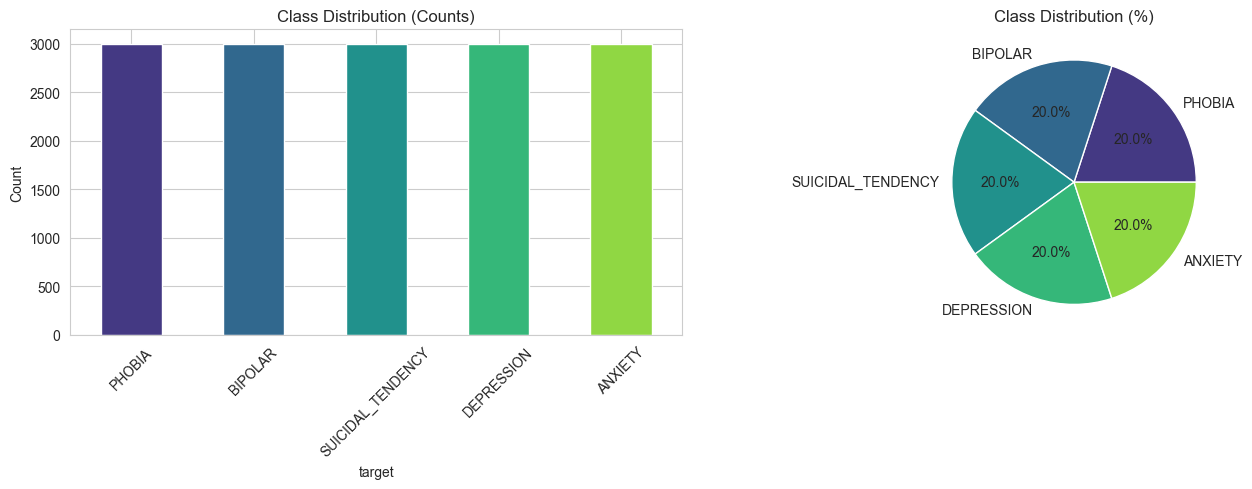


  Label encoding applied:
    ANXIETY -> 0
    BIPOLAR -> 1
    DEPRESSION -> 2
    PHOBIA -> 3
    SUICIDAL_TENDENCY -> 4

  Feature matrix shape: (15000, 52)
  Target array length : 15000

--- Train/Test Split (BEFORE transformations — no data leakage) ---
  Stratified split applied (class proportions preserved).
  Train: 12,000 samples, 52 features
  Test : 3,000 samples, 52 features

  Train class distribution:
    ANXIETY: 2,400
    BIPOLAR: 2,400
    DEPRESSION: 2,400
    PHOBIA: 2,400
    SUICIDAL_TENDENCY: 2,400

Step 7 complete.


In [9]:
print('=' * 70)
print('STEP 7: TARGET ANALYSIS, CLASS BALANCE & TRAIN/TEST SPLIT')
print('=' * 70)

if TASK_TYPE == 'classification':
    # ─── Class distribution ──────────────────────────────────────────
    class_counts = df[TARGET_COLUMN].value_counts()
    class_pct = (class_counts / len(df) * 100).round(2)
    n_classes = len(class_counts)

    print(f'\nClass Distribution ({n_classes} classes):')
    for cls in class_counts.index:
        count = class_counts[cls]
        pct = class_pct[cls]
        bar_len = int(pct / 2)
        bar = '#' * bar_len
        print(f'  {str(cls):<30} {count:>8,} ({pct:>6.2f}%) |{bar}')

    # ─── Balance check ───────────────────────────────────────────────
    max_count = class_counts.max()
    min_count = class_counts.min()
    imbalance_ratio = max_count / min_count

    print(f'\nBalance Check:')
    print(f'  Largest class  : {class_counts.idxmax()} ({max_count:,})')
    print(f'  Smallest class : {class_counts.idxmin()} ({min_count:,})')
    print(f'  Imbalance ratio: {imbalance_ratio:.2f}:1')

    # ─── Strategy decision ───────────────────────────────────────────
    if imbalance_ratio <= 1.5:
        BALANCE_STRATEGY = 'none'
        print(f'\n  >> Dataset is BALANCED (ratio <= 1.5)')
        print(f'     Strategy: No class weights or resampling needed.')
    elif imbalance_ratio <= 3.0:
        BALANCE_STRATEGY = 'class_weight'
        print(f'\n  >> Dataset is MODERATELY IMBALANCED (ratio {imbalance_ratio:.1f}:1)')
        print(f'     Strategy: Will use class_weight="balanced" in models.')
        print(f'     This adjusts the loss to penalize minority-class errors more.')
    else:
        BALANCE_STRATEGY = 'class_weight'
        print(f'\n  >> Dataset is HEAVILY IMBALANCED (ratio {imbalance_ratio:.1f}:1)')
        print(f'     Strategy: Will use class_weight="balanced" + stratified sampling.')
        print(f'     Consider collecting more data for minority classes if possible.')

    # ─── Plot ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    colors = sns.color_palette('viridis', n_classes)
    class_counts.plot(kind='bar', ax=axes[0], color=colors)
    axes[0].set_title('Class Distribution (Counts)')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)

    class_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=colors)
    axes[1].set_ylabel('')
    axes[1].set_title('Class Distribution (%)')

    plt.tight_layout()
    plt.show()

    # ─── Encode target ───────────────────────────────────────────────
    le = LabelEncoder()
    y = le.fit_transform(df[TARGET_COLUMN])
    class_names = le.classes_.tolist()
    print(f'\n  Label encoding applied:')
    for name, code in zip(class_names, le.transform(le.classes_)):
        print(f'    {name} -> {code}')

else:
    # ─── Regression target ───────────────────────────────────────────
    BALANCE_STRATEGY = 'none'
    le = None
    y = df[TARGET_COLUMN].values.astype(float)
    class_names = None
    n_classes = None
    imbalance_ratio = None

    print(f'\nTarget Distribution (Regression):')
    print(f'  Mean     : {y.mean():.4f}')
    print(f'  Std      : {y.std():.4f}')
    print(f'  Min      : {y.min():.4f}')
    print(f'  Max      : {y.max():.4f}')
    print(f'  Skewness : {stats.skew(y):.4f}')
    print(f'  Kurtosis : {stats.kurtosis(y):.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(y, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].set_title('Target Distribution')
    axes[0].set_xlabel(TARGET_COLUMN)
    axes[0].set_ylabel('Frequency')

    stats.probplot(y, plot=axes[1])
    axes[1].set_title('Q-Q Plot')

    plt.tight_layout()
    plt.show()

# ─── Separate features from target ──────────────────────────────────
X_df = df.drop(columns=[TARGET_COLUMN])
print(f'\n  Feature matrix shape: {X_df.shape}')
print(f'  Target array length : {len(y)}')

# ─── TRAIN / TEST SPLIT (before ANY transformations) ────────────────
print(f'\n--- Train/Test Split (BEFORE transformations — no data leakage) ---')
if TASK_TYPE == 'classification':
    X_train_df, X_test_df, y_train, y_test = train_test_split(
        X_df, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
    print(f'  Stratified split applied (class proportions preserved).')
else:
    X_train_df, X_test_df, y_train, y_test = train_test_split(
        X_df, y, test_size=0.2, random_state=RANDOM_SEED)
    print(f'  Random split applied.')

# Reset indices for clean alignment
X_train_df = X_train_df.reset_index(drop=True)
X_test_df = X_test_df.reset_index(drop=True)

print(f'  Train: {X_train_df.shape[0]:,} samples, {X_train_df.shape[1]} features')
print(f'  Test : {X_test_df.shape[0]:,} samples, {X_test_df.shape[1]} features')

if TASK_TYPE == 'classification':
    print(f'\n  Train class distribution:')
    train_counts = Counter(y_train)
    for cls_idx in sorted(train_counts.keys()):
        cls_name = class_names[cls_idx] if class_names else str(cls_idx)
        count = train_counts[cls_idx]
        print(f'    {cls_name}: {count:,}')

PIPELINE_STATE['target_analysis'] = {
    'task_type': TASK_TYPE,
    'balance_strategy': BALANCE_STRATEGY,
    'n_classes': int(n_classes) if n_classes else None,
    'imbalance_ratio': float(imbalance_ratio) if imbalance_ratio else None,
    'class_names': class_names,
    'train_size': int(X_train_df.shape[0]),
    'test_size': int(X_test_df.shape[0])
}
print(f'\nStep 7 complete.')

## Step 8 — Outlier Handling (Smoothing Only)

**What:** Detects outliers in every numeric training column using the IQR method and applies the best-fit smoothing transformation. Outliers are **never removed** — only smoothed.

**Smoothing strategies tested per column (fit on train only):**
1. **Winsorize** — clip values to IQR bounds (Q1 - 1.5xIQR, Q3 + 1.5xIQR)
2. **Log1p** — log(x + 1) transform (non-negative data only)
3. **Square root** — sqrt(x) transform (non-negative data only)
4. **Yeo-Johnson** — power transform that works on any distribution including negatives

The strategy with the **lowest resulting absolute skewness** on training data is selected and applied to both train and test sets.

**Why smoothing instead of removal:** Removing rows with outliers reduces dataset size and can delete genuine signal — a patient with extreme fear word frequency is exactly the kind of case the model must learn from. Smoothing preserves the row while reducing distortion from extreme values.

**Why fit on train only:** Computing IQR bounds on the full dataset would use test set statistics, which is data leakage. Bounds computed on training data are then applied to the test set as-is.

**Output:** Modified `X_train_df` and `X_test_df`. `outlier_transformers` dict saved for inference. `PIPELINE_STATE['outlier_handling']` updated.

STEP 8: OUTLIER HANDLING (SMOOTHING ONLY — TRAIN-FIT)
Strategy: Outliers are NEVER removed.
Transformations are FIT on training data only, then applied to both.
All fitted objects are saved for inference reproducibility.

Analyzing 52 numeric columns for outliers (using training data)...

  unique_word_count:
    Outliers found  : 107 (0.89%)
    Original skew   : 0.863
    Strategies tested: winsorize, log1p, sqrt, yeo-johnson
      winsorize       -> skew = 0.837
      log1p           -> skew = 0.039
      sqrt            -> skew = 0.448
      yeo-johnson     -> skew = 0.006 <-- BEST
    Applied: yeo-johnson (new skew: 0.006)

  moving_average_ttr:
    Outliers found  : 79 (0.66%)
    Original skew   : -0.008
    Strategies tested: winsorize, log1p, sqrt, yeo-johnson
      winsorize       -> skew = 0.003
      log1p           -> skew = 0.188
      sqrt            -> skew = 0.247
      yeo-johnson     -> skew = 0.001 <-- BEST
    Applied: yeo-johnson (new skew: 0.001)

  hapax_legoman

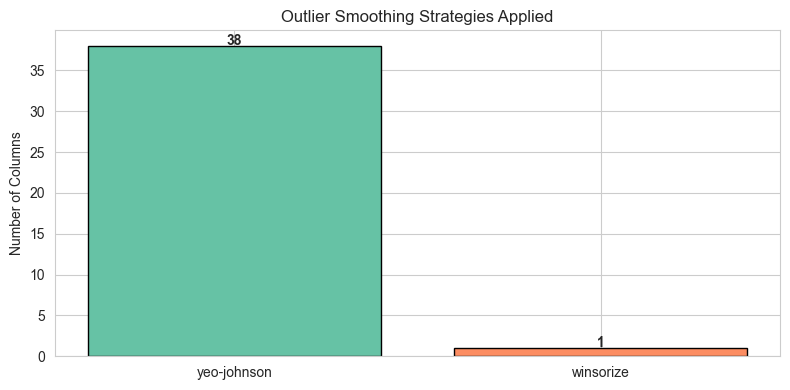


Step 8 complete.


In [10]:
print('=' * 70)
print('STEP 8: OUTLIER HANDLING (SMOOTHING ONLY — TRAIN-FIT)')
print('=' * 70)
print('Strategy: Outliers are NEVER removed.')
print('Transformations are FIT on training data only, then applied to both.')
print('All fitted objects are saved for inference reproducibility.\n')

numeric_cols = X_train_df.select_dtypes(include=[np.number]).columns.tolist()
outlier_report = {}
transformations_applied = {}
outlier_transformers = {}  # Save fitted objects for inference

print(f'Analyzing {len(numeric_cols)} numeric columns for outliers (using training data)...\n')

for col in numeric_cols:
    train_vals = X_train_df[col].dropna()
    if len(train_vals) == 0:
        continue

    # Skip binary/one-hot columns — smoothing a 0/1 column is meaningless
    unique_vals = set(train_vals.unique())
    if unique_vals.issubset({0, 1, 0.0, 1.0}):
        continue

    # Compute IQR bounds on TRAINING data only
    Q1 = train_vals.quantile(0.25)
    Q3 = train_vals.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    n_outliers = int(((train_vals < lower_bound) | (train_vals > upper_bound)).sum())
    outlier_pct = round(n_outliers / len(train_vals) * 100, 2)

    if n_outliers == 0:
        continue

    original_skew = float(stats.skew(train_vals))
    all_non_negative = (train_vals >= 0).all()

    # Test multiple smoothing strategies on TRAINING data
    candidates = {}

    # 1. Winsorizing (capping to IQR bounds from training)
    capped = train_vals.clip(lower=lower_bound, upper=upper_bound)
    candidates['winsorize'] = abs(float(stats.skew(capped)))

    # 2. Log1p transform (only for non-negative data)
    if all_non_negative:
        log_vals = np.log1p(train_vals)
        candidates['log1p'] = abs(float(stats.skew(log_vals)))

    # 3. Square root transform (only for non-negative data)
    if all_non_negative:
        sqrt_vals = np.sqrt(train_vals)
        candidates['sqrt'] = abs(float(stats.skew(sqrt_vals)))

    # 4. Yeo-Johnson power transform (works for any distribution)
    try:
        pt = PowerTransformer(method='yeo-johnson')
        pt.fit(train_vals.values.reshape(-1, 1))  # FIT on train only
        yj_vals = pt.transform(train_vals.values.reshape(-1, 1)).flatten()
        candidates['yeo-johnson'] = abs(float(stats.skew(yj_vals)))
    except Exception:
        pt = None

    if not candidates:
        continue

    # Pick strategy with lowest absolute skewness on training data
    best_strategy = min(candidates, key=candidates.get)
    best_skew = candidates[best_strategy]

    # Apply the winning strategy to BOTH train and test
    if best_strategy == 'winsorize':
        X_train_df[col] = X_train_df[col].clip(lower=lower_bound, upper=upper_bound)
        X_test_df[col] = X_test_df[col].clip(lower=lower_bound, upper=upper_bound)
        outlier_transformers[col] = {
            'strategy': 'winsorize', 'lower': float(lower_bound), 'upper': float(upper_bound)
        }
    elif best_strategy == 'log1p':
        X_train_df[col] = np.log1p(X_train_df[col].clip(lower=0))
        X_test_df[col] = np.log1p(X_test_df[col].clip(lower=0))
        outlier_transformers[col] = {'strategy': 'log1p'}
    elif best_strategy == 'sqrt':
        X_train_df[col] = np.sqrt(X_train_df[col].clip(lower=0))
        X_test_df[col] = np.sqrt(X_test_df[col].clip(lower=0))
        outlier_transformers[col] = {'strategy': 'sqrt'}
    elif best_strategy == 'yeo-johnson' and pt is not None:
        X_train_df[col] = pt.transform(X_train_df[col].values.reshape(-1, 1)).flatten()
        X_test_df[col] = pt.transform(X_test_df[col].values.reshape(-1, 1)).flatten()
        outlier_transformers[col] = {'strategy': 'yeo-johnson', 'fitted_pt': pt}

    transformations_applied[col] = best_strategy
    outlier_report[col] = {
        'n_outliers': n_outliers,
        'outlier_pct': outlier_pct,
        'original_skewness': round(original_skew, 4),
        'strategy_applied': best_strategy,
        'new_skewness': round(best_skew, 4),
        'candidates_tested': {k: round(v, 4) for k, v in candidates.items()}
    }

    print(f'  {col}:')
    print(f'    Outliers found  : {n_outliers} ({outlier_pct}%)')
    print(f'    Original skew   : {original_skew:.3f}')
    print(f'    Strategies tested: {", ".join(candidates.keys())}')
    for strat, sk in candidates.items():
        marker = ' <-- BEST' if strat == best_strategy else ''
        print(f'      {strat:<15} -> skew = {sk:.3f}{marker}')
    print(f'    Applied: {best_strategy} (new skew: {best_skew:.3f})')
    print()

# ─── Summary ─────────────────────────────────────────────────────────
if not outlier_report:
    print('No significant outliers detected in any column. Data looks clean.')
else:
    strategies_used = Counter(transformations_applied.values())
    print(f'--- Outlier Handling Summary ---')
    print(f'  Columns with outliers treated: {len(outlier_report)}')
    print(f'  Strategies breakdown:')
    for strat, count in strategies_used.most_common():
        print(f'    {strat}: {count} columns')
    print(f'  All transformers saved for inference ({len(outlier_transformers)} columns)')

    fig, ax = plt.subplots(figsize=(8, 4))
    strat_names = list(strategies_used.keys())
    strat_counts = list(strategies_used.values())
    ax.bar(strat_names, strat_counts, color=sns.color_palette('Set2', len(strat_names)),
           edgecolor='black')
    ax.set_title('Outlier Smoothing Strategies Applied')
    ax.set_ylabel('Number of Columns')
    for i, (name, cnt) in enumerate(zip(strat_names, strat_counts)):
        ax.text(i, cnt + 0.1, str(cnt), ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

PIPELINE_STATE['outlier_handling'] = {
    'total_columns_with_outliers': len(outlier_report),
    'transformations': transformations_applied,
    'details': outlier_report
}
print(f'\nStep 8 complete.')

## Step 9 — Feature Type Handling

**What:** Converts all non-numeric columns into numeric form so the model can process them. Boolean columns are cast to integers. Categorical columns are encoded based on their cardinality.

**Encoding strategy (fit on train only):**
- Binary (2 unique values) → **Label Encoding** (0/1)
- Low cardinality (3–10 unique values) → **One-Hot Encoding** (one column per category)
- Medium+ cardinality (>10 unique values) → **Frequency Encoding** (replace category with its training frequency)

**Why fit on train only:** If you encode using category frequencies from the full dataset, the test set frequencies influence the encoding — this is data leakage. Encoding learned from training data is then applied to test, with unseen categories mapped to frequency 0.

**Column alignment:** After one-hot encoding, the test set is realigned to exactly match training set columns — missing one-hot columns are filled with 0, extra test-only columns are dropped.

**Output:** `X_train_df` and `X_test_df` with all features numeric. `encoding_artifacts` dict saved for inference. `PIPELINE_STATE['feature_handling']` updated.

In [11]:
print('=' * 70)
print('STEP 9: FEATURE TYPE HANDLING (TRAIN-FIT)')
print('=' * 70)

numeric_cols_pre = X_train_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train_df.select_dtypes(include=['object', 'category']).columns.tolist()
bool_cols = X_train_df.select_dtypes(include=['bool']).columns.tolist()

print(f'\nFeature breakdown:')
print(f'  Numeric     : {len(numeric_cols_pre)} columns')
print(f'  Categorical : {len(categorical_cols)} columns')
print(f'  Boolean     : {len(bool_cols)} columns')

encoding_report = {}
encoding_artifacts = {}  # Save encoding objects for inference

# ─── Encode Categoricals ────────────────────────────────────────────
if categorical_cols:
    print(f'\n--- Encoding Categorical Columns (fit on TRAIN, apply to both) ---')
    for col in categorical_cols:
        n_unique = X_train_df[col].nunique()

        if n_unique <= 2:
            # Binary -> Label encode (fit on training categories)
            le_col = LabelEncoder()
            le_col.fit(X_train_df[col].astype(str))
            X_train_df[col] = le_col.transform(X_train_df[col].astype(str))
            # Handle unseen categories in test: map to most frequent training class
            test_vals = X_test_df[col].astype(str)
            known_mask = test_vals.isin(le_col.classes_)
            X_test_df[col] = 0  # default
            if known_mask.any():
                X_test_df.loc[known_mask, col] = le_col.transform(test_vals[known_mask])

            mapping = dict(zip(le_col.classes_.tolist(),
                               [int(x) for x in le_col.transform(le_col.classes_)]))
            encoding_artifacts[col] = {'method': 'label_encoding', 'encoder': le_col}
            encoding_report[col] = {'method': 'label_encoding', 'n_unique': n_unique,
                                    'mapping': mapping}
            print(f'  {col}: Binary ({n_unique}) -> Label Encoded {mapping}')

        elif n_unique <= 10:
            # Low cardinality -> One-hot encode (drop_first=False for tree models)
            # Get categories from TRAINING data
            train_cats = X_train_df[col].unique().tolist()
            encoding_artifacts[col] = {'method': 'one_hot', 'categories': train_cats}

            dummies_train = pd.get_dummies(X_train_df[col], prefix=col, dtype=int)
            X_train_df = pd.concat([X_train_df.drop(columns=[col]), dummies_train], axis=1)

            dummies_test = pd.get_dummies(X_test_df[col], prefix=col, dtype=int)
            X_test_df = pd.concat([X_test_df.drop(columns=[col]), dummies_test], axis=1)

            # Align columns: add missing cols as 0, drop extra cols
            for c in dummies_train.columns:
                if c not in X_test_df.columns:
                    X_test_df[c] = 0
            extra_test_cols = [c for c in dummies_test.columns if c not in dummies_train.columns]
            if extra_test_cols:
                X_test_df = X_test_df.drop(columns=extra_test_cols)
                print(f'    (Dropped {len(extra_test_cols)} test-only categories)')

            new_cols = dummies_train.columns.tolist()
            encoding_report[col] = {'method': 'one_hot_encoding', 'n_unique': n_unique,
                                    'new_columns': new_cols}
            print(f'  {col}: {n_unique} categories -> One-Hot ({len(new_cols)} columns, drop_first=False)')

        else:
            # Medium+ cardinality -> Frequency encode (frequencies from TRAIN only)
            freq_map = X_train_df[col].value_counts(normalize=True).to_dict()
            X_train_df[col] = X_train_df[col].map(freq_map).fillna(0).astype(float)
            X_test_df[col] = X_test_df[col].map(freq_map).fillna(0).astype(float)
            encoding_artifacts[col] = {'method': 'frequency', 'freq_map': freq_map}
            encoding_report[col] = {'method': 'frequency_encoding', 'n_unique': n_unique}
            print(f'  {col}: {n_unique} categories -> Frequency Encoded (train frequencies)')
else:
    print(f'\n  No categorical columns to encode.')

# ─── Convert Booleans ───────────────────────────────────────────────
if bool_cols:
    print(f'\n--- Converting Boolean Columns ---')
    for col in bool_cols:
        X_train_df[col] = X_train_df[col].astype(int)
        X_test_df[col] = X_test_df[col].astype(int)
        print(f'  {col}: bool -> int')

# ─── Final check: ensure same columns in both ───────────────────────
# Reorder test columns to match train
X_test_df = X_test_df.reindex(columns=X_train_df.columns, fill_value=0)

numeric_cols_final = X_train_df.select_dtypes(include=[np.number]).columns.tolist()
non_numeric = [c for c in X_train_df.columns if c not in numeric_cols_final]

if non_numeric:
    print(f'\n  WARNING: {len(non_numeric)} column(s) still non-numeric: {non_numeric}')
    print(f'  Dropping them to proceed safely.')
    X_train_df = X_train_df.drop(columns=non_numeric)
    X_test_df = X_test_df.drop(columns=non_numeric)

print(f'\n  All features are now numeric: {X_train_df.shape[1]} columns')
print(f'  Train shape: {X_train_df.shape}')
print(f'  Test  shape: {X_test_df.shape}')

PIPELINE_STATE['feature_handling'] = {
    'original_numeric': len(numeric_cols_pre),
    'original_categorical': len(categorical_cols),
    'encodings': encoding_report,
    'final_feature_count': int(X_train_df.shape[1])
}
print(f'\nStep 9 complete.')

STEP 9: FEATURE TYPE HANDLING (TRAIN-FIT)

Feature breakdown:
  Numeric     : 52 columns
  Categorical : 0 columns
  Boolean     : 0 columns

  No categorical columns to encode.

  All features are now numeric: 52 columns
  Train shape: (12000, 52)
  Test  shape: (3000, 52)

Step 9 complete.


## Step 10 — Exploratory Data Analysis & Visualization

**What:** Analyses and visualises the training data across five dimensions to understand the data before any model is trained.

**Analysis performed:**
1. **Distribution plots** — histogram for every feature, paginated across all features in groups of 12, computed on training data only
2. **Correlation analysis** — Pearson correlation matrix; highly correlated pairs (|r| >= 0.85) listed for review
3. **Statistical tests (Kruskal-Wallis H-test)** — non-parametric test measuring whether each feature's distribution differs significantly across the 5 mental health classes (p < 0.05 = significant)
4. **Levene's test** — tests whether a feature's variance differs across classes (unequal variance = feature separates classes by spread, not just mean)
5. **Box plots** — top 8 most significant features plotted per class for visual separability inspection
6. **Per-class mean comparison** — table and heatmap showing the mean value of each feature broken down by class, highlighting which class has the highest mean per feature

**Why training data only:** EDA on the full dataset would expose test set patterns before model training, violating the principle of a held-out evaluation set.

**Output:** Plots displayed inline. `stat_test_results`, `levene_results`, `skewness_report` dicts used in Step 11 for feature selection. `PIPELINE_STATE['eda']` updated.

STEP 10: EXPLORATORY DATA ANALYSIS & VISUALIZATION (TRAIN ONLY)

Analyzing 52 numeric features (training data only)...

--- 10.1 Feature Distribution Analysis (All Features) ---
  Top 10 most skewed features:
    positive_emotion_word_ratio              skew=  0.654  kurtosis= -1.392  [LOW]
    negative_emotion_word_ratio              skew= -0.477  kurtosis= -1.508  [LOW]
    fear_word_frequency                      skew= -0.214  kurtosis= -1.067  [LOW]
    emotional_intensity_ratio                skew=    nan  kurtosis=    nan  [LOW]
    semantic_coherence_score                 skew=  0.390  kurtosis= -0.900  [LOW]
    max_negative_emotion                     skew= -0.165  kurtosis= -0.985  [LOW]
    joy_frequency                            skew=  0.161  kurtosis= -1.249  [LOW]
    threat_anticipation_language             skew= -0.149  kurtosis= -0.804  [LOW]
    cognitive_load_score                     skew=  0.146  kurtosis= -0.993  [LOW]
    sadness_word_frequency                  

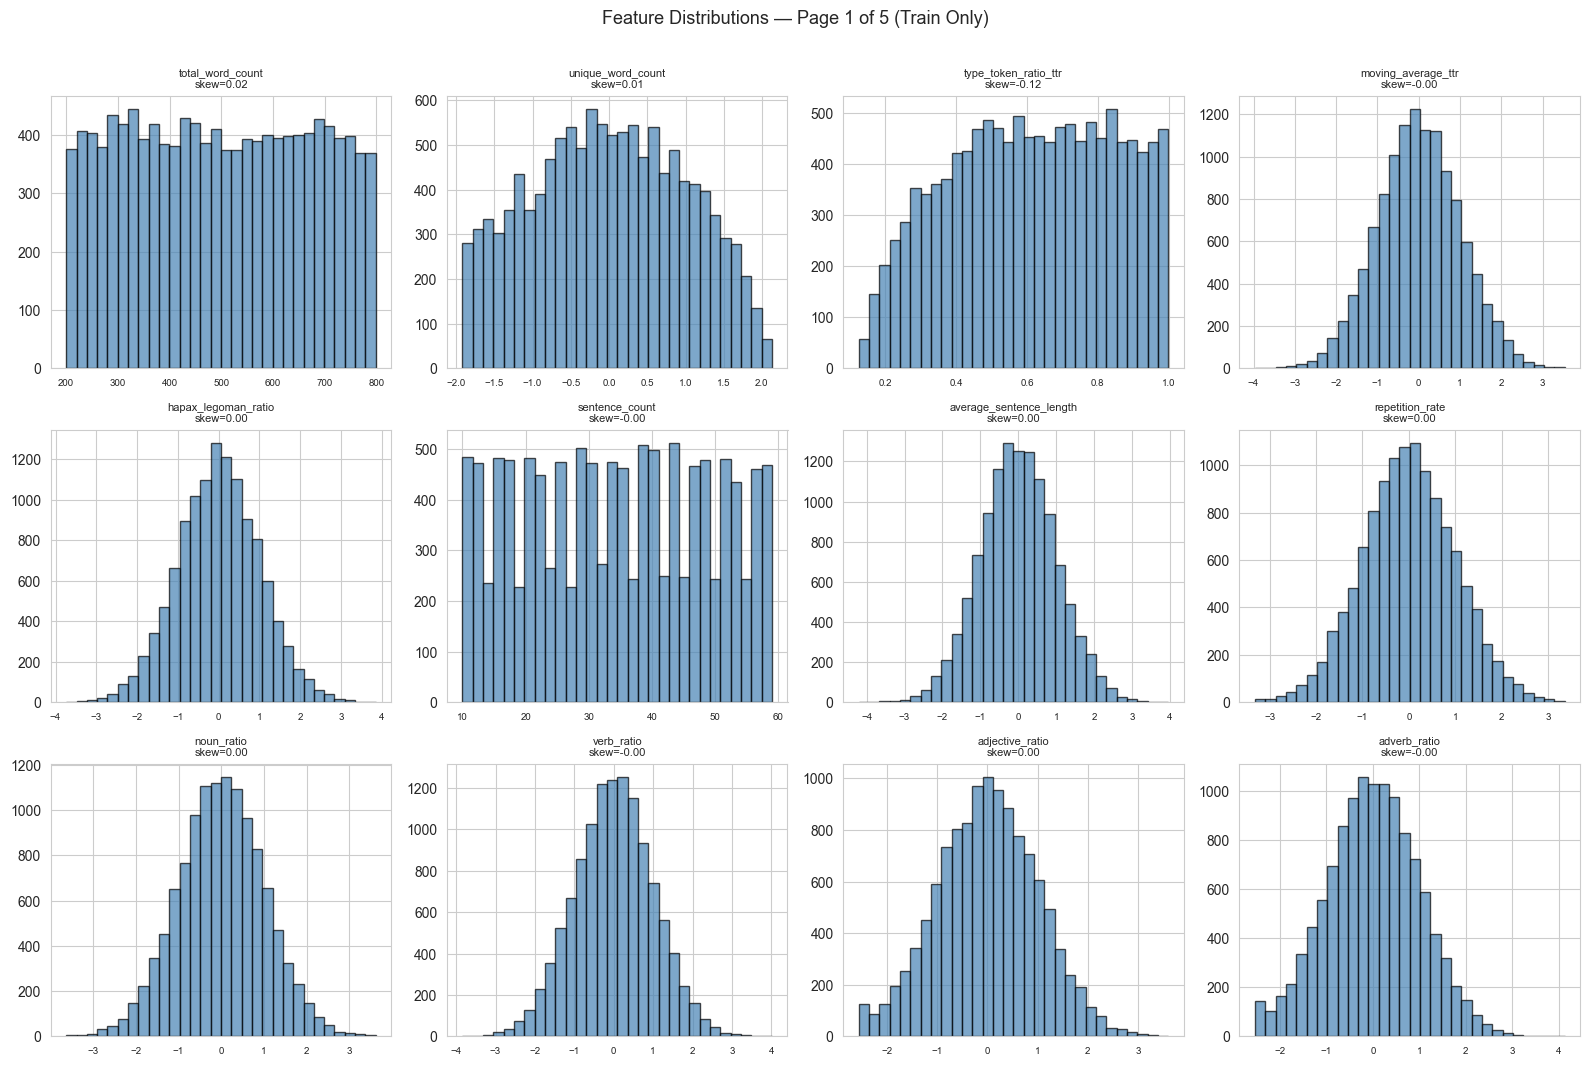

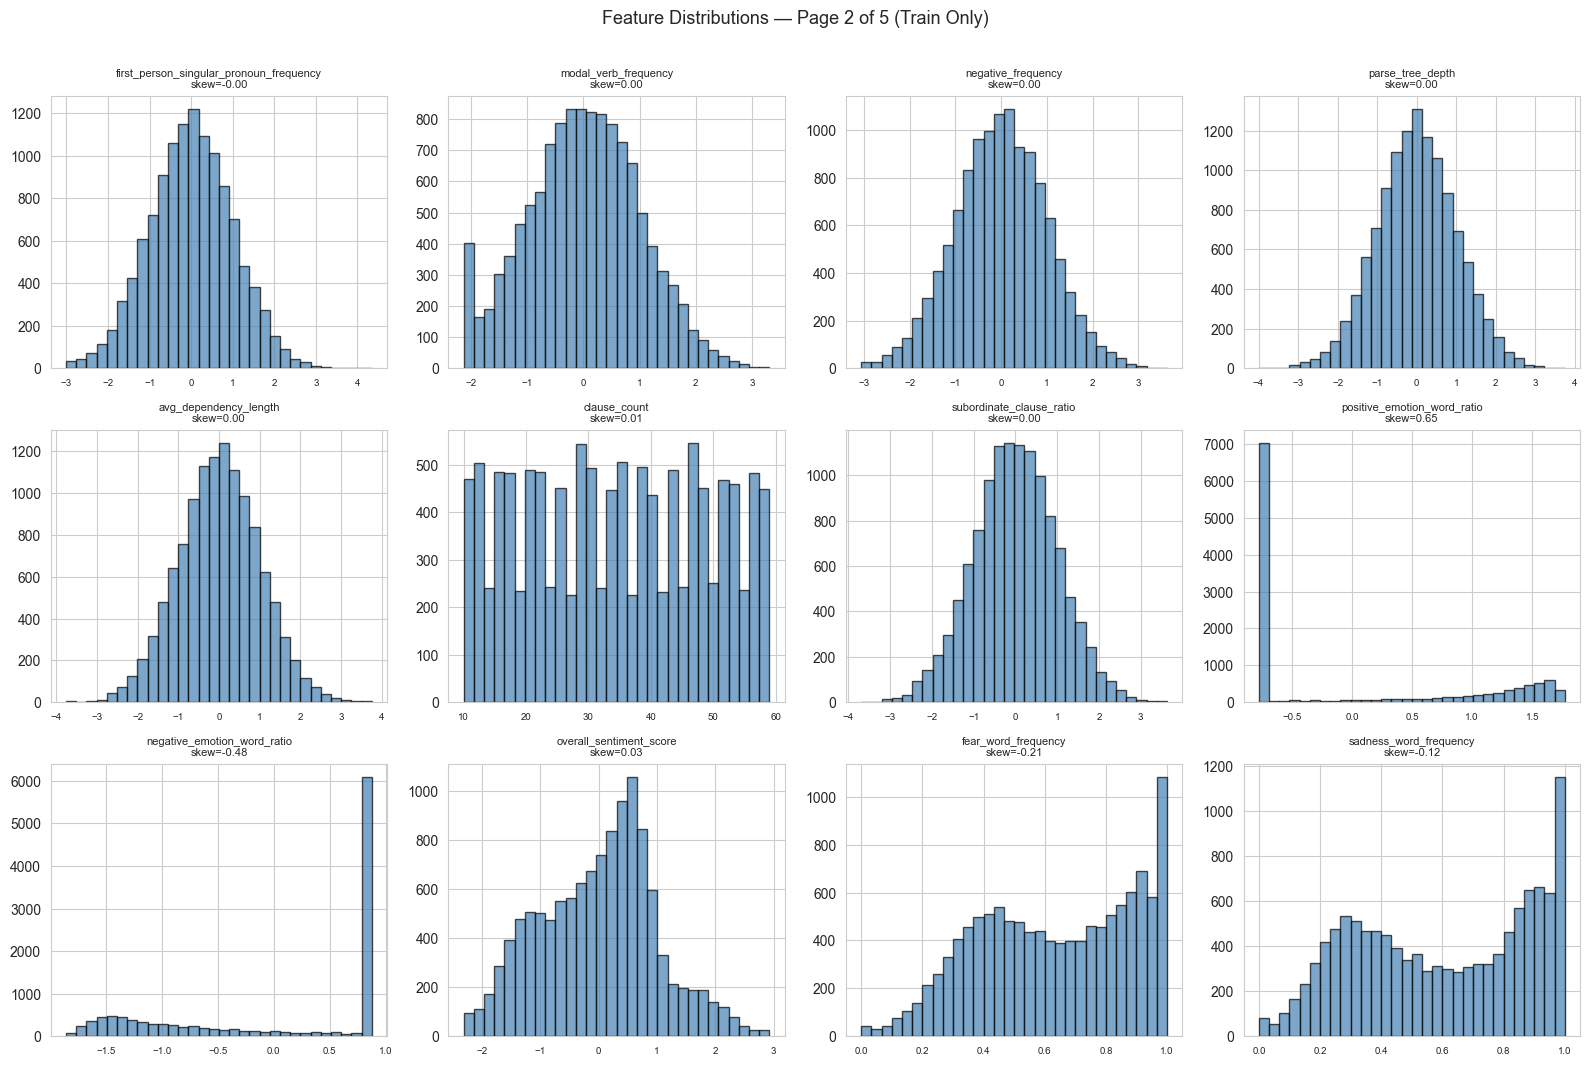

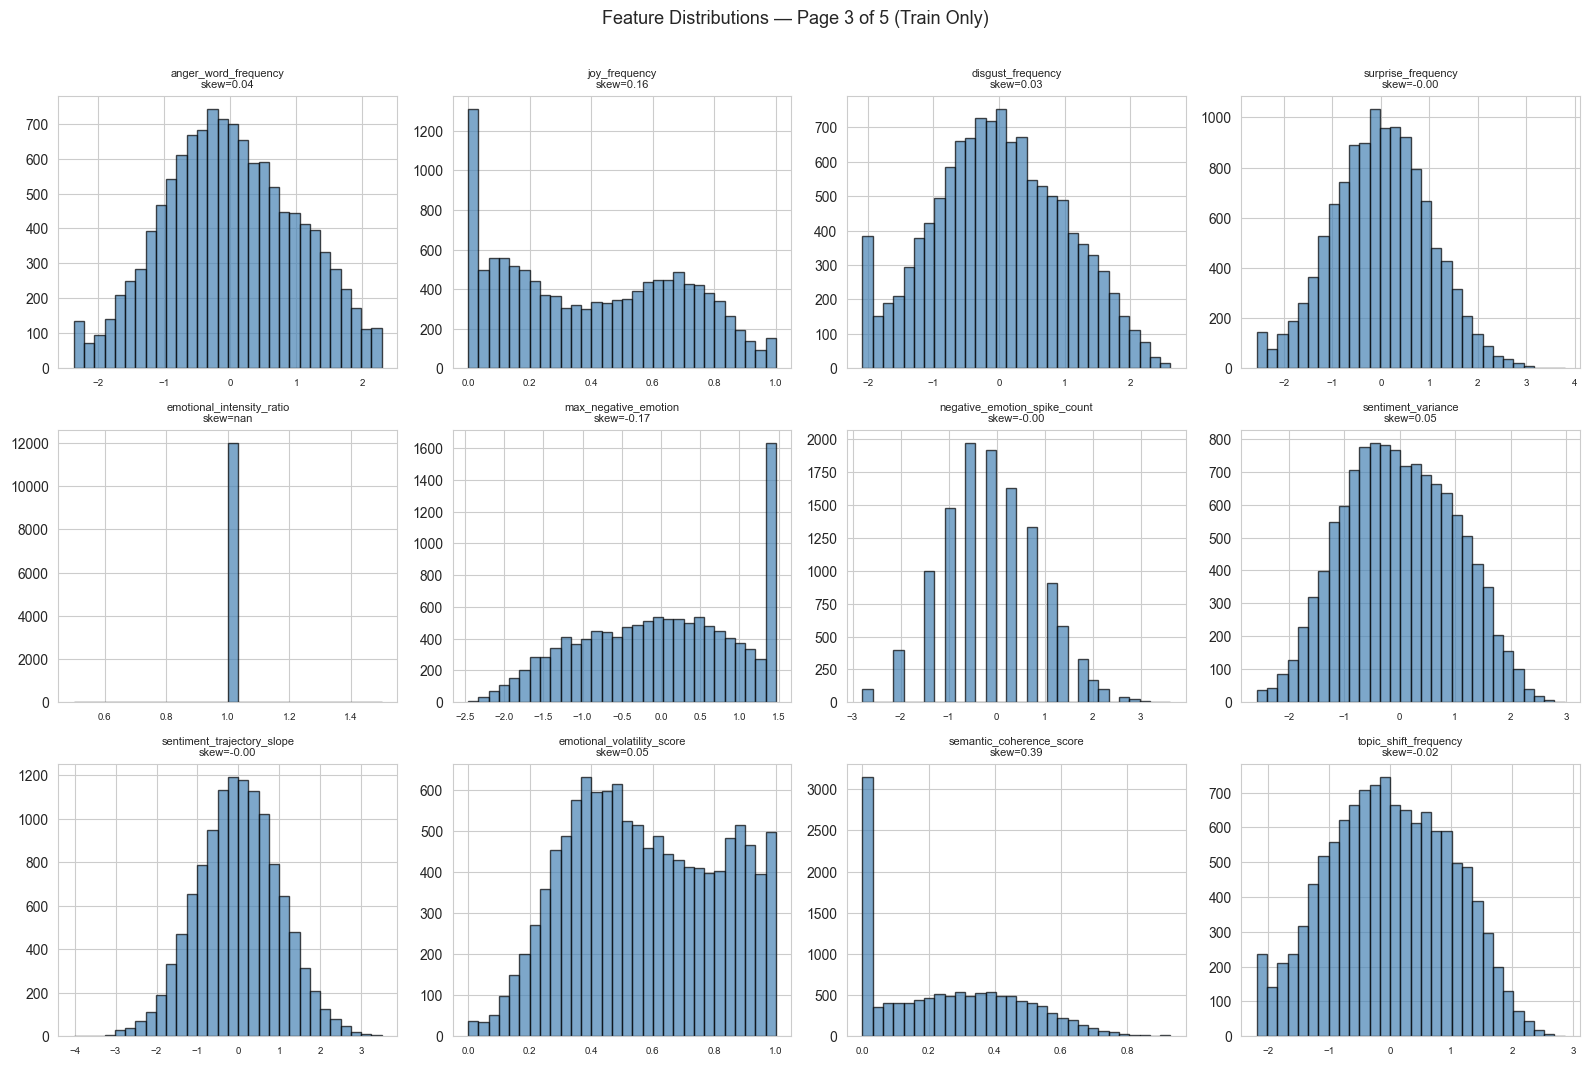

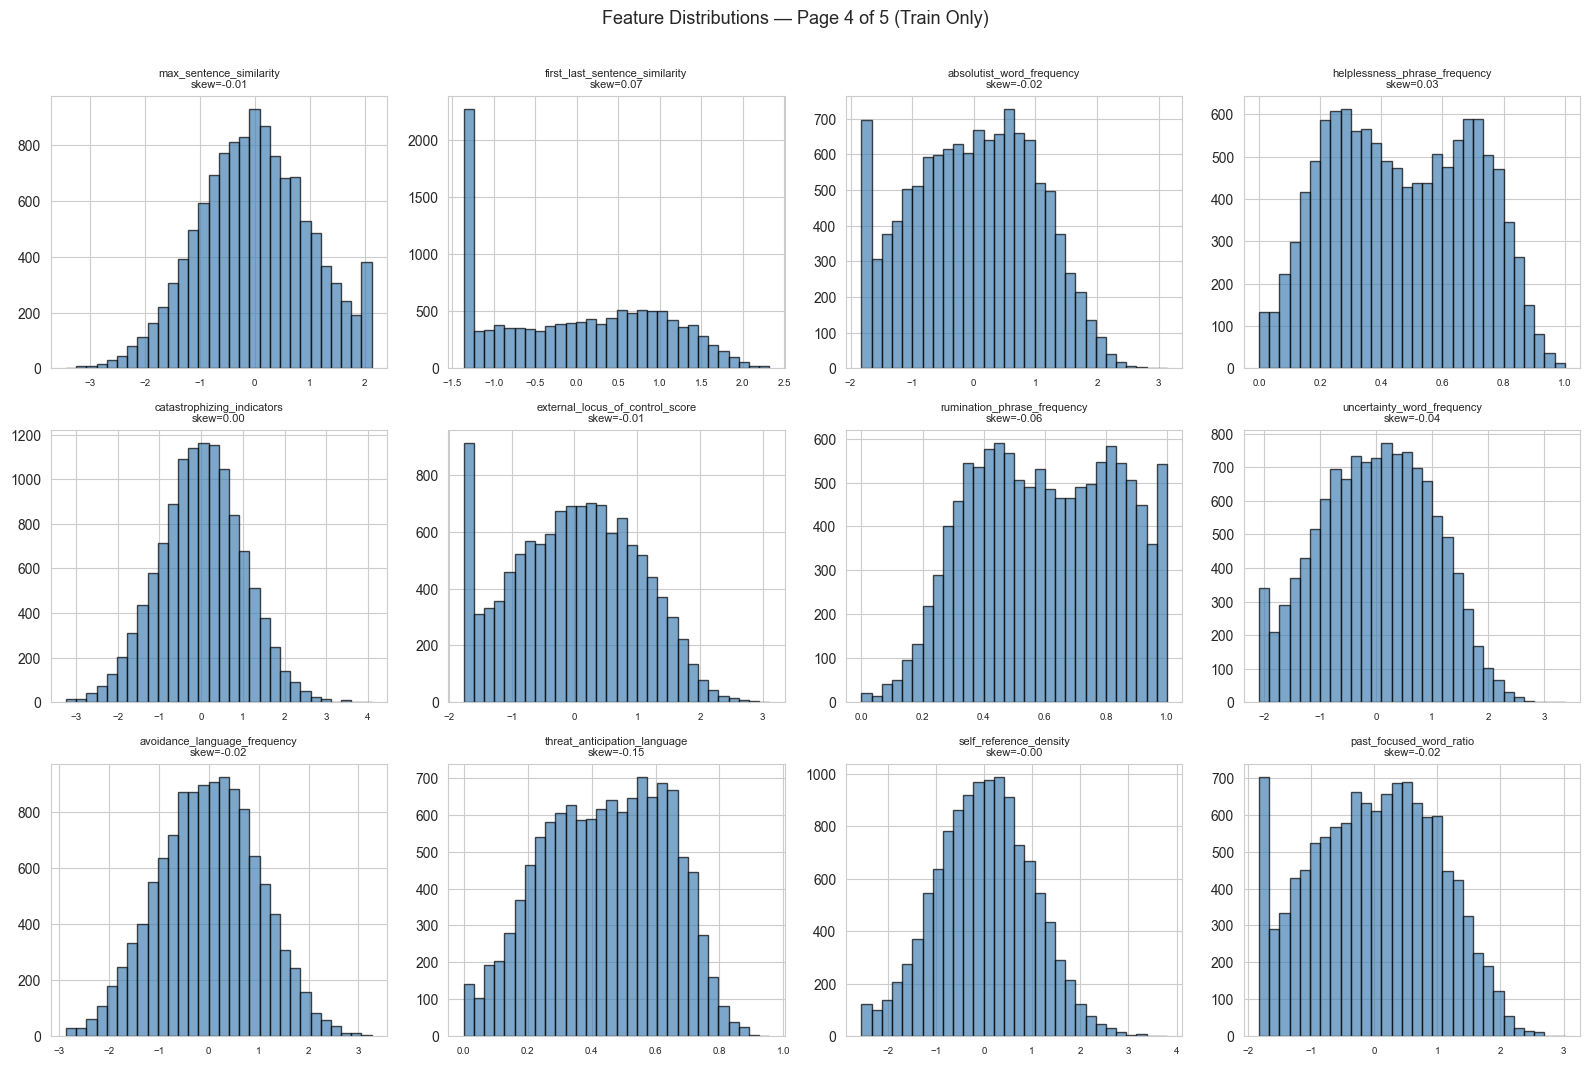

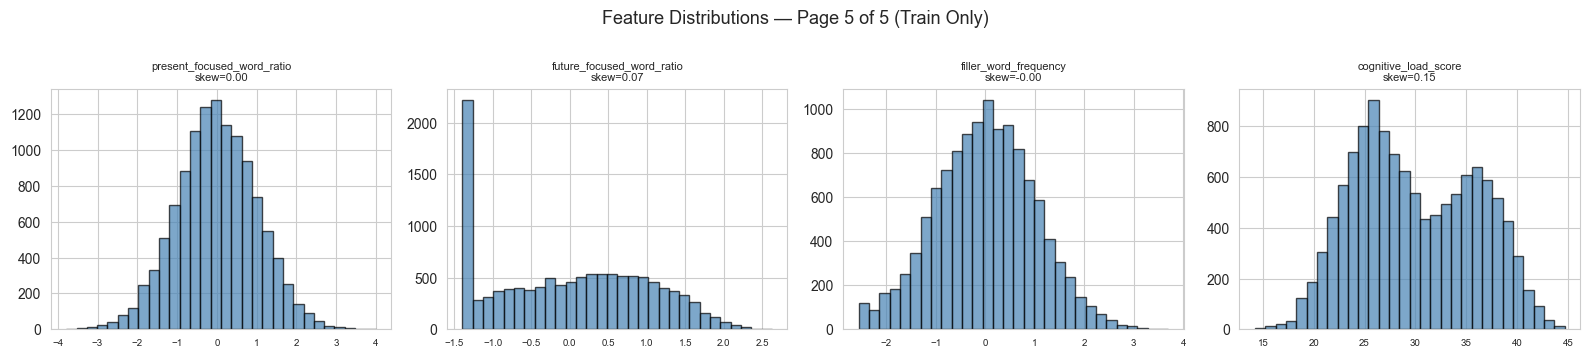


--- 10.2 Correlation Analysis ---
  Found 19 highly correlated pairs (|r| >= 0.85):
    sadness_word_frequency <-> joy_frequency: r = 0.9653
    positive_emotion_word_ratio <-> negative_emotion_word_ratio: r = 0.9399
    emotional_volatility_score <-> semantic_coherence_score: r = 0.934
    negative_emotion_word_ratio <-> sadness_word_frequency: r = 0.9318
    anger_word_frequency <-> disgust_frequency: r = 0.9285
    sadness_word_frequency <-> rumination_phrase_frequency: r = 0.9282
    sadness_word_frequency <-> helplessness_phrase_frequency: r = 0.9179
    fear_word_frequency <-> threat_anticipation_language: r = 0.9113
    semantic_coherence_score <-> first_last_sentence_similarity: r = 0.9085
    negative_emotion_word_ratio <-> joy_frequency: r = 0.9045
    joy_frequency <-> rumination_phrase_frequency: r = 0.8943
    helplessness_phrase_frequency <-> rumination_phrase_frequency: r = 0.8921
    joy_frequency <-> helplessness_phrase_frequency: r = 0.886
    positive_emotion_word_r

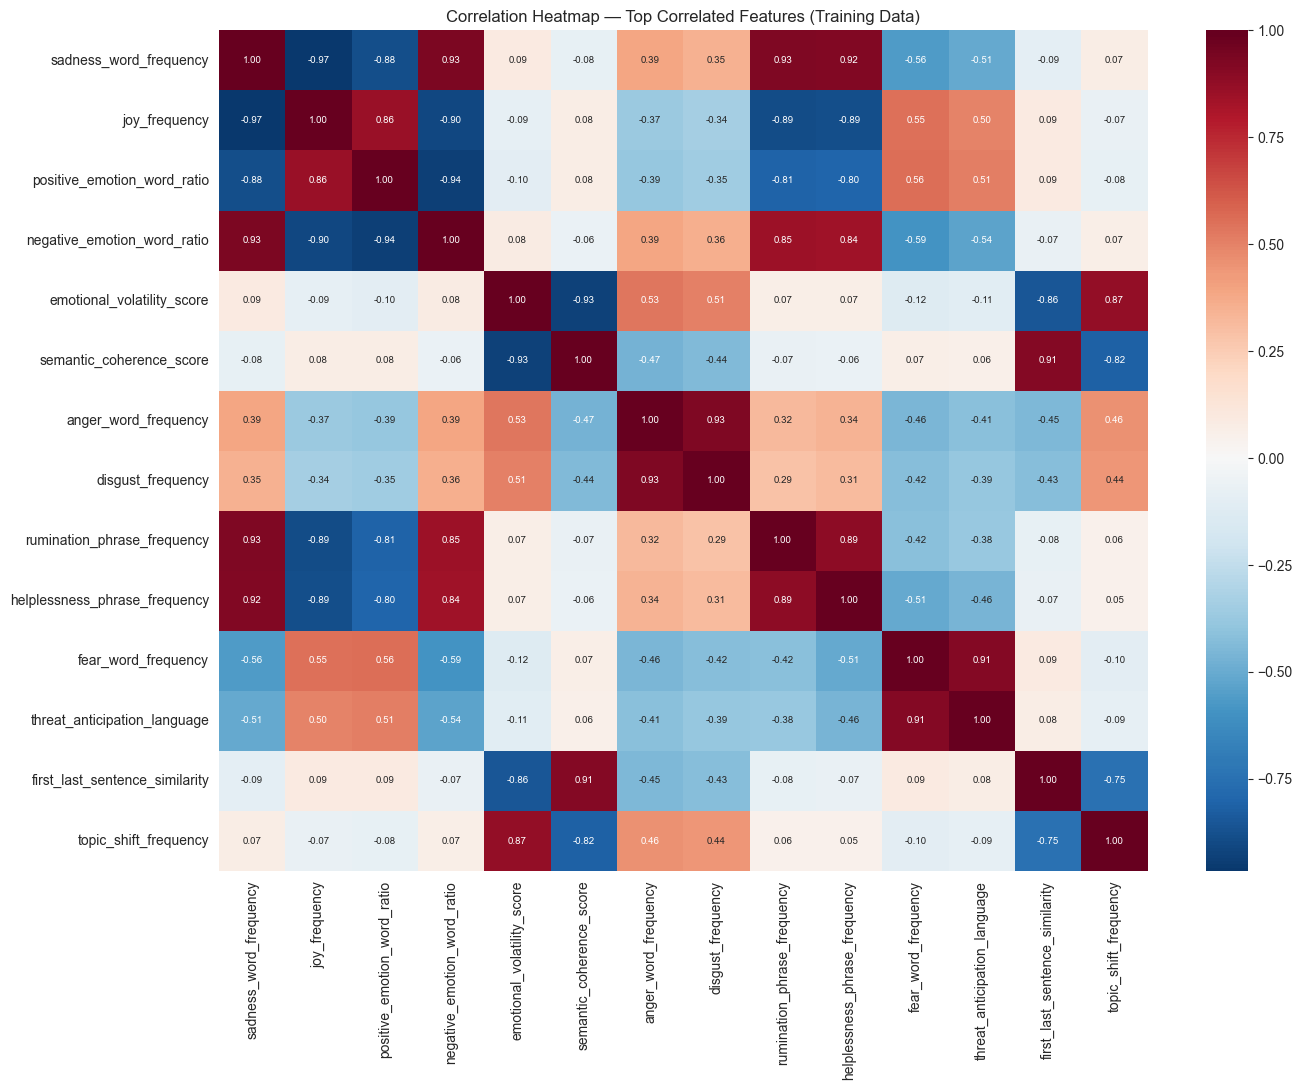


--- 10.3 Statistical Tests (Feature vs Target — Training Data) ---
  Running Kruskal-Wallis H-test (non-parametric) for each feature vs target...
  Results: 26/52 features statistically significant (p < 0.05)

  Top 10 features by H-statistic:
    sadness_word_frequency                   H=   8624.88  p=0.00e+00  [SIG]
    emotional_intensity_ratio                H=       nan  p=nan  [n.s.]
    emotional_volatility_score               H=   9077.88  p=0.00e+00  [SIG]
    overall_sentiment_score                  H=   8936.72  p=0.00e+00  [SIG]
    fear_word_frequency                      H=   8625.32  p=0.00e+00  [SIG]
    cognitive_load_score                     H=   8576.07  p=0.00e+00  [SIG]
    helplessness_phrase_frequency            H=   8565.49  p=0.00e+00  [SIG]
    semantic_coherence_score                 H=   8280.58  p=0.00e+00  [SIG]
    joy_frequency                            H=   8163.52  p=0.00e+00  [SIG]
    negative_emotion_word_ratio              H=   8042.43  p=0.00e

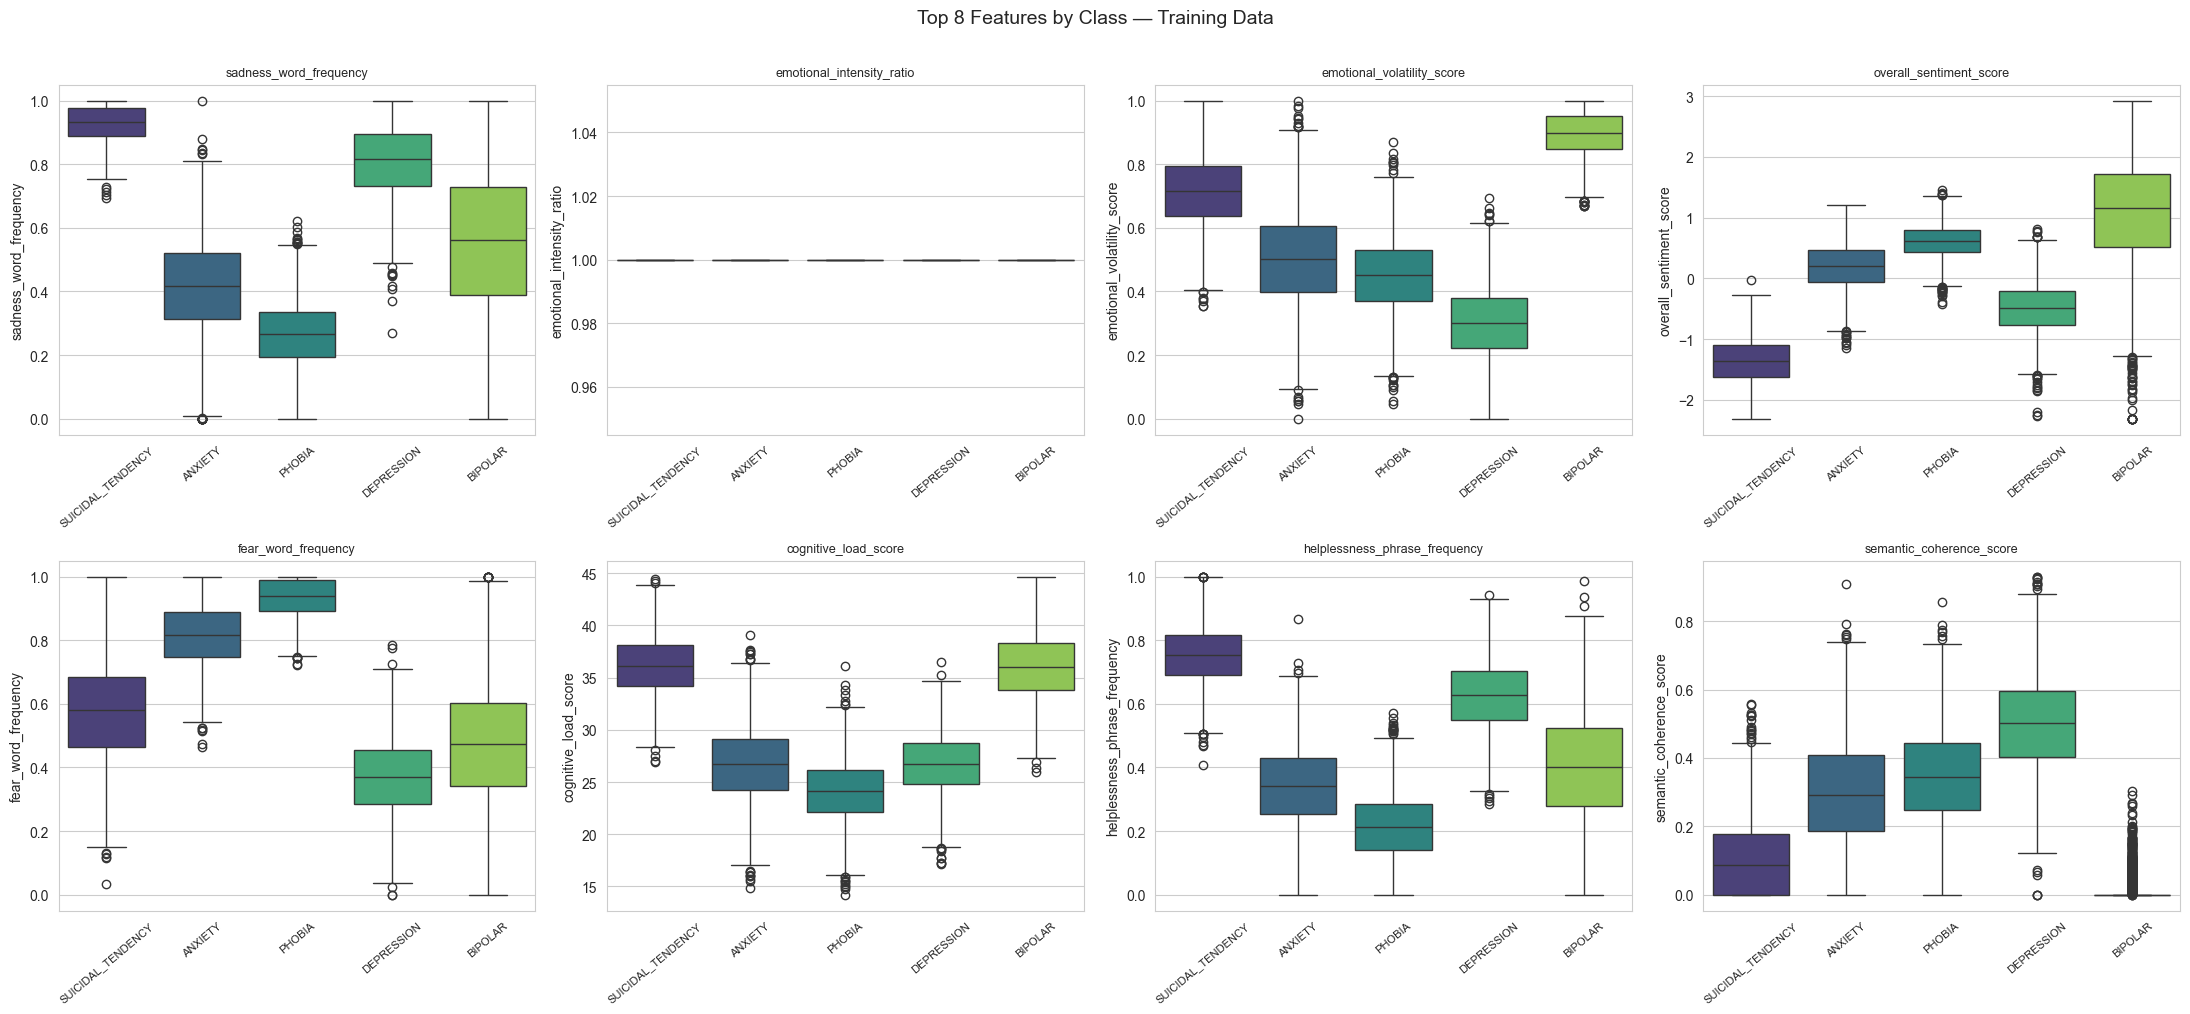


--- 10.6 Per-Class Feature Mean Comparison ---
  Mean value of each feature broken down by class (training data only).

  Top 15 features with highest mean difference across classes:
  Feature                                   Min class mean   Max class mean       Range
  -------------------------------------------------------------------------------------
  cognitive_load_score                             24.1556          36.1298     11.9741
  total_word_count                                494.5913         501.9950      7.4038
  overall_sentiment_score                          -1.3657           1.0615      2.4272
  topic_shift_frequency                            -1.0142           1.1640      2.1782
  anger_word_frequency                             -1.0767           1.0981      2.1748
  sentiment_variance                               -1.0325           1.0760      2.1086
  negative_emotion_word_ratio                      -1.2309           0.8771      2.1080
  first_last_sentence_si

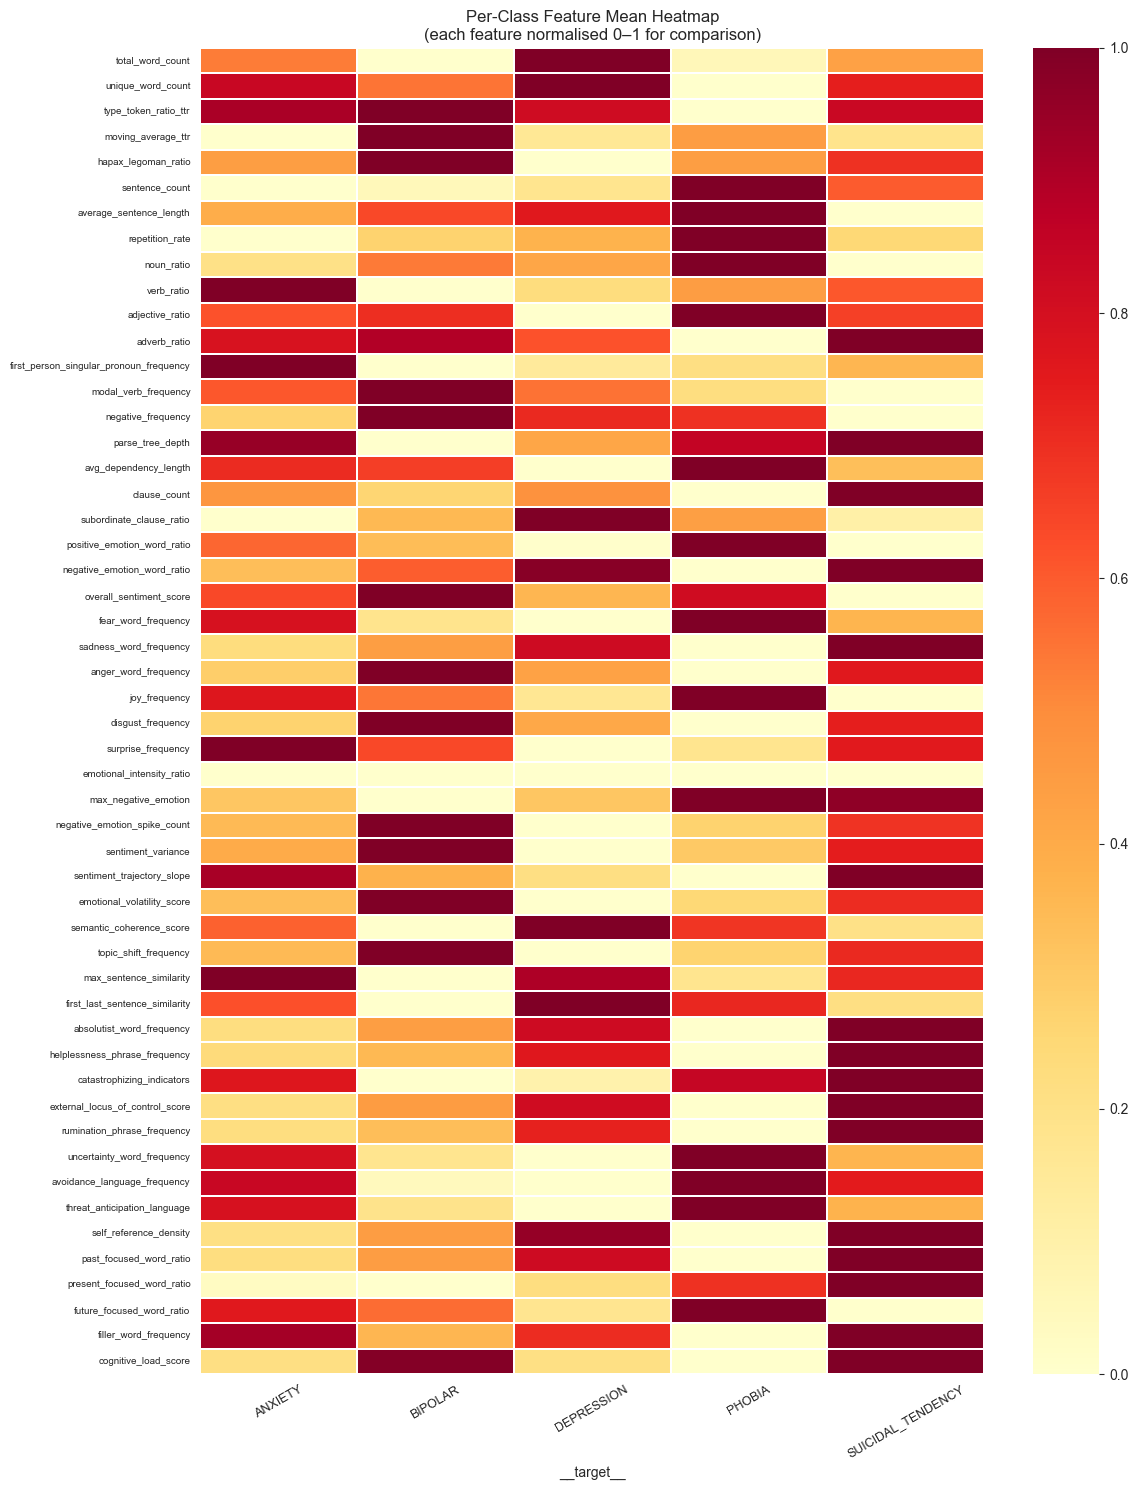


Step 10 complete.


In [12]:
print('=' * 70)
print('STEP 10: EXPLORATORY DATA ANALYSIS & VISUALIZATION (TRAIN ONLY)')
print('=' * 70)

numeric_cols_eda = X_train_df.select_dtypes(include=[np.number]).columns.tolist()
n_feat = len(numeric_cols_eda)
print(f'\nAnalyzing {n_feat} numeric features (training data only)...\n')

# ─── 10.1 Distribution Analysis — ALL features, paginated ────────────
print('--- 10.1 Feature Distribution Analysis (All Features) ---')
skewness_report = {}
for col in numeric_cols_eda:
    vals = X_train_df[col].dropna()
    sk = float(stats.skew(vals)) if len(vals) > 2 else 0.0
    kt = float(stats.kurtosis(vals)) if len(vals) > 2 else 0.0
    skewness_report[col] = {'skewness': round(sk, 4), 'kurtosis': round(kt, 4)}

sorted_skew = sorted(skewness_report.items(), key=lambda x: abs(x[1]['skewness']), reverse=True)
print(f'  Top 10 most skewed features:')
for col, vals in sorted_skew[:10]:
    label = 'HIGH' if abs(vals['skewness']) > 2 else 'MOD' if abs(vals['skewness']) > 1 else 'LOW'
    print(f'    {col:<40} skew={vals["skewness"]:>7.3f}  kurtosis={vals["kurtosis"]:>7.3f}  [{label}]')

# Paginated distribution plots — 12 per page, covers ALL features
PAGE_SIZE = 12
n_pages = (n_feat + PAGE_SIZE - 1) // PAGE_SIZE
print(f'\n  Plotting {n_feat} features across {n_pages} page(s) of {PAGE_SIZE}...')

for page in range(n_pages):
    start = page * PAGE_SIZE
    end   = min(start + PAGE_SIZE, n_feat)
    cols_page = numeric_cols_eda[start:end]
    n_this_page = len(cols_page)

    n_rows = (n_this_page + 3) // 4
    fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3.5))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 and n_this_page == 1 else list(axes.flatten())

    for i, col in enumerate(cols_page):
        axes[i].hist(X_train_df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        sk = skewness_report[col]['skewness']
        axes[i].set_title(f'{col}\nskew={sk:.2f}', fontsize=8)
        axes[i].tick_params(axis='x', labelsize=7)
    for i in range(n_this_page, len(axes)):
        axes[i].set_visible(False)

    plt.suptitle(f'Feature Distributions — Page {page+1} of {n_pages} (Train Only)', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

# ─── 10.2 Correlation Analysis ───────────────────────────────────────
print('\n--- 10.2 Correlation Analysis ---')
corr_matrix = X_train_df[numeric_cols_eda].corr()

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = abs(corr_matrix.iloc[i, j])
        if r >= 0.85:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(float(r), 4)))

if high_corr_pairs:
    high_corr_pairs.sort(key=lambda x: x[2], reverse=True)
    print(f'  Found {len(high_corr_pairs)} highly correlated pairs (|r| >= 0.85):')
    for c1, c2, r in high_corr_pairs[:15]:
        print(f'    {c1} <-> {c2}: r = {r}')
    if len(high_corr_pairs) > 15:
        print(f'    ... and {len(high_corr_pairs) - 15} more pairs')
else:
    print('  No highly correlated pairs found (|r| >= 0.85). Features look independent.')

# Correlation heatmap — full if <= 40 features, top-correlated subset otherwise
if n_feat <= 40:
    fig, ax = plt.subplots(figsize=(min(20, n_feat * 0.5 + 2), min(16, n_feat * 0.45 + 2)))
    sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, ax=ax,
                xticklabels=True, yticklabels=True, linewidths=0.3)
    ax.set_title('Feature Correlation Heatmap (Training Data)')
    ax.tick_params(axis='x', labelsize=7, rotation=90)
    ax.tick_params(axis='y', labelsize=7, rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print(f'  Showing top-correlated subset heatmap ({n_feat} total features).')
    if high_corr_pairs:
        top_cols = list(dict.fromkeys(
            [c for c1, c2, _ in high_corr_pairs[:15] for c in (c1, c2)]
        ))[:24]
        fig, ax = plt.subplots(figsize=(14, 11))
        sns.heatmap(corr_matrix.loc[top_cols, top_cols], cmap='RdBu_r', center=0,
                    ax=ax, annot=True, fmt='.2f', annot_kws={'size': 7})
        ax.set_title('Correlation Heatmap — Top Correlated Features (Training Data)')
        plt.tight_layout()
        plt.show()

# ─── 10.3 Statistical Tests — Kruskal-Wallis ────────────────────────
print('\n--- 10.3 Statistical Tests (Feature vs Target — Training Data) ---')
stat_test_results = {}
train_target_labels = le.inverse_transform(y_train) if le else y_train
classes_unique = np.unique(train_target_labels)

print('  Running Kruskal-Wallis H-test (non-parametric) for each feature vs target...')
for col in numeric_cols_eda:
    groups = [X_train_df[col][train_target_labels == c].dropna().values for c in classes_unique]
    groups = [g for g in groups if len(g) >= 2]
    if len(groups) >= 2:
        h_stat, p_val = stats.kruskal(*groups)
        stat_test_results[col] = {
            'test': 'kruskal_wallis',
            'H_statistic': round(float(h_stat), 4),
            'p_value': float(p_val),
            'significant': bool(p_val < 0.05)
        }

sig_count = sum(1 for v in stat_test_results.values() if v['significant'])
print(f'  Results: {sig_count}/{len(stat_test_results)} features statistically significant (p < 0.05)')

sorted_tests = sorted(stat_test_results.items(), key=lambda x: x[1]['H_statistic'], reverse=True)
print(f'\n  Top 10 features by H-statistic:')
for col, vals in sorted_tests[:10]:
    sig = 'SIG' if vals['significant'] else 'n.s.'
    print(f'    {col:<40} H={vals["H_statistic"]:>10.2f}  p={vals["p_value"]:.2e}  [{sig}]')

# ─── 10.4 Levene's Test ──────────────────────────────────────────────
print(f"\n--- 10.4 Levene's Test (Equality of Variances Across Classes) ---")
print("  Tests if a feature's spread/variance differs across target classes.")
levene_results = {}

for col in numeric_cols_eda:
    groups = [X_train_df[col][train_target_labels == c].dropna().values for c in classes_unique]
    groups = [g for g in groups if len(g) >= 2]
    if len(groups) >= 2:
        lev_stat, lev_p = stats.levene(*groups)
        levene_results[col] = {
            'W_statistic': round(float(lev_stat), 4),
            'p_value': float(lev_p),
            'unequal_variance': bool(lev_p < 0.05)
        }

lev_sig = sum(1 for v in levene_results.values() if v['unequal_variance'])
print(f'  Results: {lev_sig}/{len(levene_results)} features have unequal variance across classes (p < 0.05)')

sorted_levene = sorted(levene_results.items(), key=lambda x: x[1]['W_statistic'], reverse=True)
print(f'\n  Top 10 features by Levene W-statistic:')
for col, vals in sorted_levene[:10]:
    sig = 'UNEQ' if vals['unequal_variance'] else 'EQ'
    print(f'    {col:<40} W={vals["W_statistic"]:>10.2f}  p={vals["p_value"]:.2e}  [{sig}]')

PIPELINE_STATE['levene_test'] = {
    'features_with_unequal_variance': lev_sig,
    'total_tested': len(levene_results),
    'top_10': [(col, vals['W_statistic']) for col, vals in sorted_levene[:10]]
}

# ─── 10.5 Box Plots — Top 8 Features by Class ────────────────────────
if len(sorted_tests) > 0:
    print(f'\n--- 10.5 Box Plots by Class — Top 8 Features (Training Data) ---')
    top_feat_names = [col for col, _ in sorted_tests[:8]]
    plot_df = X_train_df.copy()
    plot_df['__target__'] = train_target_labels

    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    axes = axes.flatten()
    for i, col in enumerate(top_feat_names):
        sns.boxplot(data=plot_df, x='__target__', y=col, ax=axes[i], palette='viridis')
        axes[i].set_title(col, fontsize=9)
        axes[i].tick_params(axis='x', rotation=40, labelsize=8)
        axes[i].set_xlabel('')
    for i in range(len(top_feat_names), len(axes)):
        axes[i].set_visible(False)
    plt.suptitle('Top 8 Features by Class — Training Data', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

# ─── 10.6 Per-Class Feature Mean Comparison ─── ITEM 6 ───────────────
print(f'\n--- 10.6 Per-Class Feature Mean Comparison ---')
print('  Mean value of each feature broken down by class (training data only).')

plot_df2 = X_train_df.copy()
plot_df2['__target__'] = train_target_labels
class_means = plot_df2.groupby('__target__')[numeric_cols_eda].mean()

# Print top 15 features with highest between-class range (most discriminative)
feature_range = (class_means.max() - class_means.min()).sort_values(ascending=False)
print(f'\n  Top 15 features with highest mean difference across classes:')
print(f'  {"Feature":<40} {"Min class mean":>15}  {"Max class mean":>15}  {"Range":>10}')
print(f'  {"-"*85}')
for feat in feature_range.index[:15]:
    min_val = class_means[feat].min()
    max_val = class_means[feat].max()
    rng     = max_val - min_val
    print(f'  {feat:<40} {min_val:>15.4f}  {max_val:>15.4f}  {rng:>10.4f}')

# Heatmap of class means — all features vs all classes
# Normalise each feature to [0,1] for fair visual comparison across different scales
class_means_norm = (class_means - class_means.min()) / (class_means.max() - class_means.min() + 1e-9)

fig_h = max(10, int(n_feat * 0.3))
fig, ax = plt.subplots(figsize=(len(classes_unique) * 2 + 2, fig_h))
sns.heatmap(
    class_means_norm.T,
    cmap='YlOrRd', ax=ax,
    annot=False, linewidths=0.3,
    xticklabels=class_means_norm.index,
    yticklabels=class_means_norm.columns
)
ax.set_title('Per-Class Feature Mean Heatmap\n(each feature normalised 0–1 for comparison)', fontsize=12)
ax.tick_params(axis='x', labelsize=9, rotation=30)
ax.tick_params(axis='y', labelsize=7, rotation=0)
plt.tight_layout()
plt.show()

PIPELINE_STATE['eda'] = {
    'n_features_analyzed': n_feat,
    'n_pages_plotted': n_pages,
    'significant_features_kruskal': sig_count,
    'high_corr_pairs_count': len(high_corr_pairs),
    'levene_features_unequal_var': lev_sig,
    'skewness': skewness_report,
}

print(f'\nStep 10 complete.')

## Step 11 — Feature Selection (Multi-Method Consensus)

**What:** Progressively eliminates low-signal and redundant features using four independent methods, then builds a consensus ranking to decide which features to keep.

**Methods applied in order:**
1. **Correlation filtering** — removes one feature from each highly correlated pair (|r| >= 0.85), keeping the one more related to the target
2. **Feature importance** — XGBoost (GPU) or Random Forest (CPU) ranks features by split usefulness; top-25% are protected from VIF removal
3. **VIF (Variance Inflation Factor)** — iteratively removes the most multicollinear unprotected feature (VIF > 10) until all VIF <= 10
4. **Mutual Information** — measures non-linear statistical dependency between each feature and the target; zero MI = no predictive relationship

**Consensus ranking:** Each feature receives a rank from each method. The average rank across all four methods is the consensus score — lower is better.

**Pruning rule (conservative):** A feature is dropped only if **both** of the following are true:
- Mutual Information score = 0 (no measurable predictive signal)
- Kruskal-Wallis p-value > 0.05 (not statistically significant vs target)

If either condition is false, the feature is kept.

**Why conservative pruning:** With 52 features and a balanced dataset of 15,000 samples, aggressive pruning risks discarding real signal. We only drop features with provably zero contribution by two independent tests.

**Output:** Reduced `X_train_df` and `X_test_df` with only selected features. `PIPELINE_STATE['feature_selection']` updated.

STEP 11: FEATURE SELECTION (MULTI-METHOD CONSENSUS — TRAIN ONLY)

Starting with 52 features.

--- 11.1 Correlation-Based Filtering ---
  Removing 11 redundant features:
    [-] disgust_frequency
    [-] first_last_sentence_similarity
    [-] helplessness_phrase_frequency
    [-] joy_frequency
    [-] negative_emotion_word_ratio
    [-] positive_emotion_word_ratio
    [-] rumination_phrase_frequency
    [-] semantic_coherence_score
    [-] sentiment_variance
    [-] threat_anticipation_language
    [-] topic_shift_frequency

--- 11.2 Feature Importance (Train Only) ---
  Using XGBoost [GPU] for feature importance (12,000 samples)...
  Top 15 by XGBoost [GPU] Importance:
    fear_word_frequency                 0.3032 |############################################################
    emotional_volatility_score          0.2193 |###########################################
    overall_sentiment_score             0.1542 |##############################
    sadness_word_frequency              0.

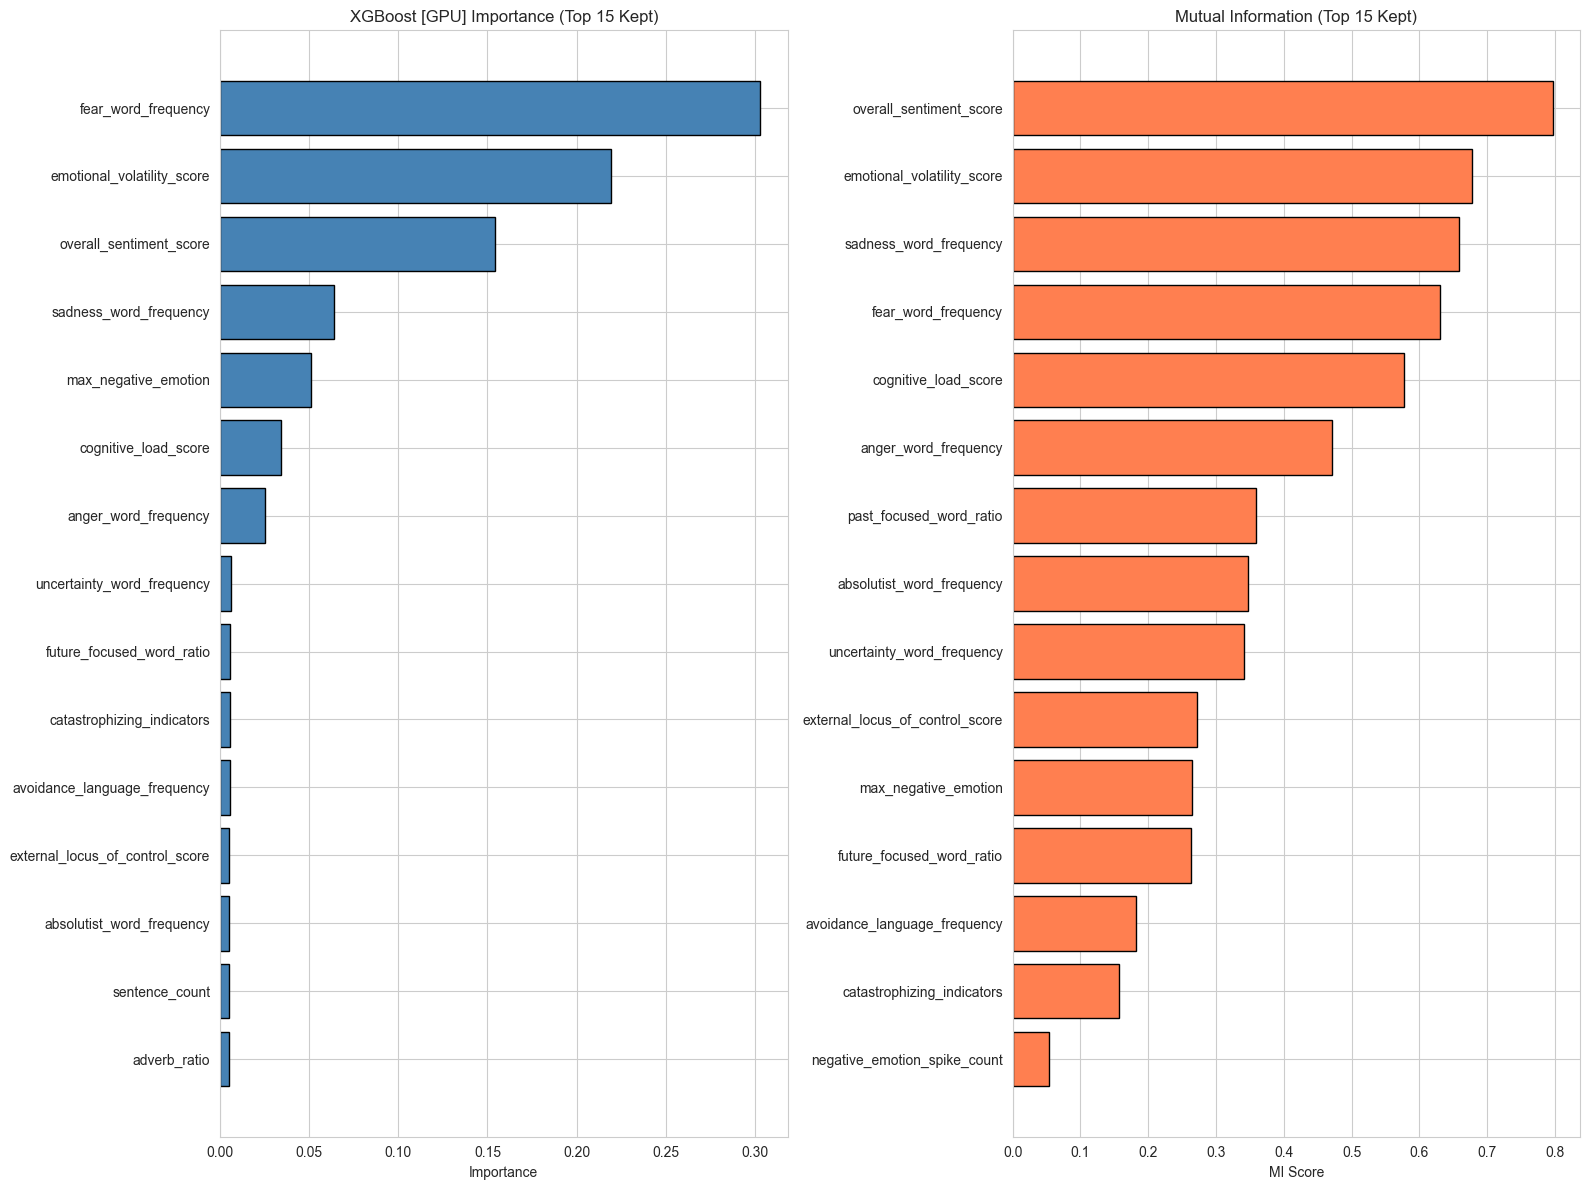


  Final feature count: 28

Step 11 complete.


In [13]:
print('=' * 70)
print('STEP 11: FEATURE SELECTION (MULTI-METHOD CONSENSUS — TRAIN ONLY)')
print('=' * 70)

numeric_cols_fs = X_train_df.select_dtypes(include=[np.number]).columns.tolist()
n_features_start = len(numeric_cols_fs)
print(f'\nStarting with {n_features_start} features.')

# ─── 11.1 Remove Highly Correlated Features ─────────────────────────
print(f'\n--- 11.1 Correlation-Based Filtering ---')
cols_to_remove_corr = set()

if high_corr_pairs:
    for c1, c2, r in high_corr_pairs:
        if c1 not in numeric_cols_fs or c2 not in numeric_cols_fs:
            continue
        # Keep the feature more related to target
        if TASK_TYPE == 'classification':
            score1 = stat_test_results.get(c1, {}).get('H_statistic', 0)
            score2 = stat_test_results.get(c2, {}).get('H_statistic', 0)
        else:
            score1 = abs(stat_test_results.get(c1, {}).get('rho', 0))
            score2 = abs(stat_test_results.get(c2, {}).get('rho', 0))
        remove = c2 if score1 >= score2 else c1
        if remove in numeric_cols_fs:
            cols_to_remove_corr.add(remove)

    if cols_to_remove_corr:
        print(f'  Removing {len(cols_to_remove_corr)} redundant features:')
        for col in sorted(cols_to_remove_corr):
            print(f'    [-] {col}')
        X_train_df = X_train_df.drop(columns=list(cols_to_remove_corr), errors='ignore')
        X_test_df = X_test_df.drop(columns=list(cols_to_remove_corr), errors='ignore')
    else:
        print('  No features removed after correlation analysis.')
else:
    print('  No highly correlated pairs to filter.')

numeric_cols_fs = X_train_df.select_dtypes(include=[np.number]).columns.tolist()

# ─── 11.2 Feature Importance (GPU-accelerated when available) ────────
print(f'\n--- 11.2 Feature Importance (Train Only) ---')
sample_size = min(len(X_train_df), 30000)
idx = np.random.choice(len(X_train_df), sample_size, replace=False)
X_sample = X_train_df.iloc[idx][numeric_cols_fs].values
y_sample = y_train[idx]

# Use XGBoost on GPU if available (much faster), else fall back to RandomForest (CPU, all cores)
if GPU_AVAILABLE:
    print(f'  Using XGBoost [GPU] for feature importance ({sample_size:,} samples)...')
    if TASK_TYPE == 'classification':
        imp_model = xgb.XGBClassifier(
            n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1,
            device='cuda', tree_method='hist', eval_metric='mlogloss',
            verbosity=0)
    else:
        imp_model = xgb.XGBRegressor(
            n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1,
            device='cuda', tree_method='hist', verbosity=0)
else:
    print(f'  Using RandomForest [CPU, {CPU_COUNT} cores] for feature importance ({sample_size:,} samples)...')
    if TASK_TYPE == 'classification':
        imp_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
    else:
        imp_model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)

imp_model.fit(X_sample, y_sample)
rf_importance = dict(zip(numeric_cols_fs, imp_model.feature_importances_))
rf_sorted = sorted(rf_importance.items(), key=lambda x: x[1], reverse=True)

imp_method = 'XGBoost [GPU]' if GPU_AVAILABLE else 'RandomForest [CPU]'
print(f'  Top 15 by {imp_method} Importance:')
for col, imp in rf_sorted[:15]:
    bar = '#' * int(imp * 200)
    print(f'    {col:<35} {imp:.4f} |{bar}')

# Identify top-25% features (protected from VIF removal)
top_25_count = max(1, len(rf_sorted) // 4)
protected_features = set(col for col, _ in rf_sorted[:top_25_count])
print(f'\n  Top-25% features ({top_25_count}) are PROTECTED from VIF removal.')

# ─── 11.3 VIF — Variance Inflation Factor (with protection) ─────────
print(f'\n--- 11.3 VIF (Multicollinearity Detection — Top Features Protected) ---')
print('  VIF > 10 means a feature is highly predictable from other features.')
print('  Top-25% importance features will NOT be removed even if VIF > 10.')
print('  Iteratively removing the worst unprotected offender until all VIF <= 10...\n')

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_removed = []
max_vif_iters = 20  # safety limit

for vif_round in range(max_vif_iters):
    vif_cols = X_train_df[numeric_cols_fs].columns.tolist()
    if len(vif_cols) <= 2:
        break
    # Use a sample for speed on large datasets
    vif_sample = X_train_df[vif_cols].dropna()
    if len(vif_sample) > 10000:
        vif_sample = vif_sample.sample(10000, random_state=RANDOM_SEED)
    vif_data = vif_sample.values.astype(float)

    # Replace any inf/nan to avoid errors
    vif_data = np.nan_to_num(vif_data, nan=0.0, posinf=0.0, neginf=0.0)

    vif_scores = {}
    for i, col in enumerate(vif_cols):
        try:
            vif_scores[col] = variance_inflation_factor(vif_data, i)
        except Exception:
            vif_scores[col] = 0.0

    # Find worst VIF among UNPROTECTED features only
    unprotected_vif = {c: v for c, v in vif_scores.items() if c not in protected_features}
    if not unprotected_vif:
        # All remaining high-VIF features are protected
        still_high = {c: v for c, v in vif_scores.items() if v > 10}
        if still_high:
            print(f'  Remaining high-VIF features are all protected (top-25% importance):')
            for c, v in sorted(still_high.items(), key=lambda x: x[1], reverse=True):
                print(f'    [KEPT] {c} (VIF = {v:.1f}) — protected by importance rank')
        break

    worst_col = max(unprotected_vif, key=unprotected_vif.get)
    worst_vif = unprotected_vif[worst_col]

    if worst_vif <= 10:
        print(f'  All unprotected VIF values <= 10 after {vif_round} round(s). Done.')
        break

    print(f'  Round {vif_round + 1}: Removing {worst_col} (VIF = {worst_vif:.1f})')
    vif_removed.append((worst_col, round(worst_vif, 1)))
    X_train_df = X_train_df.drop(columns=[worst_col], errors='ignore')
    X_test_df = X_test_df.drop(columns=[worst_col], errors='ignore')
    numeric_cols_fs = [c for c in numeric_cols_fs if c != worst_col]
else:
    print(f'  Stopped after {max_vif_iters} rounds (safety limit).')

if vif_removed:
    print(f'\n  VIF Summary: Removed {len(vif_removed)} multicollinear feature(s):')
    for col, vif_val in vif_removed:
        print(f'    [-] {col} (VIF = {vif_val})')
else:
    print(f'  No features removed — all VIF values are acceptable (or protected).')

print(f'  Features remaining: {len(numeric_cols_fs)}')

PIPELINE_STATE['vif_removal'] = {
    'features_removed': vif_removed,
    'features_remaining': len(numeric_cols_fs),
    'protected_features': list(protected_features)
}

# ─── 11.4 Mutual Information ────────────────────────────────────────
print(f'\n--- 11.4 Mutual Information Scores (Train Only) ---')
mi_func = mutual_info_classif if TASK_TYPE == 'classification' else mutual_info_regression
mi_scores = mi_func(X_train_df[numeric_cols_fs].fillna(0).values, y_train,
                     random_state=RANDOM_SEED)
mi_importance = dict(zip(numeric_cols_fs, mi_scores))
mi_sorted = sorted(mi_importance.items(), key=lambda x: x[1], reverse=True)

print(f'  Top 15 by Mutual Information:')
for col, mi in mi_sorted[:15]:
    bar = '#' * int(mi * 50)
    print(f'    {col:<35} {mi:.4f} |{bar}')

# ─── 11.5 Consensus Ranking ─────────────────────────────────────────
print(f'\n--- 11.5 Consensus Feature Ranking ---')
rf_ranks = {feat: rank + 1 for rank, (feat, _) in enumerate(rf_sorted)
            if feat in numeric_cols_fs}
mi_ranks = {feat: rank + 1 for rank, (feat, _) in enumerate(mi_sorted)}

# Statistical test ranking
if TASK_TYPE == 'classification':
    stat_filtered = [(col, stat_test_results[col]['H_statistic'])
                     for col in numeric_cols_fs if col in stat_test_results]
    stat_sorted_fs = sorted(stat_filtered, key=lambda x: x[1], reverse=True)
else:
    stat_filtered = [(col, abs(stat_test_results[col]['rho']))
                     for col in numeric_cols_fs if col in stat_test_results]
    stat_sorted_fs = sorted(stat_filtered, key=lambda x: x[1], reverse=True)

stat_ranks = {feat: rank + 1 for rank, (feat, _) in enumerate(stat_sorted_fs)}

# Levene's ranking (classification only)
levene_ranks = {}
if TASK_TYPE == 'classification' and levene_results:
    lev_filtered = [(col, levene_results[col]['W_statistic'])
                    for col in numeric_cols_fs if col in levene_results]
    lev_sorted_fs = sorted(lev_filtered, key=lambda x: x[1], reverse=True)
    levene_ranks = {feat: rank + 1 for rank, (feat, _) in enumerate(lev_sorted_fs)}
    print(f'  Using 4-method consensus: Importance + MI + Kruskal-Wallis + Levene\'s')
else:
    print(f'  Using 3-method consensus: Importance + MI + Statistical test')

consensus = {}
for feat in numeric_cols_fs:
    ranks = [
        rf_ranks.get(feat, len(numeric_cols_fs)),
        mi_ranks.get(feat, len(numeric_cols_fs)),
        stat_ranks.get(feat, len(numeric_cols_fs))
    ]
    if levene_ranks:
        ranks.append(levene_ranks.get(feat, len(numeric_cols_fs)))
    consensus[feat] = np.mean(ranks)

consensus_sorted = sorted(consensus.items(), key=lambda x: x[1])
n_total = len(consensus_sorted)

print(f'  Consensus Ranking (average of Importance + MI + Stat ranks):')
for rank, (feat, avg_rank) in enumerate(consensus_sorted[:20], 1):
    pct = rank / n_total * 100
    tier = 'T1' if pct <= 15 else 'T2' if pct <= 40 else 'T3' if pct <= 70 else 'T4'
    print(f'    {rank:>3}. [{tier}] {feat:<35} avg_rank: {avg_rank:.1f}')
if n_total > 20:
    print(f'    ... ({n_total - 20} more features)')

# ─── 11.6 Feature Pruning (conservative — MI=0 AND p>0.05 both required) ────
print(f'\n--- 11.6 Feature Pruning (Conservative) ---')
print('  A feature is dropped ONLY if BOTH conditions are true:')
print('    1. Mutual Information = 0  (zero predictive signal)')
print('    2. Kruskal-Wallis p > 0.05 (not statistically significant vs target)')
print('  If EITHER condition is false, the feature is kept.')
print()

features_to_drop = []
features_to_keep = []
prune_details = []

for feat in numeric_cols_fs:
    mi_val  = mi_importance.get(feat, 0)
    p_val   = stat_test_results.get(feat, {}).get('p_value', 1.0)
    mi_zero = mi_val == 0
    not_sig = p_val > 0.05

    if mi_zero and not_sig:
        features_to_drop.append(feat)
        decision = 'DROP'
    else:
        features_to_keep.append(feat)
        decision = 'KEEP'
    prune_details.append((feat, mi_val, p_val, mi_zero, not_sig, decision))

prune_method = 'Conservative: MI=0 AND Kruskal p>0.05 (both required to drop)'

print(f'  {"Feature":<40} {"MI":>8}  {"p-value":>10}  {"Decision"}')
print(f'  {"-"*75}')
for feat, mi_val, p_val, mi_zero, not_sig, decision in prune_details:
    marker = ' <-- DROPPED' if decision == 'DROP' else ''
    print(f'  {feat:<40} {mi_val:>8.4f}  {p_val:>10.4f}  {decision}{marker}')

print()
if features_to_drop:
    print(f'  Dropped {len(features_to_drop)} feature(s) with zero MI AND p > 0.05:')
    for feat in features_to_drop:
        print(f'    [-] {feat}')
    X_train_df = X_train_df[features_to_keep]
    X_test_df  = X_test_df[features_to_keep]
else:
    print(f'  All {n_total} features retained — none had both MI=0 and p>0.05.')
    print(f'  Every feature carries at least some measurable signal.')

# ─── Importance Plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, min(12, n_features_start * 0.3))))
top_rf = [(f, s) for f, s in rf_sorted if f in features_to_keep][:15]
axes[0].barh([x[0] for x in top_rf][::-1], [x[1] for x in top_rf][::-1],
             color='steelblue', edgecolor='black')
axes[0].set_title(f'{imp_method} Importance (Top 15 Kept)')
axes[0].set_xlabel('Importance')

top_mi = [(f, s) for f, s in mi_sorted if f in features_to_keep][:15]
axes[1].barh([x[0] for x in top_mi][::-1], [x[1] for x in top_mi][::-1],
             color='coral', edgecolor='black')
axes[1].set_title('Mutual Information (Top 15 Kept)')
axes[1].set_xlabel('MI Score')
plt.tight_layout()
plt.show()

print(f'\n  Final feature count: {X_train_df.shape[1]}')

PIPELINE_STATE['feature_selection'] = {
    'initial_features': n_features_start,
    'removed_correlation': list(cols_to_remove_corr),
    'consensus_top_20': [(f, round(float(r), 2)) for f, r in consensus_sorted[:20]],
    'features_kept': features_to_keep,
    'features_dropped': features_to_drop,
    'prune_method': prune_method,
    'final_count': int(X_train_df.shape[1]),
    'importance_method': imp_method
}

print(f'\nStep 11 complete.')

## Step 12 — Feature Scaling

**What:** Scales all numeric features to a common range so that features with large absolute values do not dominate the model.

**Scaler selection (automatic):**
- If >30% of columns required outlier smoothing in Step 8 → **RobustScaler** (uses median and IQR — resistant to remaining extreme values)
- Otherwise → **StandardScaler** (zero mean, unit standard deviation — optimal for most algorithms)

**Why fit on train only:** The scaler learns statistics from training data only. Applying those same statistics to the test set ensures consistent scaling without any knowledge of the test distribution being used during training.

**Output:** `X_train_scaled` and `X_test_scaled` as NumPy arrays. `scaler` object saved for inference. `feature_names` list preserving column order. `PIPELINE_STATE['preprocessing']` updated.

**Rules:**
- `scaler.fit_transform(X_train)` — fit and transform training data
- `scaler.transform(X_test)` — transform test data using training statistics only (never `fit_transform` on test)

In [14]:
print('=' * 70)
print('STEP 12: FEATURE SCALING')
print('=' * 70)

# Feature names from post-selection DataFrames
feature_names = X_train_df.columns.tolist()
print(f'\nFeatures entering scaling: {len(feature_names)}')
print(f'  Train samples: {X_train_df.shape[0]:,}')
print(f'  Test  samples: {X_test_df.shape[0]:,}')

# Convert to numpy
X_train = X_train_df.values.astype(np.float64)
X_test = X_test_df.values.astype(np.float64)

# Handle any remaining NaN/Inf
for label, arr in [('Train', X_train), ('Test', X_test)]:
    nan_c = np.isnan(arr).sum()
    inf_c = np.isinf(arr).sum()
    if nan_c > 0 or inf_c > 0:
        print(f'\n  Cleaning {label}: {nan_c} NaN, {inf_c} Inf values → replaced with 0')
        arr[:] = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)

# ─── Scaler Selection ───────────────────────────────────────────────
print(f'\n--- Scaler Selection ---')
n_outlier_cols = len(PIPELINE_STATE.get('outlier_handling', {}).get('transformations', {}))
total_features = len(feature_names)

if n_outlier_cols > total_features * 0.3:
    scaler = RobustScaler()
    scaler_name = 'RobustScaler'
    print(f'  Many columns required outlier smoothing ({n_outlier_cols}/{total_features}).')
    print(f'  Using RobustScaler (median/IQR based) for extra robustness.')
else:
    scaler = StandardScaler()
    scaler_name = 'StandardScaler'
    print(f'  Outlier situation is manageable ({n_outlier_cols}/{total_features} columns treated).')
    print(f'  Using StandardScaler (zero mean, unit variance).')

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\n  Scaling applied with {scaler_name}')
print(f'  Train — mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}')
print(f'  Test  — mean: {X_test_scaled.mean():.6f}, std: {X_test_scaled.std():.6f}')

PIPELINE_STATE['preprocessing'] = {
    'n_features': len(feature_names),
    'feature_names': feature_names,
    'train_size': int(X_train_scaled.shape[0]),
    'test_size': int(X_test_scaled.shape[0]),
    'scaler': scaler_name,
    'class_names': class_names
}
print(f'\nStep 12 complete.')

STEP 12: FEATURE SCALING

Features entering scaling: 28
  Train samples: 12,000
  Test  samples: 3,000

--- Scaler Selection ---
  Many columns required outlier smoothing (39/28).
  Using RobustScaler (median/IQR based) for extra robustness.

  Scaling applied with RobustScaler
  Train — mean: -0.000963, std: 0.696061
  Test  — mean: 0.001288, std: 0.696371

Step 12 complete.


## Step 13 — Model Shortlisting

**What:** Automatically selects which ML models to train based on dataset size, feature count, and GPU availability. Avoids wasting time on models that are slow or inappropriate for the data characteristics.

**Models always included:**
- **Random Forest** — robust ensemble, handles mixed feature scales, provides feature importance
- **LightGBM** — state-of-the-art gradient boosting, very fast, GPU-accelerated when available
- **Extra Trees** — more randomised variant of Random Forest, often complements RF in ensembles
- **HistGradientBoosting** — sklearn's histogram-based gradient boosting; fast CPU-native alternative

**Models included conditionally:**
- **XGBoost** — included if dataset <= 100,000 samples; skipped for very large datasets where LightGBM is preferred
- **Logistic Regression** — included if features < 100 and samples <= 50,000; useful linear baseline
- **SVM (RBF)** — included only for small datasets (features < 50, samples <= 20,000) due to O(n^2) scaling

**Class imbalance handling:** Models that support `class_weight` use `class_weight='balanced'`. XGBoost and LightGBM use `sample_weight` computed from class frequencies.

**Output:** `candidates` OrderedDict of model name to model object. `selection_reasons` dict explaining why each model was included or skipped.

In [15]:
print('=' * 70)
print('STEP 13: MODEL SHORTLISTING')
print('=' * 70)

n_samples = X_train_scaled.shape[0]
n_feats = X_train_scaled.shape[1]

print(f'\nData characteristics:')
print(f'  Training samples : {n_samples:,}')
print(f'  Features         : {n_feats}')
print(f'  Task             : {TASK_TYPE}')
print(f'  CPU cores        : {CPU_COUNT}')
print(f'  GPU acceleration : {"YES (" + GPU_NAME + ")" if GPU_AVAILABLE else "NO (CPU only)"}')
if TASK_TYPE == 'classification':
    print(f'  Classes          : {len(class_names) if class_names else "N/A"}')
    print(f'  Balance strategy : {BALANCE_STRATEGY}')

candidates = OrderedDict()
selection_reasons = {}
use_cw = BALANCE_STRATEGY in ['class_weight', 'class_weight_heavy']

# ─── Compute sample_weight for models that don't support class_weight ────
sample_weight_train = None
if TASK_TYPE == 'classification' and use_cw:
    from sklearn.utils.class_weight import compute_sample_weight
    sample_weight_train = compute_sample_weight('balanced', y_train)
    print(f'\n  Computed sample_weight (balanced) for XGBoost.')
    print(f'  Weight range: [{sample_weight_train.min():.3f}, {sample_weight_train.max():.3f}]')

if TASK_TYPE == 'classification':
    # --- Always include ---
    candidates['Random Forest'] = RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1,
        class_weight='balanced' if use_cw else None)
    selection_reasons['Random Forest'] = 'Always included — robust, handles mixed features'

    lgb_params = {'random_state': RANDOM_SEED, 'n_jobs': -1, 'verbose': -1}
    if use_cw:
        lgb_params['is_unbalance'] = True
    if GPU_AVAILABLE:
        lgb_params['device'] = 'gpu'
    candidates['LightGBM'] = lgb.LGBMClassifier(**lgb_params)
    gpu_tag = ' [GPU]' if GPU_AVAILABLE else ''
    selection_reasons['LightGBM'] = f'Always included — fast, state-of-the-art{gpu_tag}'

    candidates['Extra Trees'] = ExtraTreesClassifier(
        n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1,
        class_weight='balanced' if use_cw else None)
    selection_reasons['Extra Trees'] = 'Always included — more randomized variant of RF'

    # --- Conditional ---
    if n_samples <= 100000:
        xgb_params = {'random_state': RANDOM_SEED, 'n_jobs': -1, 'eval_metric': 'mlogloss'}
        if GPU_AVAILABLE:
            xgb_params['device'] = 'cuda'
            xgb_params['tree_method'] = 'hist'
        candidates['XGBoost'] = xgb.XGBClassifier(**xgb_params)
        reason = f'Included — dataset size ({n_samples:,}) manageable'
        if use_cw:
            reason += ' (sample_weight)'
        if GPU_AVAILABLE:
            reason += ' [GPU]'
        selection_reasons['XGBoost'] = reason
    else:
        selection_reasons['XGBoost [SKIPPED]'] = f'Skipped — too large ({n_samples:,}), prefer LightGBM'
        print(f'  Skipping XGBoost: dataset too large ({n_samples:,}). LightGBM preferred.')

    # HistGradientBoosting replaces GradientBoosting — 10-100x faster, uses all CPU cores
    candidates['HistGradientBoosting'] = HistGradientBoostingClassifier(
        max_iter=200, random_state=RANDOM_SEED,
        class_weight='balanced' if use_cw else None)
    selection_reasons['HistGradientBoosting'] = (
        f'Included — histogram-based GB, native parallel ({CPU_COUNT} cores), '
        f'replaces slow GradientBoosting')

    if n_feats < 100 and n_samples <= 50000:
        candidates['Logistic Regression'] = LogisticRegression(
            random_state=RANDOM_SEED, max_iter=1000, n_jobs=-1,
            class_weight='balanced' if use_cw else None)
        selection_reasons['Logistic Regression'] = (
            f'Included — {n_feats} features, {n_samples:,} samples, linear baseline feasible')

    if n_feats < 50 and n_samples <= 20000:
        candidates['SVM (RBF)'] = SVC(
            random_state=RANDOM_SEED, probability=True,
            class_weight='balanced' if use_cw else None)
        selection_reasons['SVM (RBF)'] = (
            f'Included — {n_feats} features, {n_samples:,} samples, SVM feasible')

    if n_samples <= 50000:
        candidates['KNN'] = KNeighborsClassifier(n_jobs=-1)
        selection_reasons['KNN'] = f'Included — dataset size ({n_samples:,}) manageable for KNN'

else:  # regression
    candidates['Random Forest'] = RandomForestRegressor(
        n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
    selection_reasons['Random Forest'] = 'Always included — robust baseline'

    lgb_params_r = {'random_state': RANDOM_SEED, 'n_jobs': -1, 'verbose': -1}
    if GPU_AVAILABLE:
        lgb_params_r['device'] = 'gpu'
    candidates['LightGBM'] = lgb.LGBMRegressor(**lgb_params_r)
    gpu_tag = ' [GPU]' if GPU_AVAILABLE else ''
    selection_reasons['LightGBM'] = f'Always included — fast, state-of-the-art{gpu_tag}'

    candidates['Extra Trees'] = ExtraTreesRegressor(
        n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
    selection_reasons['Extra Trees'] = 'Always included — randomized variant'

    if n_samples <= 100000:
        xgb_params_r = {'random_state': RANDOM_SEED, 'n_jobs': -1}
        if GPU_AVAILABLE:
            xgb_params_r['device'] = 'cuda'
            xgb_params_r['tree_method'] = 'hist'
        candidates['XGBoost'] = xgb.XGBRegressor(**xgb_params_r)
        reason = f'Included — manageable size ({n_samples:,})'
        if GPU_AVAILABLE:
            reason += ' [GPU]'
        selection_reasons['XGBoost'] = reason

    candidates['HistGradientBoosting'] = HistGradientBoostingRegressor(
        max_iter=200, random_state=RANDOM_SEED)
    selection_reasons['HistGradientBoosting'] = (
        f'Included — histogram-based GB, native parallel ({CPU_COUNT} cores)')

    if n_feats < 100:
        candidates['Ridge'] = Ridge(alpha=1.0)
        selection_reasons['Ridge'] = f'Included — {n_feats} features, linear baseline'

    if n_feats < 50 and n_samples <= 20000:
        candidates['SVR'] = SVR()
        selection_reasons['SVR'] = f'Included — small enough for SVR'

    if n_samples <= 50000:
        candidates['KNN'] = KNeighborsRegressor(n_jobs=-1)
        selection_reasons['KNN'] = f'Included — manageable size ({n_samples:,})'

# ─── Models needing sample_weight (for Step 14) ─────────────────────
# Only XGBoost needs sample_weight — HistGB supports class_weight natively
MODELS_NEEDING_SAMPLE_WEIGHT = set()
if TASK_TYPE == 'classification' and use_cw:
    for name in candidates:
        if 'XGBoost' in name:
            MODELS_NEEDING_SAMPLE_WEIGHT.add(name)

print(f'\nSelected {len(candidates)} candidate models:\n')
for name in candidates:
    reason = selection_reasons.get(name, '')
    sw_tag = ' [sample_weight]' if name in MODELS_NEEDING_SAMPLE_WEIGHT else ''
    print(f'  [+] {name}{sw_tag}')
    print(f'      {reason}\n')

for name, reason in selection_reasons.items():
    if 'SKIPPED' in name:
        print(f'  [-] {name}')
        print(f'      {reason}\n')

PIPELINE_STATE['model_shortlist'] = {
    'n_candidates': len(candidates),
    'models': list(candidates.keys()),
    'reasons': selection_reasons,
    'models_with_sample_weight': list(MODELS_NEEDING_SAMPLE_WEIGHT),
    'gpu_used': GPU_AVAILABLE,
    'cpu_cores': CPU_COUNT
}
print(f'\nStep 13 complete.')

STEP 13: MODEL SHORTLISTING

Data characteristics:
  Training samples : 12,000
  Features         : 28
  Task             : classification
  CPU cores        : 8
  GPU acceleration : YES (NVIDIA GeForce GTX 1650 Ti)
  Classes          : 5
  Balance strategy : none

Selected 8 candidate models:

  [+] Random Forest
      Always included — robust, handles mixed features

  [+] LightGBM
      Always included — fast, state-of-the-art [GPU]

  [+] Extra Trees
      Always included — more randomized variant of RF

  [+] XGBoost
      Included — dataset size (12,000) manageable [GPU]

  [+] HistGradientBoosting
      Included — histogram-based GB, native parallel (8 cores), replaces slow GradientBoosting

  [+] Logistic Regression
      Included — 28 features, 12,000 samples, linear baseline feasible

  [+] SVM (RBF)
      Included — 28 features, 12,000 samples, SVM feasible

  [+] KNN
      Included — dataset size (12,000) manageable for KNN


Step 13 complete.


## Step 14 — Model Training & Cross-Validation Ranking

**What:** Trains every shortlisted model using stratified k-fold cross-validation on the training set and ranks them by macro F1-score.

**Why cross-validation instead of a single train/val split:** A single split can be lucky or unlucky depending on which samples end up in validation. K-fold (5 folds) trains and validates 5 times on different subsets, giving a more stable estimate of how well each model generalises.

**Why macro F1-score:** With 5 mental health classes, accuracy is misleading if any class is easier to predict than others. Macro F1 computes F1 separately for each class and takes the unweighted average — every class matters equally regardless of size.

**Why stratified folds:** Stratification ensures each fold has the same class proportions as the full training set, preventing folds where a minority class has very few or no samples.

**Output:** `ranked` list of models sorted by mean macro F1 (descending). CV scores and standard deviations printed for each model. `PIPELINE_STATE['cv_results']` updated.

STEP 14: MODEL TRAINING & CROSS-VALIDATION

Cross-Validation Setup:
  Folds   : 5
  Scoring  : f1_macro
  Samples  : 12,000
  Features : 28

  Training Random Forest... Done (20.7s) | Score: 0.9441 +/- 0.0027
  Training LightGBM... Done (22.3s) | Score: 0.9454 +/- 0.0034
  Training Extra Trees... Done (3.3s) | Score: 0.9434 +/- 0.0037
  Training XGBoost... Done (8.1s) | Score: 0.9437 +/- 0.0025
  Training HistGradientBoosting... Done (7.9s) | Score: 0.9435 +/- 0.0023
  Training Logistic Regression... Done (1.0s) | Score: 0.9404 +/- 0.0032
  Training SVM (RBF)... Done (11.8s) | Score: 0.9389 +/- 0.0038
  Training KNN... Done (0.5s) | Score: 0.8666 +/- 0.0039

MODEL RANKING (by f1_macro)
Rank   Model                     Score          Std        Time
-----------------------------------------------------------------
>>> 1   LightGBM                  0.9454         0.0034     22.3s
>>> 2   Random Forest             0.9441         0.0027     20.7s
    3   XGBoost                   0.9437   

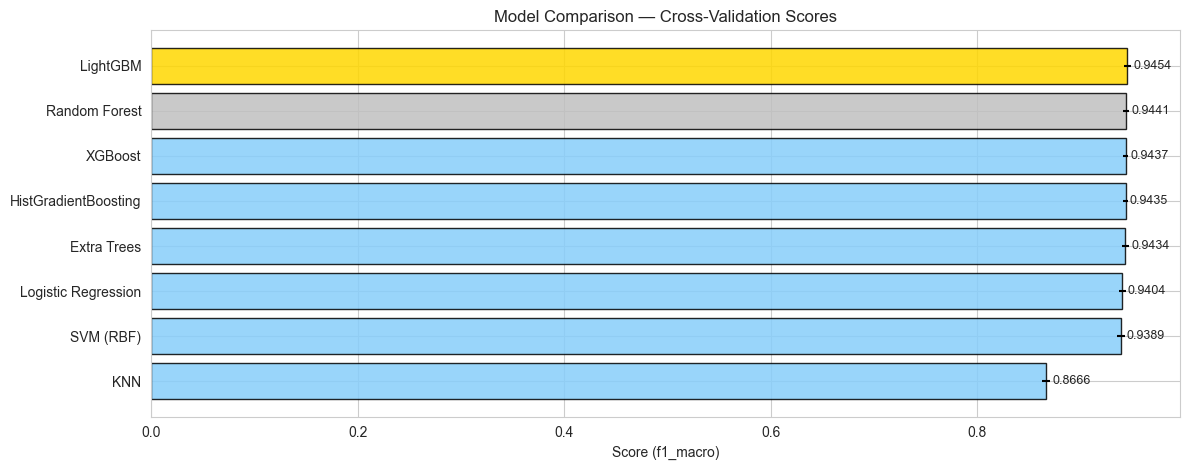


Step 14 complete.


In [16]:
print('=' * 70)
print('STEP 14: MODEL TRAINING & CROSS-VALIDATION')
print('=' * 70)

n_folds = 5
if TASK_TYPE == 'classification':
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_SEED)
    scoring = 'f1_macro'
else:
    cv = KFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_SEED)
    scoring = 'neg_mean_squared_error'

print(f'\nCross-Validation Setup:')
print(f'  Folds   : {n_folds}')
print(f'  Scoring  : {scoring}')
print(f'  Samples  : {X_train_scaled.shape[0]:,}')
print(f'  Features : {X_train_scaled.shape[1]}')
if MODELS_NEEDING_SAMPLE_WEIGHT:
    print(f'  Models using sample_weight in fit(): {sorted(MODELS_NEEDING_SAMPLE_WEIGHT)}')
print()


# ─── Helper: train one fold with sample_weight ──────────────────────
def _train_one_fold(model, X_all, y_all, sw_all, train_idx, val_idx):
    """Train a single fold — designed to be called in parallel via joblib."""
    fold_model = copy.deepcopy(model)
    fold_model.fit(X_all[train_idx], y_all[train_idx],
                   sample_weight=sw_all[train_idx])
    y_pred = fold_model.predict(X_all[val_idx])
    return f1_score(y_all[val_idx], y_pred, average='macro', zero_division=0)


model_results = {}

for name, model in candidates.items():
    print(f'  Training {name}...', end=' ', flush=True)
    start_time = time.time()

    try:
        needs_sw = name in MODELS_NEEDING_SAMPLE_WEIGHT and sample_weight_train is not None

        if needs_sw:
            # Parallel manual CV so we can pass sample_weight to .fit()
            from joblib import Parallel, delayed
            fold_splits = list(cv.split(X_train_scaled, y_train))
            fold_scores = Parallel(n_jobs=-1)(
                delayed(_train_one_fold)(
                    model, X_train_scaled, y_train, sample_weight_train,
                    train_idx, val_idx
                )
                for train_idx, val_idx in fold_splits
            )
            scores = np.array(fold_scores)
        else:
            scores = cross_val_score(model, X_train_scaled, y_train,
                                     cv=cv, scoring=scoring, n_jobs=-1)

        elapsed = time.time() - start_time
        mean_score = float(np.mean(scores))
        std_score = float(np.std(scores))

        model_results[name] = {
            'mean_score': round(mean_score, 4),
            'std_score': round(std_score, 4),
            'scores': [round(float(s), 4) for s in scores],
            'time_seconds': round(elapsed, 2),
            'used_sample_weight': needs_sw
        }
        sw_tag = ' [sw]' if needs_sw else ''
        print(f'Done ({elapsed:.1f}s) | Score: {mean_score:.4f} +/- {std_score:.4f}{sw_tag}')

    except Exception as e:
        elapsed = time.time() - start_time
        print(f'FAILED ({elapsed:.1f}s) | Error: {str(e)[:80]}')
        model_results[name] = {
            'mean_score': -999.0,
            'std_score': 0.0,
            'scores': [],
            'time_seconds': round(elapsed, 2),
            'error': str(e)
        }

# ─── Ranking ─────────────────────────────────────────────────────────
ranked = sorted(
    [(name, res) for name, res in model_results.items() if res['mean_score'] > -999],
    key=lambda x: x[1]['mean_score'], reverse=True
)

print(f'\n{"=" * 70}')
print(f'MODEL RANKING (by {scoring})')
print(f'{"=" * 70}')
print(f'{"Rank":<6} {"Model":<25} {"Score":<14} {"Std":<10} {"Time"}')
print(f'{"-" * 65}')

for rank, (name, res) in enumerate(ranked, 1):
    medal = '>>>' if rank <= 2 else '   '
    sw_tag = ' [sw]' if res.get('used_sample_weight') else ''
    print(f'{medal} {rank:<3} {name:<25} {res["mean_score"]:<14.4f} '
          f'{res["std_score"]:<10.4f} {res["time_seconds"]:.1f}s{sw_tag}')

# ─── Plot ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, max(4, len(ranked) * 0.6)))
names_r = [n for n, _ in ranked][::-1]
scores_r = [r['mean_score'] for _, r in ranked][::-1]
stds_r = [r['std_score'] for _, r in ranked][::-1]
colors = ['gold' if i == len(ranked)-1 else 'silver' if i == len(ranked)-2
          else 'lightskyblue' for i in range(len(ranked))]

ax.barh(names_r, scores_r, xerr=stds_r, color=colors, edgecolor='black', alpha=0.85)
ax.set_xlabel(f'Score ({scoring})')
ax.set_title('Model Comparison — Cross-Validation Scores')
for i, (score, std) in enumerate(zip(scores_r, stds_r)):
    ax.text(score + std + 0.002, i, f'{score:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

PIPELINE_STATE['model_training'] = {
    'cv_folds': n_folds,
    'scoring': scoring,
    'results': model_results,
    'ranking': [name for name, _ in ranked]
}
print(f'\nStep 14 complete.')

## Step 15 — Top-K Model Selection

**What:** Selects the top 2 models from the cross-validation ranking for hyperparameter tuning in Step 16.

**Why top 2 and not just top 1:** The best cross-validation model is not always the best after tuning — sometimes the second-ranked model has more room to improve with better hyperparameters. Tuning both and selecting the winner at the end gives a more reliable final result.

**Why not tune all models:** Hyperparameter tuning is computationally expensive. Tuning all 5–7 candidates would take too long with diminishing returns. The top 2 by CV score is a good cost-to-quality tradeoff.

**Output:** `top_models` list with the top 2 (name, model, CV score) tuples ready for Optuna tuning.

In [17]:
print('=' * 70)
print('STEP 15: TOP-K MODEL SELECTION')
print('=' * 70)

TOP_K = min(2, len(ranked))
top_models = ranked[:TOP_K]

print(f'\nSelecting top {TOP_K} models for hyperparameter tuning:\n')
for rank, (name, res) in enumerate(top_models, 1):
    print(f'  #{rank} {name}')
    print(f'     CV Score     : {res["mean_score"]:.4f} +/- {res["std_score"]:.4f}')
    print(f'     Training time: {res["time_seconds"]:.1f}s')
    print()

if TOP_K >= 2:
    best_name, best_res = top_models[0]
    second_name, second_res = top_models[1]
    score_diff = abs(best_res['mean_score'] - second_res['mean_score'])

    if score_diff < 0.005:
        print(f'  Analysis: {best_name} and {second_name} are very close '
              f'(diff: {score_diff:.4f}).')
        print(f'  Tuning both is critical — the winner could change after optimization.')
    elif score_diff < 0.02:
        print(f'  Analysis: {best_name} leads by {score_diff:.4f}.')
        print(f'  {second_name} could close the gap with good hyperparameters.')
    else:
        print(f'  Analysis: {best_name} has a clear lead ({score_diff:.4f}).')
        print(f'  Still tuning both for robustness, but {best_name} is the likely winner.')

PIPELINE_STATE['top_k_selection'] = {
    'top_k': TOP_K,
    'selected': [name for name, _ in top_models]
}
print(f'\nStep 15 complete.')

STEP 15: TOP-K MODEL SELECTION

Selecting top 2 models for hyperparameter tuning:

  #1 LightGBM
     CV Score     : 0.9454 +/- 0.0034
     Training time: 22.3s

  #2 Random Forest
     CV Score     : 0.9441 +/- 0.0027
     Training time: 20.7s

  Analysis: LightGBM and Random Forest are very close (diff: 0.0013).
  Tuning both is critical — the winner could change after optimization.

Step 15 complete.


## Step 16 — Hyperparameter Tuning (Optuna — Bayesian Search)

**What:** Uses Optuna's Tree-structured Parzen Estimator (TPE) to search for the best hyperparameters for each of the top 2 models. Evaluates using stratified 3-fold cross-validation on the training set.

**Why Bayesian search instead of Grid Search:**
- **Grid Search** tries every combination in a predefined grid — wasteful when most combinations are poor
- **Random Search** samples randomly — better, but treats each trial independently with no learning
- **Bayesian search (TPE)** builds a probabilistic model of which hyperparameter regions produced good results and focuses sampling there — finds better configurations in fewer trials

**Speed settings:**
- 40 Optuna trials per model (fast mode)
- 3-fold CV per trial (reduced from 5 to save time during tuning)
- GPU used for XGBoost/LightGBM when available

**Output:** `tuning_results` dict with best params and best score for each model. `PIPELINE_STATE['tuning']` updated.

**Rules:**
- Tuning is always done on the **training set only** — the test set is never touched during this step
- Increase `n_trials` to 100 for better results at the cost of longer runtime

In [18]:
print('=' * 70)
print('STEP 16: HYPERPARAMETER TUNING (OPTUNA)')
print('=' * 70)

# ─── Tuning Settings ────────────────────────────────────────────────
N_TRIALS = 15                # Keep low for speed (15 trials ≈ 2-3 min per model)
TUNING_TIMEOUT = 180         # Hard timeout per model in seconds (3 min each)
TUNING_CV_FOLDS = 5          # Consistent with training CV

print(f'  Trials per model : {N_TRIALS}')
print(f'  Timeout per model: {TUNING_TIMEOUT}s ({TUNING_TIMEOUT // 60} min)')
print(f'  CV folds (tuning): {TUNING_CV_FOLDS}')
print(f'  Scoring          : {scoring}')
print(f'  CPU cores        : {CPU_COUNT}')
print(f'  GPU acceleration : {"YES" if GPU_AVAILABLE else "NO"}')
print(f'  Estimated total  : ~{len(top_models) * (TUNING_TIMEOUT // 60)} min max\n')

tuning_cv = StratifiedKFold(n_splits=TUNING_CV_FOLDS, shuffle=True,
                            random_state=RANDOM_SEED) if TASK_TYPE == 'classification' \
            else KFold(n_splits=TUNING_CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)


def get_optuna_model(trial, model_name, task_type, use_cw=False):
    """Build a model with Optuna-suggested hyperparameters.
    Automatically uses GPU if available (XGBoost/LightGBM) and all CPU cores."""

    if 'LightGBM' in model_name:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 10, 100),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'random_state': RANDOM_SEED, 'n_jobs': -1, 'verbose': -1,
        }
        if task_type == 'classification' and use_cw:
            params['is_unbalance'] = True
        if GPU_AVAILABLE:
            params['device'] = 'gpu'
        cls = lgb.LGBMClassifier if task_type == 'classification' else lgb.LGBMRegressor
        return cls(**params)

    elif 'XGBoost' in model_name:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
            'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'random_state': RANDOM_SEED, 'n_jobs': -1,
        }
        if task_type == 'classification':
            params['eval_metric'] = 'mlogloss'
        if GPU_AVAILABLE:
            params['device'] = 'cuda'
            params['tree_method'] = 'hist'
        cls = xgb.XGBClassifier if task_type == 'classification' else xgb.XGBRegressor
        return cls(**params)

    elif 'Random Forest' in model_name:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'random_state': RANDOM_SEED, 'n_jobs': -1,
        }
        if task_type == 'classification' and use_cw:
            params['class_weight'] = 'balanced'
        cls = RandomForestClassifier if task_type == 'classification' else RandomForestRegressor
        return cls(**params)

    elif 'Extra Trees' in model_name:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'random_state': RANDOM_SEED, 'n_jobs': -1,
        }
        if task_type == 'classification' and use_cw:
            params['class_weight'] = 'balanced'
        cls = ExtraTreesClassifier if task_type == 'classification' else ExtraTreesRegressor
        return cls(**params)

    elif 'HistGradientBoosting' in model_name:
        params = {
            'max_iter': trial.suggest_int('max_iter', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 127),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50),
            'l2_regularization': trial.suggest_float('l2_regularization', 1e-8, 10.0, log=True),
            'random_state': RANDOM_SEED,
        }
        if task_type == 'classification':
            if use_cw:
                params['class_weight'] = 'balanced'
            return HistGradientBoostingClassifier(**params)
        else:
            return HistGradientBoostingRegressor(**params)

    elif 'Logistic Regression' in model_name:
        params = {
            'C': trial.suggest_float('C', 1e-4, 100.0, log=True),
            'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
            'solver': 'saga', 'max_iter': 2000,
            'random_state': RANDOM_SEED, 'n_jobs': -1,
        }
        if task_type == 'classification' and use_cw:
            params['class_weight'] = 'balanced'
        return LogisticRegression(**params)

    elif 'SVM' in model_name and task_type == 'classification':
        params = {
            'C': trial.suggest_float('C', 1e-3, 100.0, log=True),
            'kernel': trial.suggest_categorical('kernel', ['rbf', 'poly']),
            'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
            'probability': True, 'random_state': RANDOM_SEED,
        }
        if use_cw:
            params['class_weight'] = 'balanced'
        return SVC(**params)

    elif 'SVR' in model_name:
        params = {
            'C': trial.suggest_float('C', 1e-3, 100.0, log=True),
            'kernel': trial.suggest_categorical('kernel', ['rbf', 'poly']),
            'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
        }
        return SVR(**params)

    elif 'KNN' in model_name:
        params = {
            'n_neighbors': trial.suggest_int('n_neighbors', 3, 50),
            'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
            'metric': trial.suggest_categorical('metric', ['euclidean', 'manhattan']),
            'n_jobs': -1,
        }
        cls = KNeighborsClassifier if task_type == 'classification' else KNeighborsRegressor
        return cls(**params)

    elif 'Ridge' in model_name:
        return Ridge(alpha=trial.suggest_float('alpha', 1e-4, 100.0, log=True))

    elif 'Lasso' in model_name:
        return Lasso(alpha=trial.suggest_float('alpha', 1e-4, 100.0, log=True),
                     max_iter=2000)

    else:
        # Fallback: Decision Tree
        params = {
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'random_state': RANDOM_SEED,
        }
        cls = DecisionTreeClassifier if task_type == 'classification' else DecisionTreeRegressor
        return cls(**params)


# ─── Run Optuna for each top model ──────────────────────────────────
tuning_results = {}
tuning_start = time.time()

for model_name, model_res in top_models:
    print(f'\n{"=" * 50}')
    needs_sw = model_name in MODELS_NEEDING_SAMPLE_WEIGHT and sample_weight_train is not None
    sw_note = ' [with sample_weight]' if needs_sw else ''
    gpu_note = ''
    if GPU_AVAILABLE and ('XGBoost' in model_name or 'LightGBM' in model_name):
        gpu_note = ' [GPU]'
    print(f'Tuning: {model_name} ({N_TRIALS} trials, {TUNING_TIMEOUT}s timeout){sw_note}{gpu_note}')
    print(f'{"=" * 50}')

    model_start = time.time()

    def objective(trial, _name=model_name, _needs_sw=needs_sw):
        model = get_optuna_model(trial, _name, TASK_TYPE, use_cw)

        if _needs_sw:
            # Manual CV loop for sample_weight
            fold_scores = []
            for train_idx, val_idx in tuning_cv.split(X_train_scaled, y_train):
                X_f_tr, X_f_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
                y_f_tr, y_f_val = y_train[train_idx], y_train[val_idx]
                sw_fold = sample_weight_train[train_idx]
                model_copy = copy.deepcopy(model)
                model_copy.fit(X_f_tr, y_f_tr, sample_weight=sw_fold)
                y_f_pred = model_copy.predict(X_f_val)
                fold_scores.append(f1_score(y_f_val, y_f_pred, average='macro', zero_division=0))
            return np.mean(fold_scores)
        else:
            scores = cross_val_score(model, X_train_scaled, y_train,
                                     cv=tuning_cv, scoring=scoring, n_jobs=-1)
            return np.mean(scores)

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
    )
    study.optimize(objective, n_trials=N_TRIALS, timeout=TUNING_TIMEOUT,
                   show_progress_bar=True)

    model_elapsed = time.time() - model_start
    best_score = study.best_value
    best_params = study.best_params
    n_completed = len(study.trials)
    stopped_by = 'timeout' if n_completed < N_TRIALS else 'all trials completed'

    print(f'\n  Completed {n_completed}/{N_TRIALS} trials in {model_elapsed:.1f}s ({stopped_by})')
    print(f'  Best CV score: {best_score:.4f}')
    print(f'  Best parameters:')
    for param, value in best_params.items():
        print(f'    {param}: {value}')

    improvement = best_score - model_res['mean_score']
    direction = 'UP' if improvement > 0 else 'DOWN' if improvement < 0 else 'SAME'
    print(f'\n  Improvement over default: {improvement:+.4f} ({direction})')

    tuning_results[model_name] = {
        'best_score': round(float(best_score), 4),
        'best_params': best_params,
        'default_score': model_res['mean_score'],
        'improvement': round(float(improvement), 4),
        'n_trials_completed': n_completed,
        'time_seconds': round(model_elapsed, 1),
        'used_sample_weight': needs_sw
    }

total_tuning_time = time.time() - tuning_start

# ─── Comparison ──────────────────────────────────────────────────────
print(f'\n{"=" * 70}')
print(f'TUNING RESULTS COMPARISON')
print(f'{"=" * 70}')
print(f'{"Model":<25} {"Default":<12} {"Tuned":<12} {"Change":<12} {"Time"}')
print(f'{"-" * 70}')

best_tuned_name = None
best_tuned_score = -999

for name, res in tuning_results.items():
    marker = 'UP' if res['improvement'] > 0 else 'DOWN' if res['improvement'] < 0 else '=='
    print(f'{name:<25} {res["default_score"]:<12.4f} {res["best_score"]:<12.4f} '
          f'{res["improvement"]:+.4f}  [{marker}]  {res["time_seconds"]:.0f}s')
    if res['best_score'] > best_tuned_score:
        best_tuned_score = res['best_score']
        best_tuned_name = name

print(f'\n  >>> Best model after tuning: {best_tuned_name} (score: {best_tuned_score:.4f})')
print(f'  >>> Total tuning time: {total_tuning_time:.1f}s ({total_tuning_time/60:.1f} min)')

PIPELINE_STATE['hyperparameter_tuning'] = tuning_results
print(f'\nStep 16 complete.')

STEP 16: HYPERPARAMETER TUNING (OPTUNA)
  Trials per model : 15
  Timeout per model: 180s (3 min)
  CV folds (tuning): 5
  Scoring          : f1_macro
  CPU cores        : 8
  GPU acceleration : YES
  Estimated total  : ~6 min max


Tuning: LightGBM (15 trials, 180s timeout) [GPU]


Best trial: 6. Best value: 0.946247:  60%|██████    | 9/15 [03:04<02:03, 20.55s/it, 184.93/180 seconds]



  Completed 9/15 trials in 185.0s (timeout)
  Best CV score: 0.9462
  Best parameters:
    n_estimators: 339
    max_depth: 14
    learning_rate: 0.01351182947645082
    num_leaves: 27
    subsample: 0.522613644455269
    colsample_bytree: 0.6626651653816322
    min_child_samples: 22
    reg_alpha: 2.7678419414850017e-06
    reg_lambda: 0.28749982347407854

  Improvement over default: +0.0008 (UP)

Tuning: Random Forest (15 trials, 180s timeout)


Best trial: 1. Best value: 0.943214:  60%|██████    | 9/15 [03:09<02:06, 21.09s/it, 189.76/180 seconds]


  Completed 9/15 trials in 189.8s (timeout)
  Best CV score: 0.9432
  Best parameters:
    n_estimators: 447
    max_depth: 19
    min_samples_split: 15
    min_samples_leaf: 1
    max_features: sqrt

  Improvement over default: -0.0009 (DOWN)

TUNING RESULTS COMPARISON
Model                     Default      Tuned        Change       Time
----------------------------------------------------------------------
LightGBM                  0.9454       0.9462       +0.0008  [UP]  185s
Random Forest             0.9441       0.9432       -0.0009  [DOWN]  190s

  >>> Best model after tuning: LightGBM (score: 0.9462)
  >>> Total tuning time: 374.8s (6.2 min)

Step 16 complete.


## Step 17 — Final Evaluation on Test Set

**What:** Takes the best tuned model, trains it on the full training set, and evaluates it once on the held-out test set. This is the only time the test set is used for evaluation.

**Why train on full training set:** During cross-validation and tuning, the model only ever saw 80% of the training data at a time. Now that hyperparameters are fixed, we train on all training data to give the model maximum information before final evaluation.

**Why evaluate on test set only once:** If you evaluate on the test set multiple times and adjust the model based on results, the test set effectively becomes part of the training process — your reported accuracy will be optimistic. The test set is a simulation of unseen production data and must only be used for the final honest evaluation.

**Metrics reported:**
- Overall accuracy
- Macro F1-score (primary metric — equal weight to all 5 classes)
- Per-class precision, recall, F1
- Confusion matrix (shows which classes are confused with which)

**Output:** `best_model_final` trained on full training set. Classification report and confusion matrix displayed and saved. `PIPELINE_STATE['final_evaluation']` updated.

STEP 17: FINAL EVALUATION ON TEST SET

Best model: LightGBM
Parameters: {'n_estimators': 339, 'max_depth': 14, 'learning_rate': 0.01351182947645082, 'num_leaves': 27, 'subsample': 0.522613644455269, 'colsample_bytree': 0.6626651653816322, 'min_child_samples': 22, 'reg_alpha': 2.7678419414850017e-06, 'reg_lambda': 0.28749982347407854}

Training on full training set (12,000 samples)...
Done!

--- Test Set Performance ---
  Accuracy       : 0.9470
  F1 (macro)     : 0.9468   ← primary metric
  F1 (weighted)  : 0.9468
  Precision (m)  : 0.9468
  Recall (m)     : 0.9470
  Precision (wt) : 0.9468
  Recall (wt)    : 0.9470

--- Full Classification Report ---
                   precision    recall  f1-score   support

          ANXIETY       0.90      0.87      0.88       600
          BIPOLAR       0.98      0.98      0.98       600
       DEPRESSION       0.98      0.99      0.99       600
           PHOBIA       0.89      0.91      0.90       600
SUICIDAL_TENDENCY       0.98      0.99      

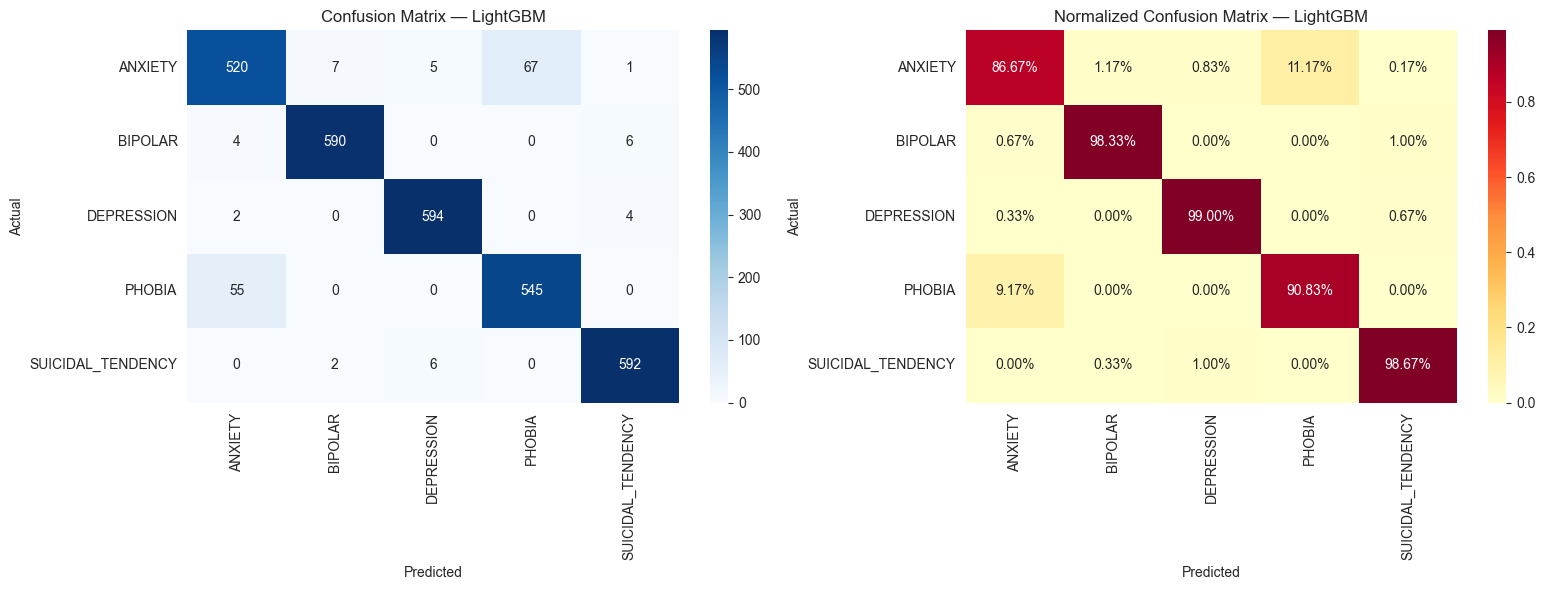


--- Runner-up evaluation: Random Forest ---
  Accuracy: 0.9413 | F1 macro: 0.9412 | F1 weighted: 0.9412

Step 17 complete.


In [19]:
print('=' * 70)
print('STEP 17: FINAL EVALUATION ON TEST SET')
print('=' * 70)

# ─── Helper: Reconstruct model from best params ─────────────────────
class _FixedTrial:
    """Mimics an Optuna trial but returns fixed parameter values."""
    def __init__(self, params):
        self._p = params
    def suggest_int(self, name, *a, **kw):
        return self._p[name]
    def suggest_float(self, name, *a, **kw):
        return self._p[name]
    def suggest_categorical(self, name, *a, **kw):
        return self._p[name]

# ─── Build & train best model ───────────────────────────────────────
print(f'\nBest model: {best_tuned_name}')
print(f'Parameters: {tuning_results[best_tuned_name]["best_params"]}')

fixed_trial = _FixedTrial(tuning_results[best_tuned_name]['best_params'])
final_model = get_optuna_model(fixed_trial, best_tuned_name, TASK_TYPE, use_cw)

needs_sw_final = best_tuned_name in MODELS_NEEDING_SAMPLE_WEIGHT and sample_weight_train is not None

print(f'\nTraining on full training set ({X_train_scaled.shape[0]:,} samples)...')
if needs_sw_final:
    final_model.fit(X_train_scaled, y_train, sample_weight=sample_weight_train)
    print('Done! (with sample_weight)')
else:
    final_model.fit(X_train_scaled, y_train)
    print('Done!')

y_pred = final_model.predict(X_test_scaled)

if TASK_TYPE == 'classification':
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_wt = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    prec_wt = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec_wt = recall_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f'\n--- Test Set Performance ---')
    print(f'  Accuracy       : {acc:.4f}')
    print(f'  F1 (macro)     : {f1_macro:.4f}   ← primary metric')
    print(f'  F1 (weighted)  : {f1_wt:.4f}')
    print(f'  Precision (m)  : {prec_macro:.4f}')
    print(f'  Recall (m)     : {rec_macro:.4f}')
    print(f'  Precision (wt) : {prec_wt:.4f}')
    print(f'  Recall (wt)    : {rec_wt:.4f}')

    target_names = class_names if class_names else [str(i) for i in sorted(set(y_test))]
    print(f'\n--- Full Classification Report ---')
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

    # Confusion matrices
    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names, ax=axes[0])
    axes[0].set_title(f'Confusion Matrix — {best_tuned_name}')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='YlOrRd',
                xticklabels=target_names, yticklabels=target_names, ax=axes[1])
    axes[1].set_title(f'Normalized Confusion Matrix — {best_tuned_name}')
    axes[1].set_ylabel('Actual')
    axes[1].set_xlabel('Predicted')

    plt.tight_layout()
    plt.show()

    final_metrics = {
        'accuracy': round(float(acc), 4),
        'f1_macro': round(float(f1_macro), 4),
        'f1_weighted': round(float(f1_wt), 4),
        'precision_macro': round(float(prec_macro), 4),
        'recall_macro': round(float(rec_macro), 4),
        'precision_weighted': round(float(prec_wt), 4),
        'recall_weighted': round(float(rec_wt), 4)
    }

else:  # regression
    mse_val = mean_squared_error(y_test, y_pred)
    rmse_val = np.sqrt(mse_val)
    mae_val = mean_absolute_error(y_test, y_pred)
    r2_val = r2_score(y_test, y_pred)

    print(f'\n--- Test Set Performance ---')
    print(f'  MSE  : {mse_val:.4f}')
    print(f'  RMSE : {rmse_val:.4f}')
    print(f'  MAE  : {mae_val:.4f}')
    print(f'  R2   : {r2_val:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(y_test, y_pred, alpha=0.3, s=10)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    axes[0].set_xlabel('Actual')
    axes[0].set_ylabel('Predicted')
    axes[0].set_title(f'Actual vs Predicted — {best_tuned_name}')

    residuals = y_test - y_pred
    axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[1].axvline(x=0, color='red', linestyle='--')
    axes[1].set_xlabel('Residual')
    axes[1].set_title('Residual Distribution')

    plt.tight_layout()
    plt.show()

    final_metrics = {
        'mse': round(float(mse_val), 4),
        'rmse': round(float(rmse_val), 4),
        'mae': round(float(mae_val), 4),
        'r2': round(float(r2_val), 4)
    }

# ─── Also evaluate runner-up (if exists) ────────────────────────────
runner_up_names = [name for name, _ in top_models if name != best_tuned_name]
if runner_up_names:
    ru_name = runner_up_names[0]
    print(f'\n--- Runner-up evaluation: {ru_name} ---')
    fixed_trial_ru = _FixedTrial(tuning_results[ru_name]['best_params'])
    ru_model = get_optuna_model(fixed_trial_ru, ru_name, TASK_TYPE, use_cw)

    needs_sw_ru = ru_name in MODELS_NEEDING_SAMPLE_WEIGHT and sample_weight_train is not None
    if needs_sw_ru:
        ru_model.fit(X_train_scaled, y_train, sample_weight=sample_weight_train)
    else:
        ru_model.fit(X_train_scaled, y_train)

    y_pred_ru = ru_model.predict(X_test_scaled)

    if TASK_TYPE == 'classification':
        acc_ru = accuracy_score(y_test, y_pred_ru)
        f1m_ru = f1_score(y_test, y_pred_ru, average='macro', zero_division=0)
        f1w_ru = f1_score(y_test, y_pred_ru, average='weighted', zero_division=0)
        print(f'  Accuracy: {acc_ru:.4f} | F1 macro: {f1m_ru:.4f} | F1 weighted: {f1w_ru:.4f}')
    else:
        rmse_ru = np.sqrt(mean_squared_error(y_test, y_pred_ru))
        r2_ru = r2_score(y_test, y_pred_ru)
        print(f'  RMSE: {rmse_ru:.4f} | R2: {r2_ru:.4f}')

PIPELINE_STATE['final_evaluation'] = {
    'best_model': best_tuned_name,
    'metrics': final_metrics
}
print(f'\nStep 17 complete.')

## Step 18 — Save All Artifacts

**What:** Saves every object needed to reproduce training results or run inference on new data to a uniquely timestamped output folder.

**Artifacts saved:**
- `model.joblib` — the final trained model
- `scaler.joblib` — the fitted scaler (apply to new data before prediction)
- `label_encoder.joblib` — maps integer predictions back to class name strings
- `outlier_transformers.joblib` — per-column outlier smoothing objects (apply in same order as training)
- `encoding_artifacts.joblib` — categorical encoding mappings
- `pipeline_state.json` — full record of every pipeline decision, metric, and configuration
- `feature_names.json` — ordered list of features the model expects at inference time

**Why a timestamped folder:** Each run produces a new folder (`{model_name}_{ddmmyyyy}_{hhmmss}`), so previous runs are never overwritten. Compare multiple runs by looking at their `pipeline_state.json` files.

**How to use saved artifacts for inference:**
```python
import joblib, json
model    = joblib.load('output_folder/model.joblib')
scaler   = joblib.load('output_folder/scaler.joblib')
le       = joblib.load('output_folder/label_encoder.joblib')
features = json.load(open('output_folder/feature_names.json'))
# Apply same preprocessing to new_df, then:
X_new = scaler.transform(new_df[features])
pred  = le.inverse_transform(model.predict(X_new))
```

In [20]:
print('=' * 70)
print('STEP 18: SAVE ARTIFACTS')
print('=' * 70)

# ─── Dynamic folder: {model_name}_{ddmmyyyy}_{hhmmss} ───────────────
now = datetime.now()
model_name_clean = best_tuned_name.replace(' ', '_').replace('(', '').replace(')', '')
folder_name = f'{model_name_clean}_{now.strftime("%d-%b-%Y")}_{now.strftime("%H-%M-%S")}'
run_dir = os.path.join(OUTPUT_DIR, folder_name)
os.makedirs(run_dir, exist_ok=True)

print(f'\n  Output folder: {run_dir}/')

# ─── Helper: make JSON-serializable ─────────────────────────────────
def _make_serializable(obj):
    if isinstance(obj, dict):
        return {k: _make_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_make_serializable(v) for v in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.bool_):
        return bool(obj)
    return obj

# ─── Save model ─────────────────────────────────────────────────────
model_path = os.path.join(run_dir, 'best_model.joblib')
joblib.dump(final_model, model_path)
print(f'  Model saved        : {model_path}')

# ─── Save scaler ────────────────────────────────────────────────────
scaler_path = os.path.join(run_dir, 'scaler.joblib')
joblib.dump(scaler, scaler_path)
print(f'  Scaler saved       : {scaler_path}')

# ─── Save label encoder (classification only) ───────────────────────
if TASK_TYPE == 'classification' and le is not None:
    le_path = os.path.join(run_dir, 'label_encoder.joblib')
    joblib.dump(le, le_path)
    print(f'  Label encoder saved: {le_path}')

# ─── Save outlier transformers (for inference reproducibility) ───────
if 'outlier_transformers' in dir():
    ot_path = os.path.join(run_dir, 'outlier_transformers.joblib')
    joblib.dump(outlier_transformers, ot_path)
    print(f'  Outlier transforms : {ot_path}')

# ─── Save encoding artifacts (for inference reproducibility) ─────────
if 'encoding_artifacts' in dir():
    ea_path = os.path.join(run_dir, 'encoding_artifacts.joblib')
    joblib.dump(encoding_artifacts, ea_path)
    print(f'  Encoding artifacts : {ea_path}')

# ─── Save feature names (column order for inference) ─────────────────
feat_path = os.path.join(run_dir, 'feature_names.json')
with open(feat_path, 'w', encoding='utf-8') as f:
    json.dump(feature_names, f, indent=2)
print(f'  Feature names      : {feat_path}')

# ─── Save pipeline state JSON ───────────────────────────────────────
state_path = os.path.join(run_dir, 'pipeline_state.json')
with open(state_path, 'w', encoding='utf-8') as f:
    json.dump(_make_serializable(PIPELINE_STATE), f, indent=2, default=str)
print(f'  Pipeline state     : {state_path}')

# ─── Save model metadata ────────────────────────────────────────────
metadata = {
    'best_model_name': best_tuned_name,
    'best_params': tuning_results[best_tuned_name]['best_params'],
    'cv_score': tuning_results[best_tuned_name]['best_score'],
    'cv_scoring': scoring,
    'test_metrics': final_metrics,
    'task_type': TASK_TYPE,
    'n_features': len(feature_names),
    'feature_names': feature_names,
    'class_names': class_names,
    'scaler': scaler_name,
    'n_training_samples': int(X_train_scaled.shape[0]),
    'n_test_samples': int(X_test_scaled.shape[0]),
    'random_seed': RANDOM_SEED,
    'balance_strategy': BALANCE_STRATEGY,
    'used_sample_weight': best_tuned_name in MODELS_NEEDING_SAMPLE_WEIGHT,
    'saved_at': now.strftime('%d-%m-%Y %H:%M:%S')
}
metadata_path = os.path.join(run_dir, 'model_metadata.json')
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(_make_serializable(metadata), f, indent=2, default=str)
print(f'  Model metadata     : {metadata_path}')

# ─── Final Summary ──────────────────────────────────────────────────
print(f'\n{"=" * 70}')
print(f'PIPELINE COMPLETE')
print(f'{"=" * 70}')
data_info = PIPELINE_STATE.get('data_loading', {})
print(f'\n  Data       : {FILE_PATH} ({data_info.get("rows", "?"):,} rows)')
print(f'  Task       : {TASK_TYPE}')
print(f'  Features   : {len(feature_names)}')
print(f'  Best model : {best_tuned_name}')
print(f'  Scoring    : {scoring}')
print(f'  Metrics    : {final_metrics}')
print(f'\n  Artifacts saved to: {run_dir}/')
print(f'    best_model.joblib')
print(f'    scaler.joblib')
if TASK_TYPE == 'classification':
    print(f'    label_encoder.joblib')
print(f'    outlier_transformers.joblib')
print(f'    encoding_artifacts.joblib')
print(f'    feature_names.json')
print(f'    pipeline_state.json')
print(f'    model_metadata.json')
print(f'\n  Pipeline finished successfully!')

STEP 18: SAVE ARTIFACTS

  Output folder: text_ml_pipeline_output\LightGBM_06052026_180407/
  Model saved        : text_ml_pipeline_output\LightGBM_06052026_180407\best_model.joblib
  Scaler saved       : text_ml_pipeline_output\LightGBM_06052026_180407\scaler.joblib
  Label encoder saved: text_ml_pipeline_output\LightGBM_06052026_180407\label_encoder.joblib
  Outlier transforms : text_ml_pipeline_output\LightGBM_06052026_180407\outlier_transformers.joblib
  Encoding artifacts : text_ml_pipeline_output\LightGBM_06052026_180407\encoding_artifacts.joblib
  Feature names      : text_ml_pipeline_output\LightGBM_06052026_180407\feature_names.json
  Pipeline state     : text_ml_pipeline_output\LightGBM_06052026_180407\pipeline_state.json
  Model metadata     : text_ml_pipeline_output\LightGBM_06052026_180407\model_metadata.json

PIPELINE COMPLETE

  Data       : data/text_parameters_for_ml.csv (15,000 rows)
  Task       : classification
  Features   : 28
  Best model : LightGBM
  Scoring    

## Step 19 — Model Explainability (SHAP)

**What:** Uses SHAP (SHapley Additive exPlanations) to explain the final trained model — both at the global level (overall model behaviour) and at the individual prediction level.

**Why this matters for a mental health classifier:** A model that predicts `SUICIDAL_TENDENCY` without explanation cannot be trusted in a clinical or research setting. SHAP answers *why* the model made each prediction — which features pushed the decision toward a specific class and by how much. This makes the model auditable, interpretable, and trustworthy.

**Plots produced:**
1. **Global feature importance bar chart** — mean absolute SHAP value per feature (top 20); shows which features matter most overall
2. **SHAP beeswarm summary plot** — shows both importance and direction (high feature value = pushes toward which class?)
3. **Per-class SHAP breakdown** — for each of the 5 classes, the top features that push predictions toward that class
4. **Waterfall plot** — single prediction explainer for one sample from each class; shows the exact contribution of each feature to that prediction

**Output:** SHAP plots displayed inline and saved to the output folder as PNG files. `PIPELINE_STATE['shap']` updated.

**Note:** SHAP TreeExplainer is used for tree-based models (Random Forest, XGBoost, LightGBM, Extra Trees). For other model types, KernelExplainer is used as a fallback (slower).

STEP 19: MODEL EXPLAINABILITY (SHAP)



Model type  : LGBMClassifier
Features    : 28
Test samples: 3000
Classes     : ['ANXIETY', 'BIPOLAR', 'DEPRESSION', 'PHOBIA', 'SUICIDAL_TENDENCY']

  Using TreeExplainer (fast, exact SHAP values for tree-based models)...
  SHAP values computed for 500 test samples.

--- 19.1 Global Feature Importance (Mean |SHAP| — Top 20) ---


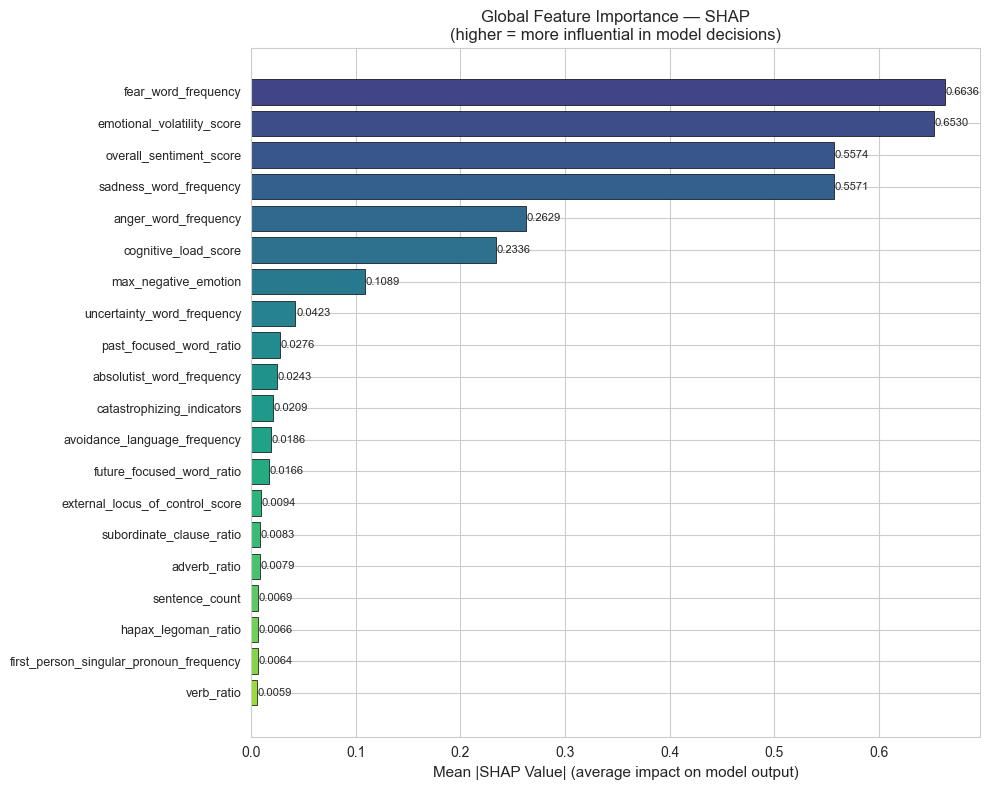

  Saved: text_ml_pipeline_output\LightGBM_06052026_180407\shap_global_importance.png

  Top 20 features by global SHAP importance:
    1. fear_word_frequency                      0.66360 |############################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################

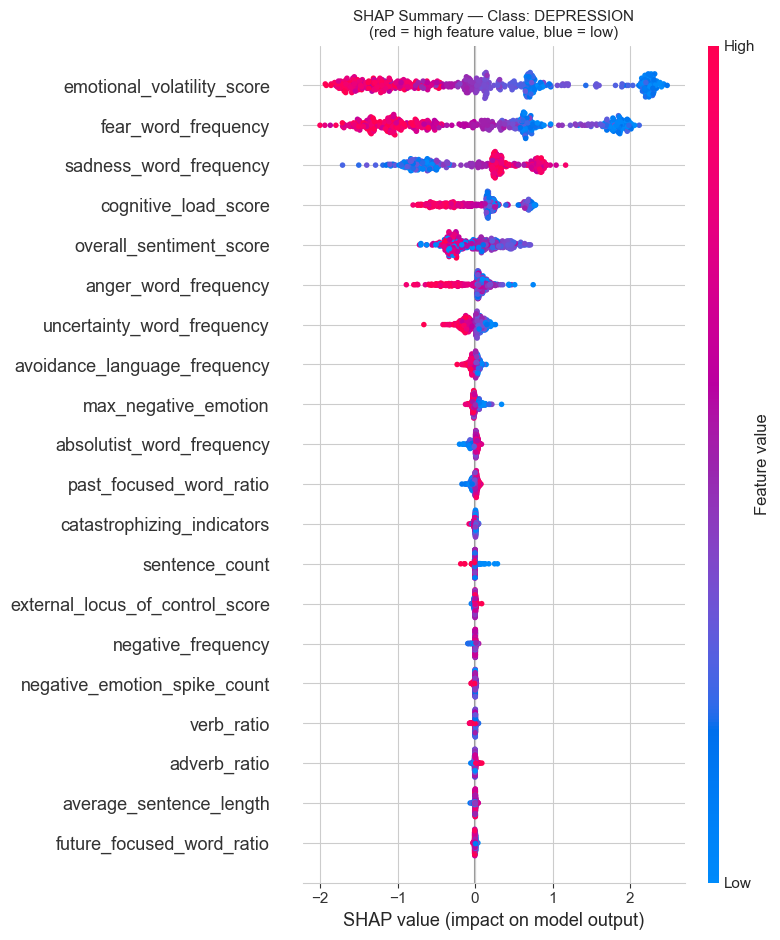

  Saved: text_ml_pipeline_output\LightGBM_06052026_180407\shap_summary_DEPRESSION.png

--- 19.3 Per-Class SHAP — Top 10 Features per Class ---


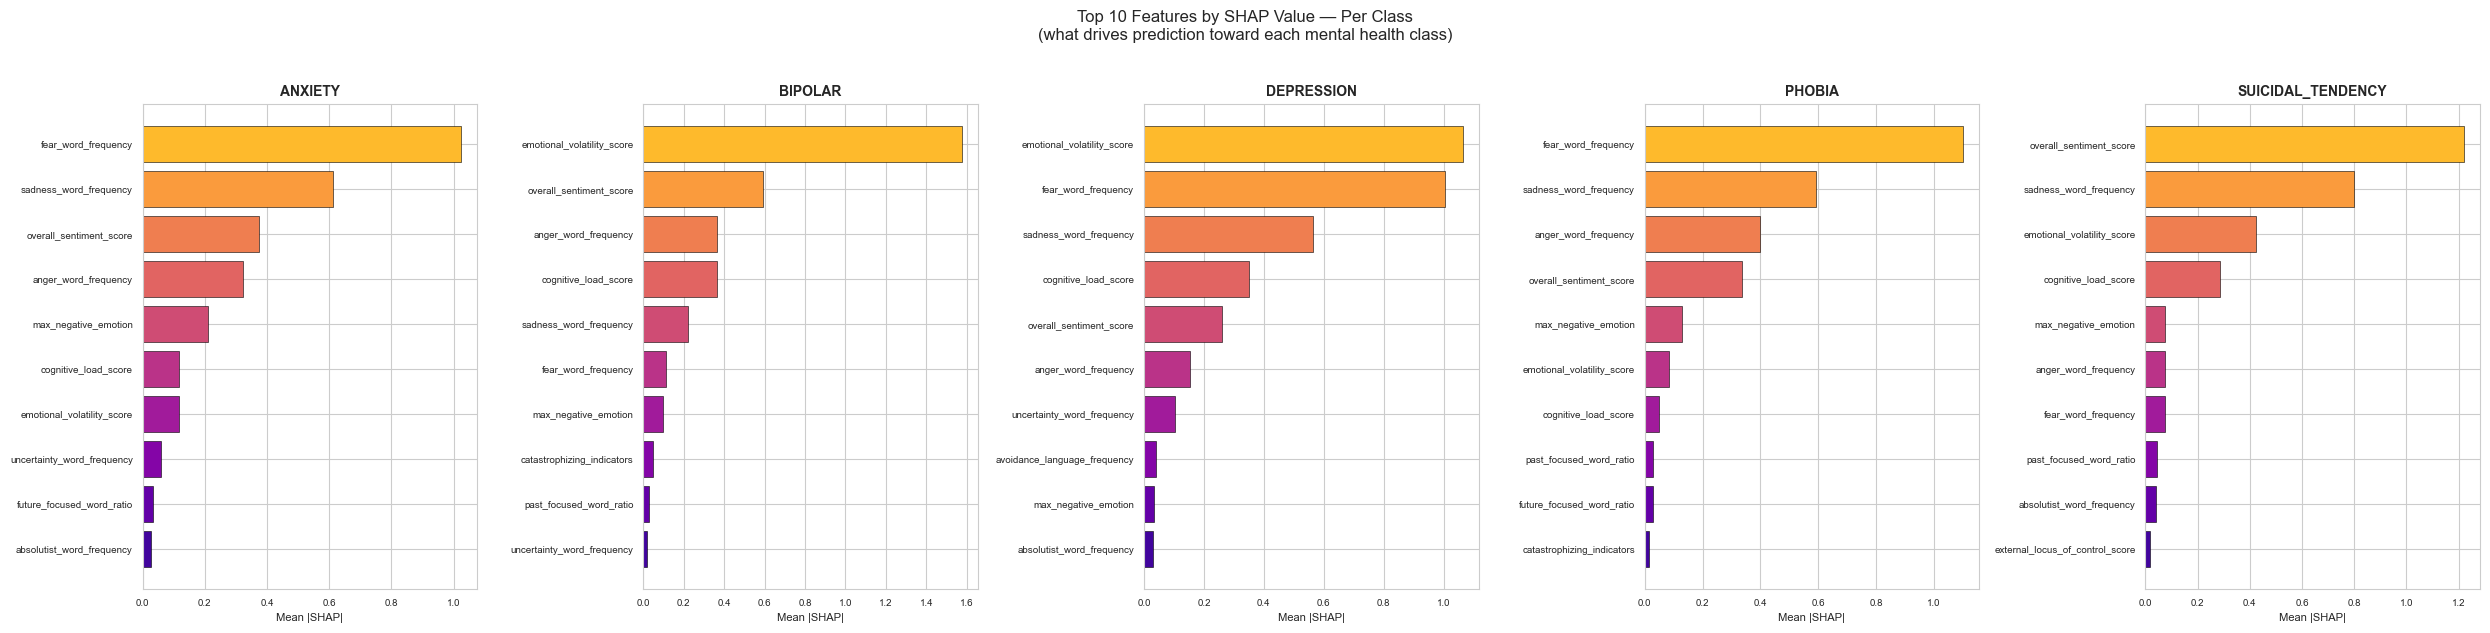

  Saved: text_ml_pipeline_output\LightGBM_06052026_180407\shap_per_class_top10.png

  ANXIETY:
    fear_word_frequency                      1.02453
    sadness_word_frequency                   0.61209
    overall_sentiment_score                  0.37542
    anger_word_frequency                     0.32371
    max_negative_emotion                     0.21160

  BIPOLAR:
    emotional_volatility_score               1.57661
    overall_sentiment_score                  0.59275
    anger_word_frequency                     0.36450
    cognitive_load_score                     0.36425
    sadness_word_frequency                   0.21913

  DEPRESSION:
    emotional_volatility_score               1.06352
    fear_word_frequency                      1.00587
    sadness_word_frequency                   0.56309
    cognitive_load_score                     0.35053
    overall_sentiment_score                  0.26022

  PHOBIA:
    fear_word_frequency                      1.10130
    sadness_word_fr

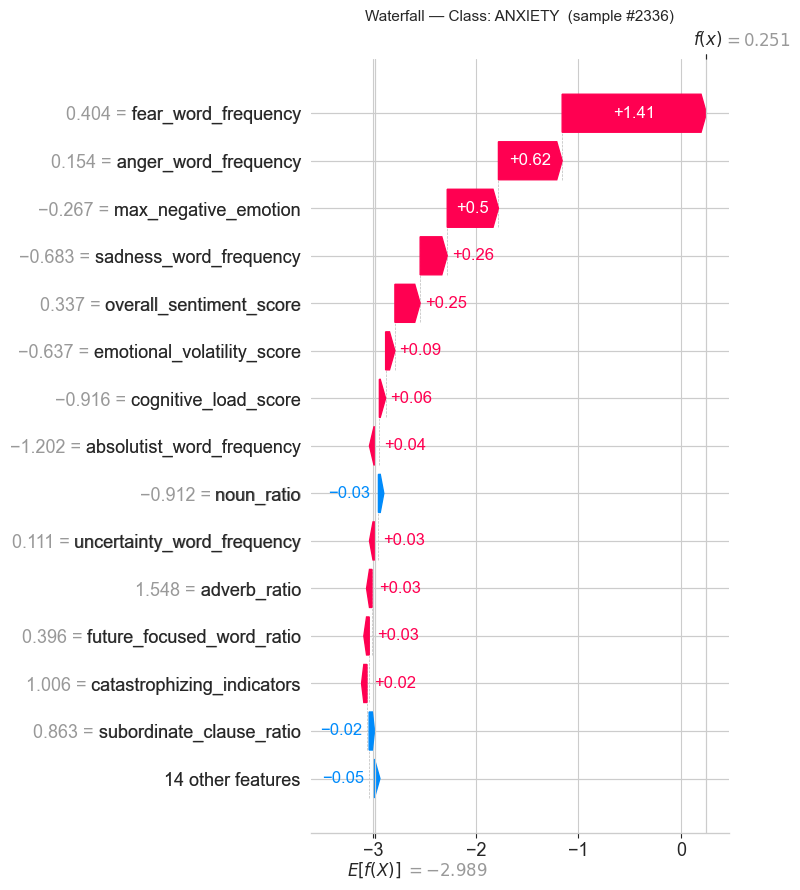

  ANXIETY: saved text_ml_pipeline_output\LightGBM_06052026_180407\shap_waterfall_ANXIETY.png


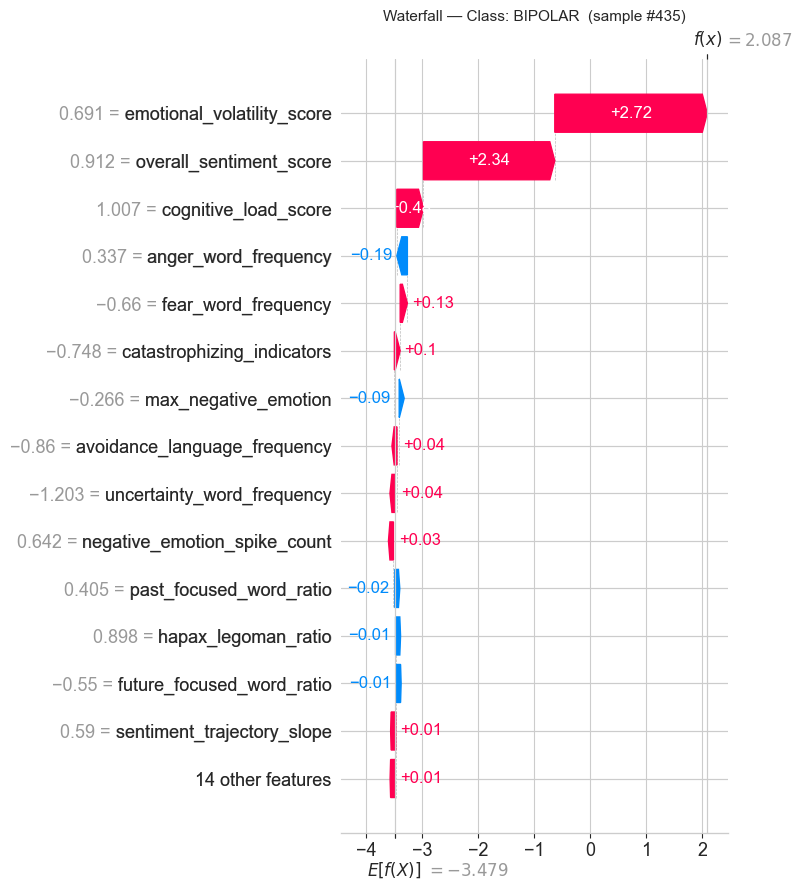

  BIPOLAR: saved text_ml_pipeline_output\LightGBM_06052026_180407\shap_waterfall_BIPOLAR.png


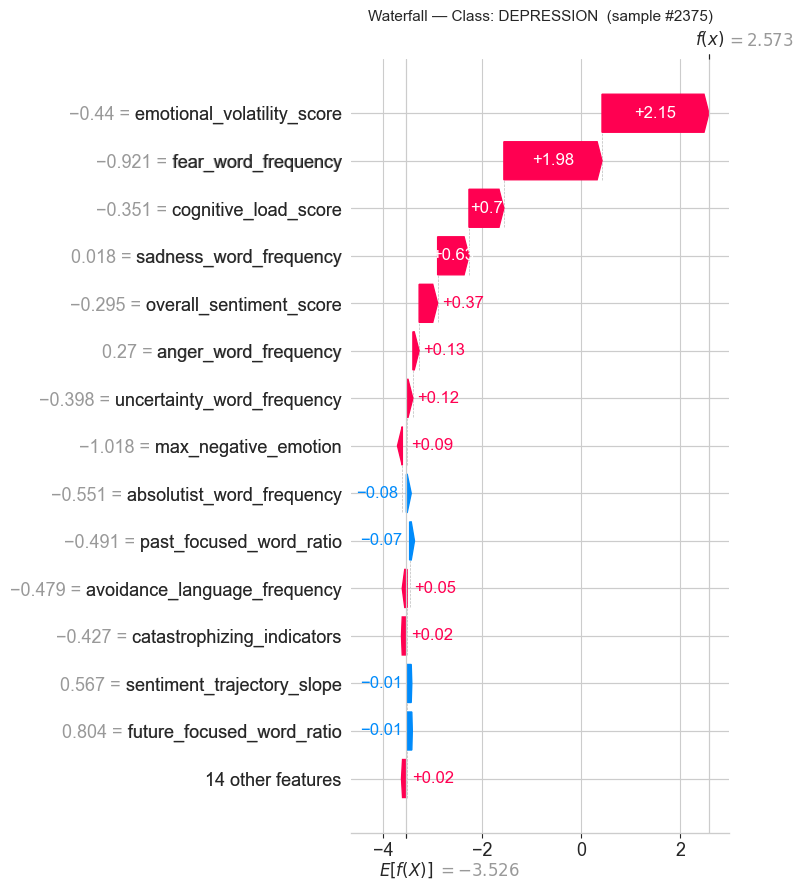

  DEPRESSION: saved text_ml_pipeline_output\LightGBM_06052026_180407\shap_waterfall_DEPRESSION.png


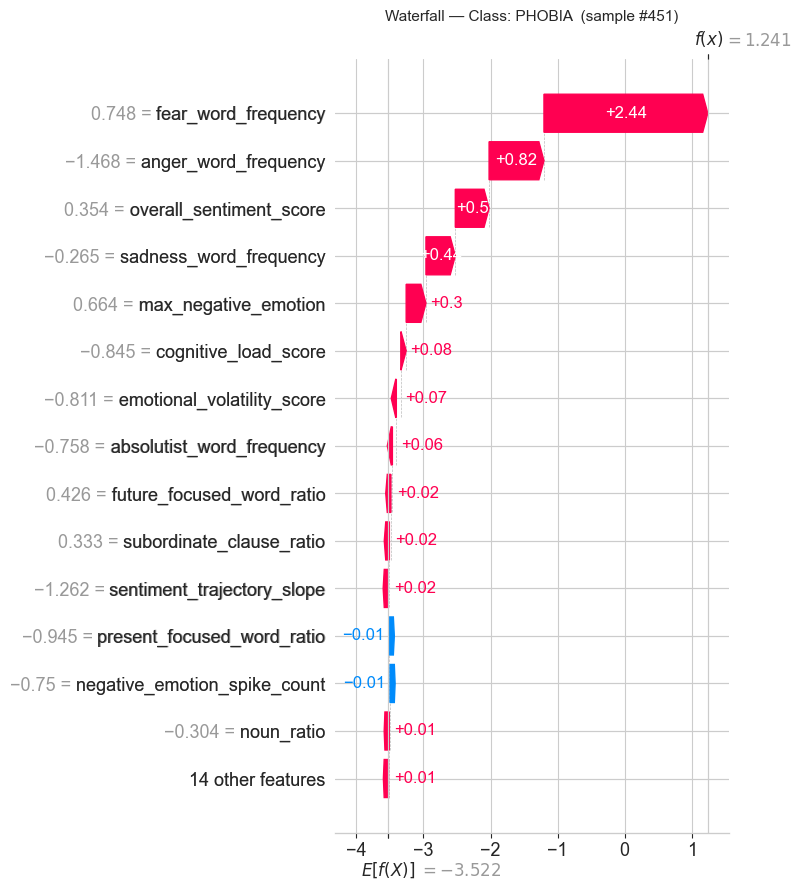

  PHOBIA: saved text_ml_pipeline_output\LightGBM_06052026_180407\shap_waterfall_PHOBIA.png


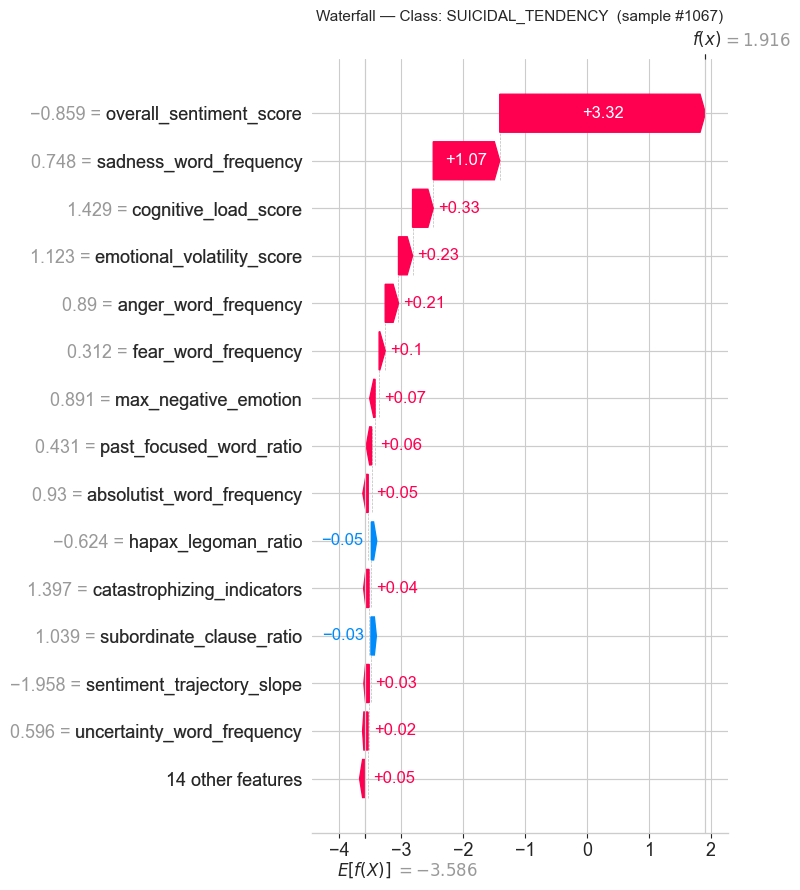

  SUICIDAL_TENDENCY: saved text_ml_pipeline_output\LightGBM_06052026_180407\shap_waterfall_SUICIDAL_TENDENCY.png

Step 19 complete.
All SHAP plots saved to: text_ml_pipeline_output\LightGBM_06052026_180407


In [22]:
print('=' * 70)
print('STEP 19: MODEL EXPLAINABILITY (SHAP)')
print('=' * 70)

try:
    import shap
    shap.initjs()
except ImportError:
    raise ImportError('SHAP not installed. Run: pip install shap')

# ─── Setup — use the best final model and scaled training/test data ───
model_for_shap = final_model
X_train_shap  = X_train_scaled
X_test_shap   = X_test_scaled
feat_names    = feature_names

print(f'\nModel type  : {type(model_for_shap).__name__}')
print(f'Features    : {len(feat_names)}')
print(f'Test samples: {X_test_shap.shape[0]}')
print(f'Classes     : {class_names}')

# ─── Choose explainer based on model type ────────────────────────────
tree_models = ('RandomForest', 'ExtraTrees', 'XGB', 'LGB', 'GradientBoosting',
               'HistGradient', 'DecisionTree')

if any(t.lower() in type(model_for_shap).__name__.lower() for t in tree_models):
    print('\n  Using TreeExplainer (fast, exact SHAP values for tree-based models)...')
    explainer = shap.TreeExplainer(model_for_shap)
    # Use a sample for speed if test set is large
    shap_sample_size = min(500, X_test_shap.shape[0])
    idx_shap = np.random.choice(X_test_shap.shape[0], shap_sample_size, replace=False)
    X_shap_sample = X_test_shap[idx_shap]
    shap_values = explainer.shap_values(X_shap_sample)
    explainer_type = 'TreeExplainer'
else:
    print('\n  Using KernelExplainer (model-agnostic — this may take a few minutes)...')
    background = shap.kmeans(X_train_shap, 50)
    explainer = shap.KernelExplainer(model_for_shap.predict_proba, background)
    shap_sample_size = min(100, X_test_shap.shape[0])
    idx_shap = np.random.choice(X_test_shap.shape[0], shap_sample_size, replace=False)
    X_shap_sample = X_test_shap[idx_shap]
    shap_values = explainer.shap_values(X_shap_sample)
    explainer_type = 'KernelExplainer'

print(f'  SHAP values computed for {shap_sample_size} test samples.')

# ─── Handle shap_values shape — can be list (multiclass) or 3D array ─
# Normalise to list of 2D arrays [n_samples, n_features] per class
if isinstance(shap_values, list):
    shap_list = shap_values          # already list of arrays per class
    # For global importance, take mean |SHAP| across all classes
    shap_abs_mean = np.mean([np.abs(sv) for sv in shap_list], axis=0)
elif shap_values.ndim == 3:
    shap_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
    shap_abs_mean = np.mean(np.abs(shap_values), axis=2)
else:
    shap_list = [shap_values]
    shap_abs_mean = np.abs(shap_values)

global_importance = shap_abs_mean.mean(axis=0)
feat_importance_df = pd.DataFrame({
    'feature': feat_names,
    'mean_abs_shap': global_importance
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

# ─── 19.1 Global Feature Importance Bar Chart ─────────────────────────
print('\n--- 19.1 Global Feature Importance (Mean |SHAP| — Top 20) ---')
top20 = feat_importance_df.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(top20)))
bars = ax.barh(top20['feature'][::-1], top20['mean_abs_shap'][::-1],
               color=colors[::-1], edgecolor='black', linewidth=0.5)
ax.set_xlabel('Mean |SHAP Value| (average impact on model output)', fontsize=11)
ax.set_title('Global Feature Importance — SHAP\n(higher = more influential in model decisions)', fontsize=12)
ax.tick_params(axis='y', labelsize=9)
for i, (bar, val) in enumerate(zip(bars, top20['mean_abs_shap'][::-1])):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
shap_bar_path = os.path.join(run_dir, 'shap_global_importance.png')
plt.savefig(shap_bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Saved: {shap_bar_path}')

print('\n  Top 20 features by global SHAP importance:')
for i, row in top20.iterrows():
    bar = '#' * int(row['mean_abs_shap'] * 3000)
    print(f'  {i+1:>3}. {row["feature"]:<40} {row["mean_abs_shap"]:.5f} |{bar}')

# ─── 19.2 SHAP Beeswarm Summary Plot ─────────────────────────────────
print('\n--- 19.2 SHAP Beeswarm Summary Plot ---')
if len(shap_list) > 1:
    # Multiclass: use the class with highest variation (most interesting)
    class_var = [np.abs(sv).mean() for sv in shap_list]
    best_class_idx = int(np.argmax(class_var))
    best_class_name = class_names[best_class_idx] if class_names else str(best_class_idx)
    print(f'  Showing beeswarm for class: {best_class_name} (highest mean |SHAP|)')
    sv_for_summary = shap_list[best_class_idx]
else:
    sv_for_summary = shap_list[0]
    best_class_name = class_names[0] if class_names else 'target'

plt.figure(figsize=(10, max(6, len(feat_names) * 0.25)))
shap.summary_plot(sv_for_summary, X_shap_sample,
                  feature_names=feat_names, show=False, max_display=20)
plt.title(f'SHAP Summary — Class: {best_class_name}\n(red = high feature value, blue = low)', fontsize=11)
plt.tight_layout()
shap_summary_path = os.path.join(run_dir, f'shap_summary_{best_class_name}.png')
plt.savefig(shap_summary_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Saved: {shap_summary_path}')

# ─── 19.3 Per-Class SHAP Top Features ────────────────────────────────
print('\n--- 19.3 Per-Class SHAP — Top 10 Features per Class ---')

if len(shap_list) > 1 and class_names:
    n_classes_shap = len(shap_list)
    fig, axes = plt.subplots(1, n_classes_shap,
                             figsize=(5 * n_classes_shap, max(6, len(feat_names) * 0.22)))

    for cls_idx, (sv, cls_name) in enumerate(zip(shap_list, class_names)):
        mean_abs = np.abs(sv).mean(axis=0)
        top_idx  = np.argsort(mean_abs)[::-1][:10]
        top_feats = [feat_names[i] for i in top_idx]
        top_vals  = mean_abs[top_idx]

        ax = axes[cls_idx] if n_classes_shap > 1 else axes
        colors_cls = plt.cm.plasma(np.linspace(0.1, 0.85, len(top_feats)))
        ax.barh(top_feats[::-1], top_vals[::-1], color=colors_cls, edgecolor='black', lw=0.4)
        ax.set_title(f'{cls_name}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Mean |SHAP|', fontsize=8)
        ax.tick_params(axis='y', labelsize=7)
        ax.tick_params(axis='x', labelsize=7)

    plt.suptitle('Top 10 Features by SHAP Value — Per Class\n(what drives prediction toward each mental health class)',
                 fontsize=12, y=1.02)
    plt.tight_layout()
    shap_perclass_path = os.path.join(run_dir, 'shap_per_class_top10.png')
    plt.savefig(shap_perclass_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {shap_perclass_path}')

    # Print table
    print()
    for cls_idx, (sv, cls_name) in enumerate(zip(shap_list, class_names)):
        mean_abs = np.abs(sv).mean(axis=0)
        top_idx  = np.argsort(mean_abs)[::-1][:5]
        top_feats = [(feat_names[i], mean_abs[i]) for i in top_idx]
        print(f'  {cls_name}:')
        for feat, val in top_feats:
            print(f'    {feat:<40} {val:.5f}')
        print()

# ─── 19.4 Waterfall Plot — One Sample per Class ───────────────────────
print('\n--- 19.4 Waterfall Plots — Single Prediction Explainer (One per Class) ---')
print('  Shows the exact feature contribution breakdown for one test sample per class.')

y_test_labels = le.inverse_transform(y_test) if le else y_test

if len(shap_list) > 1 and class_names:
    for cls_idx, cls_name in enumerate(class_names):
        # Find a test sample that belongs to this class AND is in our shap sample
        cls_test_indices = np.where(y_test_labels[idx_shap] == cls_name)[0]
        if len(cls_test_indices) == 0:
            print(f'  No {cls_name} sample found in SHAP sample — skipping.')
            continue

        sample_idx = cls_test_indices[0]   # first sample of this class in shap set
        sv_sample  = shap_list[cls_idx][sample_idx]

        # Build SHAP Explanation object for waterfall
        expected_val = explainer.expected_value
        if isinstance(expected_val, (list, np.ndarray)):
            expected_val = expected_val[cls_idx]

        explanation = shap.Explanation(
            values=sv_sample,
            base_values=float(expected_val),
            data=X_shap_sample[sample_idx],
            feature_names=feat_names
        )

        plt.figure(figsize=(10, 7))
        shap.plots.waterfall(explanation, max_display=15, show=False)
        plt.title(f'Waterfall — Class: {cls_name}  (sample #{idx_shap[sample_idx]})', fontsize=11)
        plt.tight_layout()
        waterfall_path = os.path.join(run_dir, f'shap_waterfall_{cls_name}.png')
        plt.savefig(waterfall_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'  {cls_name}: saved {waterfall_path}')

PIPELINE_STATE['shap'] = {
    'explainer_type': explainer_type,
    'samples_explained': int(shap_sample_size),
    'top_5_global_features': feat_importance_df.head(5)['feature'].tolist(),
    'artifacts_saved': True
}

print(f'\nStep 19 complete.')
print(f'All SHAP plots saved to: {run_dir}')